# NFL Factor Lab — Master Notebook

This is the single authoritative Kaggle-style research workbench for X-13. It is a sequential data-analysis notebook: every stage exposes a named DataFrame, its grain, shape, missingness, exclusions, and SHA-256 provenance when the publication provides one. It never downloads data, trains a model, or turns source-time association into a latency, causality, execution, or alpha claim. The historical holdout appears only after its immutable shortlist lock and locked runner have completed.

Two modes share the same cells. `single_game_audit` reads one verified game and may recompute bounded, pure presentation transformations in memory. `twenty_game_published` reads only verified compact publications and never scans the full association candidate universe on notebook open.

## 0. Claim boundary and parameters

**Claim boundary:** `PRELIMINARY_SOURCE_TIME_ONLY`. Historical source time supports ordering and interval association only. Receive time is unavailable historically. The shortlist is not frozen and the 81-game final holdout remains CLOSED; there is still no model training. The parameter cell below is the only supported control surface.

In [1]:
MODE = "single_game_audit"
GAME_ID = "2025_14_DAL_DET"
FACTOR_ID = "NFL.EVENT.EXPLOSIVE_PLAY"
MARKET_FAMILY = "moneyline"
VENUE = "all"
DELAY_S = 0
HORIZON_S = 10

In [2]:
import hashlib
import json
import os
from pathlib import Path

import pandas as pd
from html import escape
from IPython.display import HTML, SVG, display

from prediction_market.sports.nfl_factor_lab_artifacts import (
    verify_factor_discovery_bundle,
    verify_sports_feature_view,
)
from prediction_market.sports.nfl_factor_lab_run_index import (
    factor_lab_materializer_code_lock_sha256,
)
from prediction_market.workbench.factor_lab_master import (
    ArtifactRef,
    DEFAULT_RUN_INDEX,
    PREFERRED_RUN_INDEX,
    STAGE_MANIFEST_ENV,
    VALID_MODES,
    data_gap_frame,
    discover_batch_manifest,
    discover_v2_bundle_manifests,
    find_project_root,
    frame_audit,
    load_v2_batch_attrition_summary,
    load_game_projection,
    load_run_index,
    manifest_frame,
    projection_frame,
    read_bundle_stage,
    read_json_object,
    read_parquet_slice,
    read_v2_sports_source_slice,
    resolve_artifact_ref,
    verify_factor_lab_notebook_run,
)

ROOT = find_project_root()
OFFICIAL_COMPUTATION = "read_verified_publications_only"
if MODE not in VALID_MODES:
    raise ValueError(f"MODE must be one of {sorted(VALID_MODES)}")
if VENUE not in {"all", "kalshi", "polymarket"}:
    raise ValueError("VENUE must be all, kalshi, or polymarket")
if DELAY_S not in {0, 1, 2, 3, 5, 10}:
    raise ValueError("DELAY_S is outside the registered sensitivity grid")
if HORIZON_S not in {1, 2, 5, 10, 20, 30, 60}:
    raise ValueError("HORIZON_S is outside the registered horizon grid")
if MODE == "twenty_game_published":
    OPEN_POLICY = "compact verified cross-game publications only"
else:
    OPEN_POLICY = "one verified single-game bundle plus compact publications"

In [3]:
parameter_df = pd.DataFrame([{
    "MODE": MODE,
    "GAME_ID": GAME_ID,
    "FACTOR_ID": FACTOR_ID,
    "MARKET_FAMILY": MARKET_FAMILY,
    "VENUE": VENUE,
    "DELAY_S": DELAY_S,
    "HORIZON_S": HORIZON_S,
}])
claim_boundary_df = pd.DataFrame([{
    "experiment_id": "X-13",
    "claim_boundary": "PRELIMINARY_SOURCE_TIME_ONLY",
    "historical_clock_class": "HISTORICAL_SOURCE_ONLY",
    "receive_time_claim": "PROHIBITED",
    "causal_or_latency_claim": "PROHIBITED",
    "model_training": "PROHIBITED",
    "holdout_reaction_access": "SEALED_UNREAD",
}])
claim_boundary_audit_df = frame_audit(
    claim_boundary_df,
    name="claim_boundary_df",
    grain="one governed notebook run",
)
display(parameter_df, claim_boundary_df, claim_boundary_audit_df)

,MODE,GAME_ID,FACTOR_ID,MARKET_FAMILY,VENUE,DELAY_S,HORIZON_S
0,single_game_audit,2025_14_DAL_DET,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,all,0,10


,experiment_id,claim_boundary,historical_clock_class,receive_time_claim,causal_or_latency_claim,model_training,holdout_reaction_access
0,X-13,PRELIMINARY_SOURCE_TIME_ONLY,HISTORICAL_SOURCE_ONLY,PROHIBITED,PROHIBITED,PROHIBITED,COMPLETED_AFTER_SHORTLIST_LOCK


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,claim_boundary_df,one governed notebook run,1 x 7,1,7,0,0.0,0,AVAILABLE,None,None,None,None


## 1. Run, S3, and stage manifests

The canonical V2 run index is the only entry point. It is atomically published after all 20 single-game bundles and the cross-game bundle exist. This section rejects a stale run whose `code_lock_sha256` differs from the current formal pipeline. Default startup is `SHALLOW_COMMIT_VERIFIED`: it hashes the 21 small bundle manifests and reconciles path, byte-length, governance, exact 20-game coverage, and all 345 stage commitments without scanning the large association tables. Section 1 states `stage_content_verification=NOT_READ`; set `SAF_FACTOR_LAB_DEEP_VERIFY=1` only when a fresh full content/semantic verification is required. S3 bucket/prefix are configuration only (`CONFIGURED_NOT_REMOTE_VERIFIED`), never proof of a remote readback. No credential or network fallback exists. Grain: one descriptor per row.

In [4]:
run_index_path, run_index = load_run_index(ROOT)
if run_index_path != ROOT / PREFERRED_RUN_INDEX or run_index.get("schema") != "NFLFactorLabRunIndexV2":
    raise ValueError("Master Notebook requires the canonical NFLFactorLabRunIndexV2")
current_code_lock_sha256 = factor_lab_materializer_code_lock_sha256(ROOT)
if run_index.get("code_lock_sha256") != current_code_lock_sha256:
    raise ValueError("Canonical V2 run index is stale or incomplete for the current formal pipeline; wait for atomic seq20 publication")
notebook_run = verify_factor_lab_notebook_run(run_index_path, project_root=ROOT)
verified_v2_run_index = notebook_run.run_index
if notebook_run.latest_deep_batch_status not in {"NOT_RECORDED_IN_RUN_INDEX", "VERIFIED_CURRENT_KERNEL"}:
    raise ValueError("Unknown deep-verification status")
run_index_status = notebook_run.verification_mode
run_index_sha256 = verified_v2_run_index.run_index_sha256
verification_status_df = pd.DataFrame([{
    "verification_mode": notebook_run.verification_mode,
    "manifest_commit_verification": "PASS",
    "stage_content_verification": notebook_run.stage_content_verification,
    "latest_deep_batch_status": notebook_run.latest_deep_batch_status,
    "code_lock_sha256": current_code_lock_sha256,
    "code_lock_status": "MATCH_CURRENT_FORMAL_PIPELINE",
    "deep_verify_switch": "Set SAF_FACTOR_LAB_DEEP_VERIFY=1 for full stage SHA-256 and semantic verification",
    "game_count": len(verified_v2_run_index.game_ids),
    "stage_count": len(verified_v2_run_index.stage_manifest),
    "verification_elapsed_seconds": notebook_run.verification_elapsed_seconds,
}])
verification_status_df.attrs.update({"status": notebook_run.verification_mode, "source_path": str(run_index_path), "source_sha256": run_index_sha256, "source_row_count": 1})
run_manifest_df = manifest_frame(
    run_index,
    manifest_path=run_index_path,
    source_sha256=run_index_sha256,
)
run_manifest_df.attrs["status"] = run_index_status
prior_run_index_path = ROOT / DEFAULT_RUN_INDEX
prior_run_index = read_json_object(prior_run_index_path, expected_schema="NFLFactorLabRunIndexV1")
prior_run_index_sha256 = "sha256:" + hashlib.sha256(prior_run_index_path.read_bytes()).hexdigest()
prior_run_manifest_df = manifest_frame(prior_run_index, manifest_path=prior_run_index_path, source_sha256=prior_run_index_sha256)
prior_run_manifest_df.attrs.update({"status": "PRIOR_EVIDENCE_V1", "reason": "immutable prior evidence; not equivalent to official V2 input"})
if verified_v2_run_index is not None:
    required_v2_source_keys = {
        "factor_registry_v1", "method_catalog_v1", "x13_signal_manifest_v1",
        "x13_correlation_cache_manifest_v1", "x13_reaction_paths_v1",
        "x13_prior_sports_feature_view_manifest_v1", "x13_prior_discovery_manifest_v1",
        "x13_batch_manifest_v1", "nflverse_2022_manifest", "nflverse_2023_manifest",
        "nflverse_2024_manifest", "nflverse_2025_manifest",
    }
    observed_v2_source_keys = {name for name, *_ in verified_v2_run_index.source_artifacts}
    if not required_v2_source_keys <= observed_v2_source_keys:
        raise ValueError(f"official V2 source_artifacts omit required keys: {sorted(required_v2_source_keys - observed_v2_source_keys)}")
    v2_source_refs = {
        name: ArtifactRef(name=name, path=path, sha256=digest, byte_length=byte_length)
        for name, path, digest, byte_length in verified_v2_run_index.source_artifacts
    }
    source_artifact_manifest_df = pd.DataFrame([
        {"source_key": name, "path": str(ref.path), "sha256": ref.sha256, "byte_length": ref.byte_length, "status": "DESCRIPTOR_COMMITTED_NOT_REHASHED" if notebook_run.verification_mode == "SHALLOW_COMMIT_VERIFIED" else "DEEP_CONTENT_VERIFIED"}
        for name, ref in sorted(v2_source_refs.items())
    ])
    source_artifact_manifest_df.attrs.update({"status": notebook_run.verification_mode, "source_path": str(run_index_path), "source_sha256": run_index_sha256, "source_row_count": len(source_artifact_manifest_df)})
else:
    v2_source_refs = {}
    source_artifact_manifest_df = data_gap_frame(stage="v2_source_artifacts", grain="one V2 source_artifact descriptor", reason="official V2 run index is unavailable", expected_columns=("source_key", "path", "sha256", "byte_length", "status"))

s3_descriptor = run_index.get("s3")
if verified_v2_run_index is not None and isinstance(s3_descriptor, dict):
    if notebook_run.s3_status != "CONFIGURED_NOT_REMOTE_VERIFIED":
        raise ValueError("Notebook must not claim remote S3 verification")
    s3_manifest_df = pd.DataFrame([{"bucket": verified_v2_run_index.s3_bucket, "prefix": verified_v2_run_index.s3_prefix, "credentials_in_notebook": False, "network_access": "forbidden", "remote_verification": "NOT_PERFORMED_BY_NOTEBOOK", "status": notebook_run.s3_status}])
    s3_manifest_df.attrs.update({"status": notebook_run.s3_status, "source_path": str(run_index_path), "source_sha256": run_index_sha256, "source_row_count": 1})
elif isinstance(run_index.get("s3_manifest"), dict):
    s3_manifest_ref = resolve_artifact_ref(run_index, "s3_manifest", project_root=ROOT)
    s3_manifest = read_json_object(s3_manifest_ref.path)
    s3_manifest_df = manifest_frame(
        s3_manifest,
        manifest_path=s3_manifest_ref.path,
        source_sha256=s3_manifest_ref.sha256,
    )
else:
    s3_manifest_df = data_gap_frame(
        stage="s3_manifest",
        grain="one hydrated S3 object descriptor",
        reason="run index contains no hydrated S3 manifest; network access is forbidden",
        expected_columns=("artifact", "path", "sha256", "byte_length"),
    )

stage_manifest_path = os.environ.get(STAGE_MANIFEST_ENV)
if verified_v2_run_index is not None:
    stage_manifest = [entry.to_dict() for entry in verified_v2_run_index.stage_manifest]
    stage_manifest_df = pd.DataFrame(stage_manifest)
    stage_manifest_df.attrs.update({"status": notebook_run.verification_mode, "source_path": str(run_index_path), "source_sha256": run_index_sha256, "source_row_count": len(stage_manifest_df)})
elif stage_manifest_path:
    stage_manifest_path = str((ROOT / stage_manifest_path).resolve()) if not Path(stage_manifest_path).is_absolute() else stage_manifest_path
    stage_manifest = read_json_object(stage_manifest_path)
    stage_manifest_sha256 = "sha256:" + hashlib.sha256(Path(stage_manifest_path).read_bytes()).hexdigest()
    stage_manifest_df = manifest_frame(
        stage_manifest,
        manifest_path=stage_manifest_path,
        source_sha256=stage_manifest_sha256,
    )
else:
    stage_manifest = None
    stage_manifest_df = data_gap_frame(
        stage="stage_manifest",
        grain="one planned v2 stage artifact descriptor",
        reason=f"{STAGE_MANIFEST_ENV} is unset; planned v2 tables stay unavailable",
        expected_columns=("artifact", "path", "schema", "row_count", "sha256"),
    )

batch_manifest_path = v2_source_refs["x13_batch_manifest_v1"].path if "x13_batch_manifest_v1" in v2_source_refs else discover_batch_manifest(ROOT, prior_run_index)
if batch_manifest_path is not None:
    batch_manifest = read_json_object(batch_manifest_path, expected_schema="nfl_x13_batch_manifest_v1")
    batch_manifest_sha256 = "sha256:" + hashlib.sha256(batch_manifest_path.read_bytes()).hexdigest()
    batch_manifest_df = manifest_frame(
        batch_manifest,
        manifest_path=batch_manifest_path,
        source_sha256=batch_manifest_sha256,
    )
else:
    batch_manifest = None
    batch_manifest_df = data_gap_frame(
        stage="batch_manifest",
        grain="one published batch descriptor",
        reason="published batch manifest cannot be resolved from the run index",
        expected_columns=("artifact", "path", "schema", "row_count", "sha256"),
    )

single_v2_bundle = notebook_run.single_game_bundle(GAME_ID)
single_v2_manifest_path = single_v2_bundle.manifest_path
single_v2_manifest = read_json_object(single_v2_manifest_path, expected_schema="SingleGameAnalysisBundleV2")
single_v2_manifest_df = manifest_frame(single_v2_manifest, manifest_path=single_v2_manifest_path, source_sha256=single_v2_bundle.manifest_sha256)
single_v2_manifest_df.attrs["status"] = notebook_run.verification_mode
cross_v2_bundle = notebook_run.cross_game_bundle
cross_v2_manifest_path = cross_v2_bundle.manifest_path
cross_v2_manifest = read_json_object(cross_v2_manifest_path, expected_schema="CrossGameAnalysisBundleV2")
cross_v2_manifest_df = manifest_frame(cross_v2_manifest, manifest_path=cross_v2_manifest_path, source_sha256=cross_v2_bundle.manifest_sha256)
cross_v2_manifest_df.attrs["status"] = notebook_run.verification_mode

display(
    frame_audit(verification_status_df, name="verification_status_df", grain="one notebook verification mode"),
    verification_status_df,
    frame_audit(run_manifest_df, name="run_manifest_df", grain="one run artifact descriptor"),
    run_manifest_df,
    frame_audit(prior_run_manifest_df, name="prior_run_manifest_df", grain="one immutable V1 artifact descriptor"),
    prior_run_manifest_df,
    frame_audit(source_artifact_manifest_df, name="source_artifact_manifest_df", grain="one V2 source artifact descriptor"),
    source_artifact_manifest_df,
    frame_audit(s3_manifest_df, name="s3_manifest_df", grain="one hydrated S3 descriptor"),
    s3_manifest_df,
    frame_audit(stage_manifest_df, name="stage_manifest_df", grain="one stage descriptor"),
    stage_manifest_df,
    frame_audit(batch_manifest_df, name="batch_manifest_df", grain="one batch descriptor"),
    batch_manifest_df.head(20),
    frame_audit(single_v2_manifest_df, name="single_v2_manifest_df", grain="one V2 single-game stage descriptor"),
    single_v2_manifest_df,
    frame_audit(cross_v2_manifest_df, name="cross_v2_manifest_df", grain="one V2 cross-game stage descriptor"),
    cross_v2_manifest_df,
)

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,verification_status_df,one notebook verification mode,1 x 10,1,10,0,0.0,0,SHALLOW_COMMIT_VERIFIED,None,1,sha256:d8ffb0fe71c0f6bd565a4519939a1cc792d7176...,/Users/wekruitclaw1/Desktop/prediction-market/...


,verification_mode,manifest_commit_verification,stage_content_verification,latest_deep_batch_status,code_lock_sha256,code_lock_status,deep_verify_switch,game_count,stage_count,verification_elapsed_seconds
0,SHALLOW_COMMIT_VERIFIED,PASS,NOT_READ,NOT_RECORDED_IN_RUN_INDEX,sha256:755838977a9e31d1d70efbd160c4e7964eb4689...,MATCH_CURRENT_FORMAL_PIPELINE,Set SAF_FACTOR_LAB_DEEP_VERIFY=1 for full stag...,20,345,0.034807


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,run_manifest_df,one run artifact descriptor,41 x 6,41,6,82,33.333333,0,SHALLOW_COMMIT_VERIFIED,None,41,sha256:d8ffb0fe71c0f6bd565a4519939a1cc792d7176...,/Users/wekruitclaw1/Desktop/prediction-market/...


,artifact,path,schema,row_count,byte_length,sha256
0,cross_game_bundle.manifest,artifacts/market-observation/nfl/x13/factor-la...,None,None,10243,sha256:084fcbc33007de47808410aebbb3c5b4590690f...
1,single_game_bundles[0].manifest,artifacts/market-observation/nfl/x13/factor-la...,None,None,13436,sha256:383de1dac6f964645988698b62b6bf5e947fdc3...
2,single_game_bundles[1].manifest,artifacts/market-observation/nfl/x13/factor-la...,None,None,13431,sha256:c66cbe2565c213d17be19ee75fcd758e4b362f5...
3,single_game_bundles[2].manifest,artifacts/market-observation/nfl/x13/factor-la...,None,None,13426,sha256:1752379cb940c5a9d958ee7f2c14ac913fca5da...
4,single_game_bundles[3].manifest,artifacts/market-observation/nfl/x13/factor-la...,None,None,13431,sha256:3c571900f2f4860c8b7f88e297ce8403ee7ce5c...
5,single_game_bundles[4].manifest,artifacts/market-observation/nfl/x13/factor-la...,None,None,13431,sha256:28d0695be103911c603a52eae502020f0430d4b...
6,single_game_bundles[5].manifest,artifacts/market-observation/nfl/x13/factor-la...,None,None,13440,sha256:f5a50336c84f99bec99191dbd630afb5a75b339...
7,single_game_bundles[6].manifest,artifacts/market-observation/nfl/x13/factor-la...,None,None,13432,sha256:e2e469939351bb93aeb373f3bcbd05bc472d3ea...
8,single_game_bundles[7].manifest,artifacts/market-observation/nfl/x13/factor-la...,None,None,13432,sha256:bdb8507848900817920069f77ba61ae472be639...
9,single_game_bundles[8].manifest,artifacts/market-observation/nfl/x13/factor-la...,None,None,13434,sha256:e6c69ef6634d0435f90cd640a8867b17bbadd9f...


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,prior_run_manifest_df,one immutable V1 artifact descriptor,7 x 6,7,6,14,33.333333,0,PRIOR_EVIDENCE_V1,immutable prior evidence; not equivalent to of...,7,sha256:0007dcbecaf5364d50fc667885d244e6722a178...,/Users/wekruitclaw1/Desktop/prediction-market/...


...

,artifact,path,schema,row_count,byte_length,sha256
0,auxiliary_artifacts[0],data/associations/game_id=2025_01_BAL_BUF/venu...,nfl_x13_auxiliary_artifact_v1,277200,190406,sha256:c9395aa4a162b95a7972a5978a60037e5b76217...
1,auxiliary_artifacts[1],data/associations/game_id=2025_01_BAL_BUF/venu...,nfl_x13_auxiliary_artifact_v1,277200,86940,sha256:451c21ab8dbfce1fe4a7892cce74d3cca104f8f...
2,auxiliary_artifacts[2],data/associations/game_id=2025_01_BAL_BUF/venu...,nfl_x13_auxiliary_artifact_v1,11088,215213,sha256:1bb491987d44d8e3cb09bde321275c4bc620189...
3,auxiliary_artifacts[3],data/associations/game_id=2025_01_BAL_BUF/venu...,nfl_x13_auxiliary_artifact_v1,166320,92717,sha256:e03c79d248375f62af1254a21c1d31b161676c0...
4,auxiliary_artifacts[4],data/associations/game_id=2025_01_BAL_BUF/venu...,nfl_x13_auxiliary_artifact_v1,1086624,324112,sha256:1c1d6791c1870348593ecf41d8ba2310b2da2c5...
5,auxiliary_artifacts[5],data/associations/game_id=2025_01_BAL_BUF/venu...,nfl_x13_auxiliary_artifact_v1,898128,326185,sha256:0cfba8fd6b590f7dd7003b9abfeecfe45074c65...
6,auxiliary_artifacts[6],data/associations/game_id=2025_01_BAL_BUF/venu...,nfl_x13_auxiliary_artifact_v1,11088,95284,sha256:452570849eb8d26a89d82c38270c683f16db8c0...
7,auxiliary_artifacts[7],data/associations/game_id=2025_01_BAL_BUF/venu...,nfl_x13_auxiliary_artifact_v1,11088,22066,sha256:b74f7f00ec841819ef70c744ba48ae2cc9ebe8e...
8,auxiliary_artifacts[8],data/associations/game_id=2025_01_BAL_BUF/venu...,nfl_x13_auxiliary_artifact_v1,11088,23542,sha256:2ad21fe3890f7d55f107913a41916eb30f86a98...
9,auxiliary_artifacts[9],data/associations/game_id=2025_03_ARI_SF/venue...,nfl_x13_auxiliary_artifact_v1,203832,116642,sha256:3b0474029310fb3b6c3a6a9c3d1f78ee85926c7...


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,single_v2_manifest_df,one V2 single-game stage descriptor,17 x 6,17,6,17,16.666667,0,SHALLOW_COMMIT_VERIFIED,None,17,sha256:515bc057cf10e3364a2a4aa16ac151a8d356422...,/Users/wekruitclaw1/Desktop/prediction-market/...


,artifact,path,schema,row_count,byte_length,sha256
0,stages.association_attrition,association_attrition_v2.parquet,None,770832,3931051,sha256:c2ad29da7994ab449ccd82a4c39be81661fa458...
1,stages.canonical_events,canonical_events_v2.parquet,None,192,75896,sha256:f2ceb2665c30b276645bad8bf8f6a84703d8bb6...
2,stages.contract_inventory,contract_inventory_v2.parquet,None,808,73946,sha256:cd339b0b51ce890cb6e5f28f34f7c30f44dee70...
3,stages.factor_exclusion_audit,factor_exclusion_audit_v2.parquet,None,27782,1314347,sha256:e259faf6205dd677458d8e521f03a9c36a710b6...
4,stages.factor_observations,factor_observations_v2.parquet,None,853,296182,sha256:7f24f2fd59707509f001aec3238611a143cbaca...
5,stages.finalized_episodes,finalized_episodes_v2.parquet,None,185,23760,sha256:e85ef26aa5bb37cd504b4df2b9b6398cadd5634...
6,stages.game_time_intervals,game_time_intervals_v2.parquet,None,954,52771,sha256:416d25269bc3c09eb0e46e88e9eeabb08b628b7...
7,stages.market_cleaning_audit,market_cleaning_audit_v2.parquet,None,170671,23520390,sha256:5e6859ee4104be47920abd29bd1aa686b64cb8a...
8,stages.market_observations,market_observations_v2.parquet,None,170671,13929482,sha256:307ee742fe5556742b49e63b640c77c125807d2...
9,stages.market_time_intervals,market_time_intervals_v2.parquet,None,170671,12326525,sha256:7e86eb27c51ed59efa8f0e012904ad84cabb610...


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,cross_v2_manifest_df,one V2 cross-game stage descriptor,5 x 6,5,6,5,16.666667,0,SHALLOW_COMMIT_VERIFIED,None,5,sha256:084fcbc33007de47808410aebbb3c5b4590690f...,/Users/wekruitclaw1/Desktop/prediction-market/...


,artifact,path,schema,row_count,byte_length,sha256
0,stages.cross_game_factor_results,cross_game_factor_results_v2.parquet,None,379,61460,sha256:cde484e77da7259633e22ca40fb046ed4a27eeb...
1,stages.expert_review_queue,expert_review_queue_v2.parquet,None,379,21934,sha256:e63431a53f9a2fc84167675e68feebdc8ed0104...
2,stages.game_contribution,game_contribution_v2.parquet,None,1790,53017,sha256:fd08066e9e1261b4231b9775401801c20527ba2...
3,stages.leave_one_game_out,leave_one_game_out_v2.parquet,None,7580,24502,sha256:3ed3e68beaf2cc44b4d8c072a1bfee07595f816...
4,stages.venue_consistency,venue_consistency_v2.parquet,None,295,5416,sha256:f90f20d1f47f7c682ab318503b5a1f1d0b83985...


## 2. Raw sports DataFrames

Single-game mode projects only the selected game's frozen nflverse rows and registered columns. Twenty-game mode intentionally does not materialize raw seasonal play-by-play on open; the verified compact feature publication is used in Section 4. Grain: one source play row. Missing source timestamps remain missing rather than being repaired.

In [5]:
if MODE == "single_game_audit" and single_v2_bundle is not None:
    raw_sports_df = read_v2_sports_source_slice(single_v2_bundle, limit=10_000)
else:
    raw_sports_df = data_gap_frame(
        stage="raw_sports",
        grain="one V2 raw-row disposition joined to canonical source lineage",
        reason="V2 single-game bundle is unavailable; prior V1 evidence is not recomputed as raw sports",
        expected_columns=("game_id", "raw_play_id", "canonical_play_id", "description", "disposition", "source_hash"),
    )

raw_sports_audit_df = frame_audit(
    raw_sports_df,
    name="raw_sports_df",
    grain="one V2 raw-row disposition joined to canonical source lineage",
)
display(raw_sports_audit_df, raw_sports_df.head(12))

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,raw_sports_df,one V2 raw-row disposition joined to canonical...,192 x 85,192,85,1614,9.889706,0,OFFICIAL_V2_VERIFIED,None,192,sha256:cfe3c30bcc9710be9c9a95c995b7b6402e2f3dd...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,raw_play_id,administrative_event_eligible,canonical_play_id,disposition,episode_id,exclusion_reasons,factor_eligible,live_play_outcome_eligible,row_type,...,safety,score_margin,source_time_end_utc,source_time_start_utc,source_time_status,timeout,timeout_team,touchdown,turnover,yardline_100
0,2025_14_DAL_DET,1,True,1,administrative_only,episode_97b7c5ce4d50b29a16294b583a6f8d2518477e...,"[""administrative"",""source_time_missing""]",False,False,administrative,...,False,NaN,NaN,NaN,missing,False,NaN,False,False,NaN
1,2025_14_DAL_DET,1010,False,1010,factor_eligible,episode_1b3704fb1961be924fc73f2cd8bde8398a7684...,[],True,True,live_play,...,False,-7.0,2025-12-05T01:55:46.400Z,2025-12-05T01:55:46.400Z,point,False,NaN,False,False,61.0
2,2025_14_DAL_DET,1035,False,1035,factor_eligible,episode_e551d04b7c00a2f6d99c8c51e9ff62ed73e884...,[],True,True,live_play,...,False,-7.0,2025-12-05T01:56:17.553Z,2025-12-05T01:56:17.553Z,point,False,NaN,False,False,57.0
3,2025_14_DAL_DET,1057,True,1057,administrative_only,episode_3dc3937b4fd2d80c07fc281c298385f970b39b...,"[""administrative"",""source_time_missing""]",False,False,administrative,...,False,-7.0,NaN,NaN,missing,False,NaN,False,False,NaN
4,2025_14_DAL_DET,1077,False,1077,factor_eligible,episode_35428e9aa44fb5b02ea07be5ade46198c2ba4f...,[],True,True,live_play,...,False,-7.0,2025-12-05T01:59:54.940Z,2025-12-05T01:59:54.940Z,point,False,NaN,False,False,54.0
5,2025_14_DAL_DET,1107,False,1107,factor_eligible,episode_09273494b5c5d7fb5bb97b3f7357304025b31b...,[],True,True,live_play,...,False,-7.0,2025-12-05T02:00:33.617Z,2025-12-05T02:00:33.617Z,point,False,NaN,False,False,53.0
6,2025_14_DAL_DET,111,False,111,factor_eligible,episode_91bc497d590bf389ae5356a872accd290d681d...,[],True,True,live_play,...,False,0.0,2025-12-05T01:17:41.210Z,2025-12-05T01:17:41.210Z,point,False,NaN,False,False,57.0
7,2025_14_DAL_DET,1137,False,1137,factor_eligible,episode_34c7d3b56bef0c8bae68c7c4ecc4162006d988...,[],True,True,live_play,...,False,-7.0,2025-12-05T02:01:08.537Z,2025-12-05T02:01:08.537Z,point,False,NaN,False,False,37.0
8,2025_14_DAL_DET,1169,False,1169,factor_eligible,episode_bed8f7ea6b1709e6fed061f8a822674f716bdb...,[],True,True,live_play,...,False,-7.0,2025-12-05T02:01:50.600Z,2025-12-05T02:01:50.600Z,point,False,NaN,False,False,33.0
9,2025_14_DAL_DET,1191,False,1191,factor_eligible,episode_d9df9815b4e0fb0aa6424fa48baa9db4d9ac28...,[],True,True,live_play,...,False,-7.0,2025-12-05T02:02:28.817Z,2025-12-05T02:02:28.817Z,point,False,NaN,False,False,30.0


## 3. Sports cleaning reconciliation

The published game projection exposes canonical events and finalized episodes separately. Reconciliation makes raw count, canonical count, episode count, no-play/nullified exclusions, and missing source times visible. Grain is one canonical play for `sports_clean_df` and one stage-count assertion for `sports_reconciliation_df`; this is a transparent audit, not a second hidden cleaner.

In [6]:
game_payload = None
game_projection_path = None
game_projection_sha256 = None
if MODE == "single_game_audit" and single_v2_bundle is not None:
    sports_row_disposition_df = read_bundle_stage(single_v2_bundle, "sports_row_disposition", limit=10_000)
    sports_clean_df = read_bundle_stage(single_v2_bundle, "canonical_events", limit=10_000)
    finalized_episodes_df = read_bundle_stage(single_v2_bundle, "finalized_episodes", limit=10_000)
    stat_ledger_df = read_bundle_stage(single_v2_bundle, "stat_ledger", limit=10_000)
    game_projection_path = single_v2_manifest_path
    game_projection_sha256 = single_v2_bundle.bundle_sha256
    disposition_column = next((name for name in ("disposition", "factor_eligible") if name in sports_row_disposition_df), None)
    if disposition_column is None:
        sports_reconciliation_df = data_gap_frame(stage="sports_reconciliation", grain="one reconciliation assertion", reason="verified sports disposition stage lacks disposition/factor_eligible semantics", expected_columns=("check", "count", "excluded"))
    else:
        sports_reconciliation_df = sports_row_disposition_df.groupby(disposition_column, dropna=False).size().rename("count").reset_index().rename(columns={disposition_column: "check"})
        sports_reconciliation_df["excluded"] = 0
        sports_reconciliation_df.attrs.update(sports_row_disposition_df.attrs)
elif MODE == "single_game_audit" and batch_manifest_path is not None:
    game_payload, game_projection_path, game_projection_sha256 = load_game_projection(batch_manifest_path, GAME_ID)
    sports_row_disposition_df = data_gap_frame(
        stage="sports_row_disposition",
        grain="one raw play disposition",
        reason="V2 bundle unavailable; V1 publication fallback",
        expected_columns=("game_id", "raw_play_id", "disposition"),
    )
    sports_clean_df = projection_frame(
        game_payload,
        "events",
        source_path=game_projection_path,
        source_sha256=game_projection_sha256,
    )
    finalized_episodes_df = projection_frame(
        game_payload,
        "episodes",
        source_path=game_projection_path,
        source_sha256=game_projection_sha256,
    )
    stat_ledger_df = projection_frame(
        game_payload,
        "stat_ledger",
        source_path=game_projection_path,
        source_sha256=game_projection_sha256,
    )
    raw_ids = set(raw_sports_df.get("play_id", pd.Series(dtype=object)).astype(str))
    clean_ids = set(sports_clean_df.get("play_id", pd.Series(dtype=object)).astype(str))
    sports_reconciliation_df = pd.DataFrame([
        {"check": "raw_source_rows", "count": len(raw_sports_df), "excluded": 0},
        {"check": "canonical_event_rows", "count": len(sports_clean_df), "excluded": max(0, len(raw_ids - clean_ids))},
        {"check": "finalized_episode_rows", "count": len(finalized_episodes_df), "excluded": int(finalized_episodes_df.get("nullified", pd.Series(dtype=bool)).fillna(False).sum())},
        {"check": "canonical_missing_source_time", "count": int(sports_clean_df.get("source_time_start_utc", pd.Series(dtype=object)).isna().sum()), "excluded": 0},
        {"check": "canonical_no_play", "count": int(sports_clean_df.get("no_play", pd.Series(dtype=bool)).fillna(False).sum()), "excluded": 0},
    ])
    sports_reconciliation_df.attrs.update({
        "status": "AVAILABLE",
        "source_path": str(game_projection_path),
        "source_sha256": game_projection_sha256,
        "source_row_count": len(sports_reconciliation_df),
    })
else:
    sports_row_disposition_df = data_gap_frame(
        stage="sports_row_disposition",
        grain="one raw play disposition",
        reason="single-game V2 bundle is not loaded in this mode",
        expected_columns=("game_id", "raw_play_id", "disposition"),
    )
    sports_clean_df = data_gap_frame(
        stage="sports_clean",
        grain="one canonical sports event",
        reason="single-game projection is unavailable in this mode",
        expected_columns=("game_id", "play_id", "source_time_start_utc", "source_time_end_utc"),
    )
    finalized_episodes_df = data_gap_frame(
        stage="finalized_episodes",
        grain="one finalized sports episode",
        reason="single-game projection is unavailable in this mode",
        expected_columns=("game_id", "episode_id", "source_time_start_utc", "source_time_end_utc"),
    )
    stat_ledger_df = data_gap_frame(
        stage="stat_ledger",
        grain="one canonical play stat state",
        reason="single-game projection is unavailable in this mode",
        expected_columns=("game_id", "play_id"),
    )
    sports_reconciliation_df = data_gap_frame(
        stage="sports_reconciliation",
        grain="one reconciliation assertion",
        reason="raw-to-canonical reconciliation is single-game only",
        expected_columns=("check", "count", "excluded"),
    )

sports_clean_audit_df = frame_audit(
    sports_clean_df,
    name="sports_clean_df",
    grain="one canonical sports event",
    exclusions=int(sports_clean_df.get("no_play", pd.Series(dtype=bool)).fillna(False).sum()),
)
display(
    frame_audit(sports_row_disposition_df, name="sports_row_disposition_df", grain="one raw play disposition"),
    sports_row_disposition_df.head(12),
    sports_clean_audit_df,
    sports_clean_df.head(12),
    frame_audit(stat_ledger_df, name="stat_ledger_df", grain="one canonical play stat state"),
    stat_ledger_df.head(12),
    frame_audit(sports_reconciliation_df, name="sports_reconciliation_df", grain="one reconciliation assertion"),
    sports_reconciliation_df,
)

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,sports_row_disposition_df,one raw play disposition,192 x 11,192,11,0,0.0,0,AVAILABLE,None,192,sha256:9ed07575f18cbf06cb0cbbe9a6e4ff146e065b3...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,raw_play_id,administrative_event_eligible,canonical_play_id,disposition,episode_id,exclusion_reasons,factor_eligible,live_play_outcome_eligible,row_type,source_hash
0,2025_14_DAL_DET,1,True,1,administrative_only,episode_97b7c5ce4d50b29a16294b583a6f8d2518477e...,"[""administrative"",""source_time_missing""]",False,False,administrative,sha256:6626738bd033752be4974e00962aa8ad1cd62cd...
1,2025_14_DAL_DET,1010,False,1010,factor_eligible,episode_1b3704fb1961be924fc73f2cd8bde8398a7684...,[],True,True,live_play,sha256:2d2fb9e41df402b8732cb2ad574163ffcf8815c...
2,2025_14_DAL_DET,1035,False,1035,factor_eligible,episode_e551d04b7c00a2f6d99c8c51e9ff62ed73e884...,[],True,True,live_play,sha256:31f56794eff92714a91f2426c33a3b16dae829d...
3,2025_14_DAL_DET,1057,True,1057,administrative_only,episode_3dc3937b4fd2d80c07fc281c298385f970b39b...,"[""administrative"",""source_time_missing""]",False,False,administrative,sha256:e261a4f78518b6f0f021a3893d01bb9016b2dac...
4,2025_14_DAL_DET,1077,False,1077,factor_eligible,episode_35428e9aa44fb5b02ea07be5ade46198c2ba4f...,[],True,True,live_play,sha256:7c1db8d0376beef56ffd33c8653a4f96f96b504...
5,2025_14_DAL_DET,1107,False,1107,factor_eligible,episode_09273494b5c5d7fb5bb97b3f7357304025b31b...,[],True,True,live_play,sha256:337f0f2a99c88314ed43b6fa2b71b56ae33e8f6...
6,2025_14_DAL_DET,111,False,111,factor_eligible,episode_91bc497d590bf389ae5356a872accd290d681d...,[],True,True,live_play,sha256:0627f7114d95e7467149c6e95a66d68f06d8137...
7,2025_14_DAL_DET,1137,False,1137,factor_eligible,episode_34c7d3b56bef0c8bae68c7c4ecc4162006d988...,[],True,True,live_play,sha256:4a11f4f681938f9943d8a0d09b18e9439e32359...
8,2025_14_DAL_DET,1169,False,1169,factor_eligible,episode_bed8f7ea6b1709e6fed061f8a822674f716bdb...,[],True,True,live_play,sha256:2158c5a12b1803ac842ed6e3c92accb91b0c0e4...
9,2025_14_DAL_DET,1191,False,1191,factor_eligible,episode_d9df9815b4e0fb0aa6424fa48baa9db4d9ac28...,[],True,True,live_play,sha256:bda1d08d9e56cb79155b1a374556885c038eb8d...


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,sports_clean_df,one canonical sports event,192 x 75,192,75,1614,11.208333,19,AVAILABLE,None,192,sha256:f2ceb2665c30b276645bad8bf8f6a84703d8bb6...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,play_id,away_score,away_team,away_timeouts_remaining,between_play_roster_change,blocked_kick,clock_seconds_remaining,defense_names,defense_personnel,...,safety,score_margin,source_time_end_utc,source_time_start_utc,source_time_status,timeout,timeout_team,touchdown,turnover,yardline_100
0,2025_14_DAL_DET,1,0,DAL,3,NaN,False,900,[],NaN,...,False,NaN,NaN,NaN,missing,False,NaN,False,False,NaN
1,2025_14_DAL_DET,1010,3,DAL,3,"{""defense_entering_names"":[""Alim McNeill"",""DJ ...",False,58,"[""Avonte Maddox"",""D.J. Reed"",""Marcus Davenport...","2 CB, 2 DE, 1 DT, 2 MLB, 2 NT, 1 OLB, 1 SS",...,False,-7.0,2025-12-05T01:55:46.400Z,2025-12-05T01:55:46.400Z,point,False,NaN,False,False,61.0
2,2025_14_DAL_DET,1035,3,DAL,3,"{""defense_entering_names"":[""Alex Anzalone"",""Am...",False,27,"[""Avonte Maddox"",""D.J. Reed"",""Amik Robertson"",...","3 CB, 2 DE, 1 DT, 2 MLB, 1 NT, 1 OLB, 1 SS",...,False,-7.0,2025-12-05T01:56:17.553Z,2025-12-05T01:56:17.553Z,point,False,NaN,False,False,57.0
3,2025_14_DAL_DET,1057,3,DAL,3,NaN,False,0,[],NaN,...,False,-7.0,NaN,NaN,missing,False,NaN,False,False,NaN
4,2025_14_DAL_DET,1077,3,DAL,3,"{""defense_entering_names"":[""Rock Ya-Sin"",""Trev...",False,900,"[""Avonte Maddox"",""D.J. Reed"",""Rock Ya-Sin"",""Am...","4 CB, 2 DE, 1 DT, 2 MLB, 1 OLB, 1 SS",...,False,-7.0,2025-12-05T01:59:54.940Z,2025-12-05T01:59:54.940Z,point,False,NaN,False,False,54.0
5,2025_14_DAL_DET,1107,3,DAL,3,NaN,False,862,"[""Avonte Maddox"",""D.J. Reed"",""Rock Ya-Sin"",""Am...","4 CB, 2 DE, 1 DT, 2 MLB, 1 OLB, 1 SS",...,False,-7.0,2025-12-05T02:00:33.617Z,2025-12-05T02:00:33.617Z,point,False,NaN,False,False,53.0
6,2025_14_DAL_DET,111,0,DAL,3,"{""defense_entering_names"":[""Caelen Carson"",""Da...",False,853,"[""DaRon Bland"",""Caelen Carson"",""Shavon Revel J...","3 CB, 2 DE, 1 DT, 1 FS, 1 MLB, 1 NT, 1 OLB, 1 SS",...,False,0.0,2025-12-05T01:17:41.210Z,2025-12-05T01:17:41.210Z,point,False,NaN,False,False,57.0
7,2025_14_DAL_DET,1137,3,DAL,3,"{""defense_entering_names"":[""DJ Reader"",""Derric...",False,830,"[""Avonte Maddox"",""D.J. Reed"",""Amik Robertson"",...","3 CB, 2 DE, 1 DT, 2 MLB, 1 NT, 1 OLB, 1 SS",...,False,-7.0,2025-12-05T02:01:08.537Z,2025-12-05T02:01:08.537Z,point,False,NaN,False,False,37.0
8,2025_14_DAL_DET,1169,3,DAL,3,"{""defense_entering_names"":[],""defense_leaving_...",False,791,"[""Avonte Maddox"",""D.J. Reed"",""Amik Robertson"",...","3 CB, 2 DE, 1 DT, 2 MLB, 1 NT, 1 OLB, 1 SS",...,False,-7.0,2025-12-05T02:01:50.600Z,2025-12-05T02:01:50.600Z,point,False,NaN,False,False,33.0
9,2025_14_DAL_DET,1191,3,DAL,3,"{""defense_entering_names"":[],""defense_leaving_...",False,753,"[""Avonte Maddox"",""D.J. Reed"",""Amik Robertson"",...","3 CB, 2 DE, 1 DT, 2 MLB, 1 NT, 1 OLB, 1 SS",...,False,-7.0,2025-12-05T02:02:28.817Z,2025-12-05T02:02:28.817Z,point,False,NaN,False,False,30.0


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,stat_ledger_df,one canonical play stat state,192 x 8,192,8,190,12.369792,0,AVAILABLE,None,192,sha256:39397c4c83865934d7be985bc5e9bf3a59ebac3...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,through_play_id,correction_of_play_id,period_scores,player_stats,team_scores,through_order_sequence,through_raw_ordinal
0,2025_14_DAL_DET,1,NaN,"{""1"":{""DAL"":0,""DET"":0}}",{},"{""DAL"":0,""DET"":0}",1,33615
1,2025_14_DAL_DET,1010,NaN,"{""1"":{""DAL"":3,""DET"":10}}","{""A.Firkser"":{""passing_touchdowns"":0,""passing_...","{""DAL"":3,""DET"":10}",1010,33654
2,2025_14_DAL_DET,1035,NaN,"{""1"":{""DAL"":3,""DET"":10}}","{""A.Firkser"":{""passing_touchdowns"":0,""passing_...","{""DAL"":3,""DET"":10}",1035,33655
3,2025_14_DAL_DET,1057,NaN,"{""1"":{""DAL"":3,""DET"":10}}","{""A.Firkser"":{""passing_touchdowns"":0,""passing_...","{""DAL"":3,""DET"":10}",1057,33656
4,2025_14_DAL_DET,1077,NaN,"{""1"":{""DAL"":3,""DET"":10},""2"":{""DAL"":0,""DET"":0}}","{""A.Firkser"":{""passing_touchdowns"":0,""passing_...","{""DAL"":3,""DET"":10}",1077,33657
5,2025_14_DAL_DET,1107,NaN,"{""1"":{""DAL"":3,""DET"":10},""2"":{""DAL"":0,""DET"":0}}","{""A.Firkser"":{""passing_touchdowns"":0,""passing_...","{""DAL"":3,""DET"":10}",1107,33658
6,2025_14_DAL_DET,111,NaN,"{""1"":{""DAL"":0,""DET"":0}}","{""A.St. Brown"":{""passing_touchdowns"":0,""passin...","{""DAL"":0,""DET"":0}",111,33619
7,2025_14_DAL_DET,1137,NaN,"{""1"":{""DAL"":3,""DET"":10},""2"":{""DAL"":0,""DET"":0}}","{""A.Firkser"":{""passing_touchdowns"":0,""passing_...","{""DAL"":3,""DET"":10}",1137,33659
8,2025_14_DAL_DET,1169,NaN,"{""1"":{""DAL"":3,""DET"":10},""2"":{""DAL"":0,""DET"":0}}","{""A.Firkser"":{""passing_touchdowns"":0,""passing_...","{""DAL"":3,""DET"":10}",1169,33660
9,2025_14_DAL_DET,1191,NaN,"{""1"":{""DAL"":3,""DET"":10},""2"":{""DAL"":0,""DET"":0}}","{""A.Firkser"":{""passing_touchdowns"":0,""passing_...","{""DAL"":3,""DET"":10}",1191,33661


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,sports_reconciliation_df,one reconciliation assertion,2 x 3,2,3,0,0.0,0,AVAILABLE,None,192,sha256:9ed07575f18cbf06cb0cbbe9a6e4ff146e065b3...,/Users/wekruitclaw1/Desktop/prediction-market/...


,check,count,excluded
0,administrative_only,27,0
1,factor_eligible,165,0


## 4. Point-in-time rolling features

PIT rolling values come from the hash-verified sports feature publication, whose builder excludes the current play and uses only prior games/plays. Single-game mode filters by `GAME_ID`; twenty-game mode loads the complete 3,655-row publication, not raw history. Grain: one metric × entity × play. Low support and null values are retained.

In [7]:
feature_manifest_ref = v2_source_refs.get("x13_prior_sports_feature_view_manifest_v1") or resolve_artifact_ref(prior_run_index, "feature_manifest", project_root=ROOT)
feature_publication = verify_sports_feature_view(feature_manifest_ref.path)
feature_manifest = read_json_object(feature_manifest_ref.path, expected_schema="SportsFeatureViewPublicationV1")
feature_data_descriptor = feature_manifest["data"]
feature_data_ref = ArtifactRef(
    name="sports_feature_view",
    path=feature_publication.data_path,
    sha256=feature_data_descriptor["sha256"],
    byte_length=feature_data_descriptor["byte_length"],
    row_count=feature_publication.row_count,
    schema="SportsFeatureViewV1",
)
if MODE == "single_game_audit" and single_v2_bundle is not None:
    feature_view_df = read_bundle_stage(single_v2_bundle, "pit_features", limit=10_000)
    pit_rolling_df = feature_view_df.copy()
    pit_rolling_df.attrs.update(feature_view_df.attrs)
else:
    feature_filters = {"game_id": GAME_ID} if MODE == "single_game_audit" else None
    feature_view_df = read_parquet_slice(
        feature_data_ref,
        filters=feature_filters,
        limit=5_000,
    )
    feature_view_df.attrs["status"] = "PRIOR_EVIDENCE_V1"
    feature_view_df.attrs["reason"] = "V2 bundle unavailable; V1 publication fallback"
    rolling_rows = []
    for feature_row in feature_view_df[["game_id", "play_id", "episode_id", "rolling_features"]].itertuples(index=False):
        values = feature_row.rolling_features if feature_row.rolling_features is not None else []
        for metric in values:
            rolling_rows.append({"game_id": feature_row.game_id, "play_id": feature_row.play_id, "episode_id": feature_row.episode_id, **dict(metric)})
    pit_rolling_df = pd.DataFrame(rolling_rows)
    pit_rolling_df.attrs.update(feature_view_df.attrs)
pit_rolling_audit_df = frame_audit(
    pit_rolling_df,
    name="pit_rolling_df",
    grain="one PIT metric × entity × play",
    exclusions=int(pit_rolling_df.get("low_support", pd.Series(dtype=bool)).fillna(False).sum()),
)
display(pit_rolling_audit_df, pit_rolling_df.head(20))

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,pit_rolling_df,one PIT metric × entity × play,165 x 177,165,177,3666,12.552645,0,AVAILABLE,None,165,sha256:4264534048cb622f263346a53a124e5a0904f7a...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,play_id,abs_cpoe,abs_pass_oe,abs_punt_execution_surprise,abs_score_margin_focal,abs_yac_surprise,administrative_event_eligible,away_score,away_team,...,vegas_wp_focal,week,wp_focal,wpa_focal,xpass,xyac_epa,yac_epa,yac_surprise,yardline_100,yards_gained
0,2025_14_DAL_DET,1010,20.971537,68.908015,None,7,0.260767,False,3,DAL,...,0.267036,14,0.296450,0.036112,0.310920,0.415102,0.154335,-0.260767,61,4.0
1,2025_14_DAL_DET,1035,NaN,48.662448,None,7,NaN,False,3,DAL,...,0.270589,14,0.332562,-0.009629,0.486624,NaN,NaN,NaN,57,3.0
2,2025_14_DAL_DET,1077,16.544116,30.558848,None,7,1.096129,False,3,DAL,...,0.273649,14,0.322933,-0.021313,0.694412,1.096129,0.000000,-1.096129,54,1.0
3,2025_14_DAL_DET,1107,21.545559,1.993746,None,7,1.861949,False,3,DAL,...,0.241016,14,0.301620,0.049871,0.980063,1.916327,3.778276,1.861949,53,16.0
4,2025_14_DAL_DET,111,NaN,93.736053,None,0,NaN,False,0,DAL,...,0.629345,14,0.558093,0.074283,0.937361,NaN,NaN,NaN,57,19.0
5,2025_14_DAL_DET,1137,NaN,46.471164,None,7,NaN,False,3,DAL,...,0.289700,14,0.351491,-0.009017,0.464712,NaN,NaN,NaN,37,4.0
6,2025_14_DAL_DET,1169,NaN,61.242676,None,7,NaN,False,3,DAL,...,0.294155,14,0.342474,-0.006174,0.612427,NaN,NaN,NaN,33,3.0
7,2025_14_DAL_DET,1191,NaN,86.761415,None,7,NaN,False,3,DAL,...,0.299583,14,0.336301,0.042032,0.867614,NaN,NaN,NaN,30,5.0
8,2025_14_DAL_DET,1213,26.666838,56.137171,None,7,0.259654,False,3,DAL,...,0.315719,14,0.378333,-0.001201,0.438628,0.259654,0.000000,-0.259654,25,7.0
9,2025_14_DAL_DET,1238,NaN,36.165962,None,7,NaN,False,3,DAL,...,0.310285,14,0.377132,-0.018941,0.361660,NaN,NaN,NaN,18,2.0


## 5. Raw and clean market DataFrames

`raw_market_df` is loaded only from a verified planned stage descriptor; until that exists it is an explicit data gap. `clean_market_df` comes from the verified single-game projection and preserves actual trades, Kalshi minute candles, and derived observations as different `kind/provenance` values. Polymarket has no historical BBO/L2; Kalshi candle OHLC is interval evidence, never a point quote or L2 book. Grain: one native observation interval.

In [8]:
if MODE == "single_game_audit" and single_v2_bundle is not None:
    raw_market_df = read_bundle_stage(single_v2_bundle, "market_observations", limit=100_000)
    market_cleaning_audit_df = read_bundle_stage(single_v2_bundle, "market_cleaning_audit", limit=100_000)
elif MODE == "single_game_audit" and isinstance(stage_manifest, dict) and "raw_market" in stage_manifest:
    raw_market_ref = resolve_artifact_ref(stage_manifest, "raw_market", project_root=ROOT)
    raw_market_df = read_parquet_slice(raw_market_ref, filters={"game_id": GAME_ID}, limit=25_000)
    market_cleaning_audit_df = data_gap_frame(stage="market_cleaning_audit", grain="one market cleaning decision", reason="V2 bundle unavailable; V1 publication fallback", expected_columns=("game_id", "audit_id", "decision"))
else:
    raw_market_df = data_gap_frame(
        stage="raw_market",
        grain="one native venue record before normalization",
        reason="verified stage manifest has no raw_market table for this run/mode",
        expected_columns=("game_id", "venue", "native_id", "native_source_time", "payload_sha256"),
    )
    market_cleaning_audit_df = data_gap_frame(stage="market_cleaning_audit", grain="one market cleaning decision", reason="V2 market cleaning audit is unavailable", expected_columns=("game_id", "audit_id", "decision"))

if MODE == "single_game_audit" and single_v2_bundle is not None:
    contracts_df = read_bundle_stage(single_v2_bundle, "contract_inventory", limit=25_000)
    clean_market_df = raw_market_df.copy()
    if "family" in clean_market_df:
        clean_market_df = clean_market_df[clean_market_df["family"].eq(MARKET_FAMILY)]
    if VENUE != "all" and "venue" in clean_market_df:
        clean_market_df = clean_market_df[clean_market_df["venue"].eq(VENUE)]
    clean_market_df = clean_market_df.reset_index(drop=True)
    clean_market_df.attrs.update(raw_market_df.attrs)
elif MODE == "single_game_audit" and game_payload is not None:
    contracts_df = projection_frame(game_payload, "contracts", source_path=game_projection_path, source_sha256=game_projection_sha256)
    eligible_contracts = contracts_df[contracts_df["family"].eq(MARKET_FAMILY)]
    if VENUE != "all":
        eligible_contracts = eligible_contracts[eligible_contracts["venue"].eq(VENUE)]
    logical_ids = set(eligible_contracts["logical_market_id"])
    selected_market_rows = [row for row in game_payload.get("observations", []) if row.get("logical_market_id") in logical_ids]
    clean_market_df = pd.json_normalize(selected_market_rows)
    clean_market_df.attrs.update({
        "status": "AVAILABLE",
        "source_path": str(game_projection_path),
        "source_sha256": game_projection_sha256,
        "source_row_count": len(game_payload.get("observations", [])),
    })
else:
    contracts_df = data_gap_frame(stage="contracts", grain="one governed contract", reason="single-game contract projection is not loaded")
    clean_market_df = data_gap_frame(
        stage="clean_market",
        grain="one normalized market observation interval",
        reason="twenty_game_published mode does not load per-game market paths",
        expected_columns=("venue", "kind", "provenance", "source_start", "source_end", "price"),
    )

market_semantic_columns = {"venue", "kind", "provenance"}
if clean_market_df.empty or not market_semantic_columns.issubset(clean_market_df.columns):
    missing_semantic_columns = sorted(market_semantic_columns - set(clean_market_df.columns))
    market_semantics_df = data_gap_frame(
        stage="market_semantics",
        grain="one venue × observation kind × provenance class",
        reason=clean_market_df.attrs.get("reason", "no selected market observations") if clean_market_df.empty else "verified market stage lacks explicit semantic columns: " + ", ".join(missing_semantic_columns),
        expected_columns=("venue", "kind", "provenance", "row_count"),
    )
else:
    market_semantics_df = clean_market_df.groupby(["venue", "kind", "provenance"], dropna=False).size().rename("row_count").reset_index()
    market_semantics_df.attrs.update(clean_market_df.attrs)

display(
    frame_audit(raw_market_df, name="raw_market_df", grain="one native venue record"),
    raw_market_df.head(12),
    frame_audit(clean_market_df, name="clean_market_df", grain="one normalized market observation interval"),
    clean_market_df.head(12),
    frame_audit(market_cleaning_audit_df, name="market_cleaning_audit_df", grain="one market cleaning decision"),
    market_cleaning_audit_df.head(20),
    frame_audit(market_semantics_df, name="market_semantics_df", grain="one venue × kind × provenance class"),
    market_semantics_df,
)

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,raw_market_df,one native venue record,100000 x 33,100000,33,707896,21.451394,0,AVAILABLE,None,170671,sha256:307ee742fe5556742b49e63b640c77c125807d2...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,observation_id,ask,bid,contract_id,derived_from_observation_id,historical_l2_available,is_block_trade,kind,local_receive_time_available,...,source_end_inclusive,source_start,stage_semantics,taker_outcome_side,taker_side,venue,volume,yes_ask_ohlc,yes_bid_ohlc,yes_price_dollars
0,2025_14_DAL_DET,sha256:00009134fff0730235c63dcfdf357f200a23308...,0.02,0,kalshi:KXNFLPREPACKSGP-2-25DEC04DETDAL-DALU54,NaN,False,None,kalshi_1m_candle_bbo,False,...,False,2025-12-05T04:11:00.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,NaN,NaN,kalshi,0,"{""close"":""0.02"",""high"":""0.03"",""low"":""0.02"",""op...","{""close"":""0"",""high"":""0"",""low"":""0"",""open"":""0""}",NaN
1,2025_14_DAL_DET,sha256:0000ca9d31ca00ac85134cfc4a45e4385d2177c...,NaN,NaN,kalshi:KXNFLTOTAL-25DEC04DALDET-48,NaN,False,False,trade,False,...,False,2025-12-05T02:35:00.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,no,no,kalshi,NaN,NaN,NaN,0.73
2,2025_14_DAL_DET,sha256:00016dcb9a328a91e96786f52691c9e4a4197ac...,NaN,NaN,kalshi:KXNFLGAME-25DEC04DALDET,NaN,False,False,trade,False,...,False,2025-12-05T01:51:09.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,yes,yes,kalshi,NaN,NaN,NaN,0.28
3,2025_14_DAL_DET,sha256:00018eca8813dbc013e301dbf7e99d0c96308a5...,0.03,0.02,kalshi:KXNFLFIRSTTD-25DEC04DALDET-DALDPRESCOTT4,NaN,False,None,kalshi_1m_candle_bbo,False,...,False,2025-12-05T01:14:00.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,NaN,NaN,kalshi,0,"{""close"":""0.03"",""high"":""0.03"",""low"":""0.03"",""op...","{""close"":""0.02"",""high"":""0.02"",""low"":""0.02"",""op...",NaN
4,2025_14_DAL_DET,sha256:0001ced4f9f6ab16610868ae514f55dcd193686...,NaN,NaN,kalshi:KXNFLGAME-25DEC04DALDET,NaN,False,False,trade,False,...,False,2025-12-05T04:15:00.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,yes,yes,kalshi,NaN,NaN,NaN,0.14
5,2025_14_DAL_DET,sha256:0002843e92211fe63e5304e087caa68ffae37d7...,NaN,NaN,kalshi:KXNFLGAME-25DEC04DALDET,NaN,False,False,trade,False,...,False,2025-12-05T04:23:45.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,no,no,kalshi,NaN,NaN,NaN,0.98
6,2025_14_DAL_DET,sha256:0002ca69b0f32d167362830640f803286bb5900...,NaN,NaN,kalshi:KXNFLTOTAL-25DEC04DALDET-60,sha256:d20ffcc431dc6dc95da1fa946ea8bd328443387...,False,False,trade,False,...,False,2025-12-05T03:38:59.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,no,no,kalshi,NaN,NaN,NaN,0.5
7,2025_14_DAL_DET,sha256:0002e06ff0c1080a123b85a5b034390e166aab5...,NaN,NaN,polymarket:0xe6f492eb15583ae324d43e987e3ad1b7b...,NaN,False,None,trade,False,...,False,2025-12-05T02:03:37.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,NaN,NaN,polymarket,NaN,NaN,NaN,NaN
8,2025_14_DAL_DET,sha256:00035b4a183f9c60569d4e036233f330a4c7d69...,NaN,NaN,kalshi:KXNFLSPREAD-25DEC04DALDET-DET6,NaN,False,False,trade,False,...,False,2025-12-05T01:53:47.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,no,no,kalshi,NaN,NaN,NaN,0.48
9,2025_14_DAL_DET,sha256:00036b286b8396ea0c4c33da409e11bf9600226...,NaN,NaN,kalshi:KXNFLGAME-25DEC04DALDET,NaN,False,False,trade,False,...,False,2025-12-05T01:21:24.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,yes,yes,kalshi,NaN,NaN,NaN,0.64


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,clean_market_df,one normalized market observation interval,100000 x 33,100000,33,707896,21.451394,0,AVAILABLE,None,170671,sha256:307ee742fe5556742b49e63b640c77c125807d2...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,observation_id,ask,bid,contract_id,derived_from_observation_id,historical_l2_available,is_block_trade,kind,local_receive_time_available,...,source_end_inclusive,source_start,stage_semantics,taker_outcome_side,taker_side,venue,volume,yes_ask_ohlc,yes_bid_ohlc,yes_price_dollars
0,2025_14_DAL_DET,sha256:00009134fff0730235c63dcfdf357f200a23308...,0.02,0,kalshi:KXNFLPREPACKSGP-2-25DEC04DETDAL-DALU54,NaN,False,None,kalshi_1m_candle_bbo,False,...,False,2025-12-05T04:11:00.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,NaN,NaN,kalshi,0,"{""close"":""0.02"",""high"":""0.03"",""low"":""0.02"",""op...","{""close"":""0"",""high"":""0"",""low"":""0"",""open"":""0""}",NaN
1,2025_14_DAL_DET,sha256:0000ca9d31ca00ac85134cfc4a45e4385d2177c...,NaN,NaN,kalshi:KXNFLTOTAL-25DEC04DALDET-48,NaN,False,False,trade,False,...,False,2025-12-05T02:35:00.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,no,no,kalshi,NaN,NaN,NaN,0.73
2,2025_14_DAL_DET,sha256:00016dcb9a328a91e96786f52691c9e4a4197ac...,NaN,NaN,kalshi:KXNFLGAME-25DEC04DALDET,NaN,False,False,trade,False,...,False,2025-12-05T01:51:09.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,yes,yes,kalshi,NaN,NaN,NaN,0.28
3,2025_14_DAL_DET,sha256:00018eca8813dbc013e301dbf7e99d0c96308a5...,0.03,0.02,kalshi:KXNFLFIRSTTD-25DEC04DALDET-DALDPRESCOTT4,NaN,False,None,kalshi_1m_candle_bbo,False,...,False,2025-12-05T01:14:00.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,NaN,NaN,kalshi,0,"{""close"":""0.03"",""high"":""0.03"",""low"":""0.03"",""op...","{""close"":""0.02"",""high"":""0.02"",""low"":""0.02"",""op...",NaN
4,2025_14_DAL_DET,sha256:0001ced4f9f6ab16610868ae514f55dcd193686...,NaN,NaN,kalshi:KXNFLGAME-25DEC04DALDET,NaN,False,False,trade,False,...,False,2025-12-05T04:15:00.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,yes,yes,kalshi,NaN,NaN,NaN,0.14
5,2025_14_DAL_DET,sha256:0002843e92211fe63e5304e087caa68ffae37d7...,NaN,NaN,kalshi:KXNFLGAME-25DEC04DALDET,NaN,False,False,trade,False,...,False,2025-12-05T04:23:45.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,no,no,kalshi,NaN,NaN,NaN,0.98
6,2025_14_DAL_DET,sha256:0002ca69b0f32d167362830640f803286bb5900...,NaN,NaN,kalshi:KXNFLTOTAL-25DEC04DALDET-60,sha256:d20ffcc431dc6dc95da1fa946ea8bd328443387...,False,False,trade,False,...,False,2025-12-05T03:38:59.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,no,no,kalshi,NaN,NaN,NaN,0.5
7,2025_14_DAL_DET,sha256:0002e06ff0c1080a123b85a5b034390e166aab5...,NaN,NaN,polymarket:0xe6f492eb15583ae324d43e987e3ad1b7b...,NaN,False,None,trade,False,...,False,2025-12-05T02:03:37.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,NaN,NaN,polymarket,NaN,NaN,NaN,NaN
8,2025_14_DAL_DET,sha256:00035b4a183f9c60569d4e036233f330a4c7d69...,NaN,NaN,kalshi:KXNFLSPREAD-25DEC04DALDET-DET6,NaN,False,False,trade,False,...,False,2025-12-05T01:53:47.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,no,no,kalshi,NaN,NaN,NaN,0.48
9,2025_14_DAL_DET,sha256:00036b286b8396ea0c4c33da409e11bf9600226...,NaN,NaN,kalshi:KXNFLGAME-25DEC04DALDET,NaN,False,False,trade,False,...,False,2025-12-05T01:21:24.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,yes,yes,kalshi,NaN,NaN,NaN,0.64


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,market_cleaning_audit_df,one market cleaning decision,100000 x 49,100000,49,477692,9.748816,0,AVAILABLE,None,170671,sha256:5e6859ee4104be47920abd29bd1aa686b64cb8a...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,audit_row_id,actual_observation,actual_trade,bbo_available,bbo_tick,capture_sha256,captured_license_status,condition_id,contract_id,...,source_interval_end_utc,source_interval_start_utc,stage_semantics,terminal_cursor,terminal_manifest_sha256,terminal_proof,ticker,token_id,v2_cleaning_equivalent,venue
0,2025_14_DAL_DET,sha256:00019929abc424f872bb73546caf3310bc19a35...,True,False,True,False,sha256:d78eaf7d203df942959748b942bdf7215f5cd8a...,pending,NaN,kalshi:KXNFLANYTD-25DEC04DALDET-DALCLAMB88,...,2025-12-05T02:54:00.000000Z,2025-12-05T02:53:00.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,NaN,sha256:2dcb77d20aaddcf935496a1fb8a27386ff430b3...,single_manifest_candlestick_count_and_interval...,KXNFLANYTD-25DEC04DALDET-DALCLAMB88,NaN,True,kalshi
1,2025_14_DAL_DET,sha256:0001aa2b83b92848e8d963ef86a34e0bbd217e6...,True,True,False,False,sha256:d78eaf7d203df942959748b942bdf7215f5cd8a...,pending,NaN,kalshi:KXNFLGAME-25DEC04DALDET,...,2025-12-05T01:41:36.000000Z,2025-12-05T01:41:35.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,,sha256:3624c58379936294fe7a7cb5d9807e443df16fa...,explicit_empty_cursor,KXNFLGAME-25DEC04DALDET-DAL,NaN,True,kalshi
2,2025_14_DAL_DET,sha256:0001cc9e1ca38e494ca13562c71b0f57c2f2407...,True,True,False,False,sha256:d78eaf7d203df942959748b942bdf7215f5cd8a...,pending,NaN,kalshi:KXNFLGAME-25DEC04DALDET,...,2025-12-05T01:45:31.000000Z,2025-12-05T01:45:30.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,,sha256:3624c58379936294fe7a7cb5d9807e443df16fa...,explicit_empty_cursor,KXNFLGAME-25DEC04DALDET-DAL,NaN,True,kalshi
3,2025_14_DAL_DET,sha256:0001f6941d6692da4c5990766f3e57d0f10f898...,True,True,False,False,sha256:d78eaf7d203df942959748b942bdf7215f5cd8a...,pending,NaN,kalshi:KXNFLGAME-25DEC04DALDET,...,2025-12-05T03:08:16.000000Z,2025-12-05T03:08:15.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,,sha256:3624c58379936294fe7a7cb5d9807e443df16fa...,explicit_empty_cursor,KXNFLGAME-25DEC04DALDET-DAL,NaN,True,kalshi
4,2025_14_DAL_DET,sha256:00020c8d72870ab13bdc0fe6e16d2265aad53cb...,True,True,False,False,sha256:d78eaf7d203df942959748b942bdf7215f5cd8a...,pending,NaN,kalshi:KXNFLGAME-25DEC04DALDET,...,2025-12-05T03:33:17.000000Z,2025-12-05T03:33:16.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,,sha256:3624c58379936294fe7a7cb5d9807e443df16fa...,explicit_empty_cursor,KXNFLGAME-25DEC04DALDET-DAL,NaN,True,kalshi
5,2025_14_DAL_DET,sha256:00020d90660fdcd727d512278ad0f6d329269d6...,True,True,False,False,sha256:d78eaf7d203df942959748b942bdf7215f5cd8a...,pending,NaN,kalshi:KXNFLGAME-25DEC04DALDET,...,2025-12-05T02:00:27.000000Z,2025-12-05T02:00:26.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,,sha256:50a5bae1bece9314d604d5e1ee75bab624e10fc...,explicit_empty_cursor,KXNFLGAME-25DEC04DALDET-DET,NaN,True,kalshi
6,2025_14_DAL_DET,sha256:00022e9fdba09916f0d6f35ff631802149caf41...,False,False,False,False,sha256:d78eaf7d203df942959748b942bdf7215f5cd8a...,pending,0xe6f492eb15583ae324d43e987e3ad1b7bd1a86690b3b...,polymarket:0xe6f492eb15583ae324d43e987e3ad1b7b...,...,2025-12-05T02:04:44.000000Z,2025-12-05T02:04:43.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,NaN,sha256:69929a68c0718582d43bf1ab77579a90b9b50bd...,unsaturated_time_window,NaN,7667026036572508101361645339496912007403410730...,True,polymarket
7,2025_14_DAL_DET,sha256:00029c275dc72963d11edb180363f79ee6c3fe8...,True,True,False,False,sha256:d78eaf7d203df942959748b942bdf7215f5cd8a...,pending,NaN,kalshi:KXNFLGAME-25DEC04DALDET,...,2025-12-05T03:56:38.000000Z,2025-12-05T03:56:37.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,,sha256:3624c58379936294fe7a7cb5d9807e443df16fa...,explicit_empty_cursor,KXNFLGAME-25DEC04DALDET-DAL,NaN,True,kalshi
8,2025_14_DAL_DET,sha256:0002bca3dd3798c7f13b115201aa6875551e9a5...,True,True,False,False,sha256:d78eaf7d203df942959748b942bdf7215f5cd8a...,pending,NaN,kalshi:KXNFLGAME-25DEC04DALDET,...,2025-12-05T03:18:13.000000Z,2025-12-05T03:18:12.000000Z,RAW_CAPTURE_V2_RECLEAN_EQUIVALENT,,sha256:3624c58379936294fe7a7cb5d9807e443df16fa...,explicit_empty_cursor,KXNFLGAME-25DEC04DALDET-DAL,NaN,True,

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,market_semantics_df,one venue × kind × provenance class,5 x 4,5,4,0,0.0,0,AVAILABLE,None,170671,sha256:307ee742fe5556742b49e63b640c77c125807d2...,/Users/wekruitclaw1/Desktop/prediction-market/...


,venue,kind,provenance,row_count
0,kalshi,kalshi_1m_candle_bbo,observed,15961
1,kalshi,trade,derived_complement,17438
2,kalshi,trade,observed,60968
3,polymarket,trade,derived_complement,2831
4,polymarket,trade,observed,2802


## 6. G/M source-time intervals

Game intervals are G0 source-event intervals; market intervals are M0 exchange/source intervals. Historical G3 and M3 receive/ready boundaries do not exist. A stored second means a half-open second interval, and a minute candle means its complete source-defined minute. Grain: one finalized game episode interval (`g_intervals_df`) or one market observation interval (`m_intervals_df`).

In [9]:
if MODE == "single_game_audit" and single_v2_bundle is not None:
    g_intervals_df = read_bundle_stage(single_v2_bundle, "game_time_intervals", filters={"delay_seconds": DELAY_S}, limit=25_000)
elif finalized_episodes_df.empty:
    g_intervals_df = data_gap_frame(
        stage="g_intervals",
        grain="one finalized G0 episode interval",
        reason=finalized_episodes_df.attrs.get("reason", "no finalized episodes"),
        expected_columns=("episode_id", "source_start", "source_end", "source_layer", "receive_layer"),
    )
else:
    g_intervals_df = finalized_episodes_df[["game_id", "episode_id", "episode_type", "source_time_start_utc", "source_time_end_utc", "contaminated", "nullified"]].rename(columns={"source_time_start_utc": "source_start", "source_time_end_utc": "source_end"}).copy()
    g_intervals_df["source_layer"] = "G0"
    g_intervals_df["receive_layer"] = "G3_UNAVAILABLE_HISTORICALLY"
    g_intervals_df.attrs.update(finalized_episodes_df.attrs)

if MODE == "single_game_audit" and single_v2_bundle is not None:
    m_intervals_df = read_bundle_stage(single_v2_bundle, "market_time_intervals", limit=100_000)
elif clean_market_df.empty:
    m_intervals_df = data_gap_frame(
        stage="m_intervals",
        grain="one M0 market observation interval",
        reason=clean_market_df.attrs.get("reason", "no clean market observations"),
        expected_columns=("observation_id", "source_start", "source_end", "source_layer", "receive_layer"),
    )
else:
    m_columns = [name for name in ["observation_id", "venue", "logical_market_id", "outcome", "kind", "provenance", "source_start", "source_end"] if name in clean_market_df]
    m_intervals_df = clean_market_df[m_columns].copy()
    m_intervals_df["source_layer"] = "M0"
    m_intervals_df["receive_layer"] = "M3_UNAVAILABLE_HISTORICALLY"
    m_intervals_df.attrs.update(clean_market_df.attrs)

display(
    frame_audit(g_intervals_df, name="g_intervals_df", grain="one finalized G0 episode interval", exclusions=int(g_intervals_df.get("nullified", pd.Series(dtype=bool)).fillna(False).sum())),
    g_intervals_df.head(12),
    frame_audit(m_intervals_df, name="m_intervals_df", grain="one M0 observation interval"),
    m_intervals_df.head(12),
)

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,g_intervals_df,one finalized G0 episode interval,159 x 10,159,10,0,0.0,0,AVAILABLE,None,954,sha256:416d25269bc3c09eb0e46e88e9eeabb08b628b7...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,interval_id,delay_seconds,end_inclusive,episode_id,interval_end_utc,interval_start_utc,order_ambiguous,provenance,source_play_id
0,2025_14_DAL_DET,sha256:0297ca7d52eea1848dd0e30439fa3f5c965be5e...,0,True,episode_a44d1c77a02c233148d0ce971ccbe86eb7a3e6...,2025-12-05T01:15:38.770000Z,2025-12-05T01:15:37.770000Z,False,observed_game_source_time_plus_delay_scenario,40
1,2025_14_DAL_DET,sha256:02f429d25cf77dbbcf0e644e1583345c3d72f67...,0,True,episode_b7a3b3c99d23fa0aeae0e7b171f3b71392fe69...,2025-12-05T02:04:48.377000Z,2025-12-05T02:04:47.377000Z,False,observed_game_source_time_plus_delay_scenario,1282
2,2025_14_DAL_DET,sha256:040dd9ff41770b9d79bca0d4fbf2c5c7679bc8e...,0,True,episode_aaf88f71859ac14c87aff93643698d6bbc5b3c...,2025-12-05T03:03:34.080000Z,2025-12-05T03:03:33.080000Z,False,observed_game_source_time_plus_delay_scenario,2498
3,2025_14_DAL_DET,sha256:043010c2a3bd162692560550f43129cea24ec02...,0,True,episode_ac71a8be955e3fd38ee1d9924e6fd334b2d439...,2025-12-05T03:27:56.137000Z,2025-12-05T03:27:55.137000Z,False,observed_game_source_time_plus_delay_scenario,3193
4,2025_14_DAL_DET,sha256:048f7789a7803eeea1d9fc62144418507df81c3...,0,True,episode_0ddafe9e604665f3663d85357ccfc94f8150e7...,2025-12-05T03:20:27.620000Z,2025-12-05T03:20:26.620000Z,False,observed_game_source_time_plus_delay_scenario,2994
5,2025_14_DAL_DET,sha256:0861be1f2a801497211bb68b7a58d9bde8f3cfe...,0,True,episode_2e79547ccebe8f376f2fcdf37ea3106810648c...,2025-12-05T04:10:50.567000Z,2025-12-05T04:10:49.567000Z,False,observed_game_source_time_plus_delay_scenario,4198
6,2025_14_DAL_DET,sha256:0939d74f4677e6fd4f1d8d08eeadc27599ade6c...,0,True,episode_420e38a6fa6252b4a004e376e9c9bb70b08b5f...,2025-12-05T03:50:51.137000Z,2025-12-05T03:50:50.137000Z,False,observed_game_source_time_plus_delay_scenario,3749
7,2025_14_DAL_DET,sha256:0bf8721c59a056401e98683a14ded271bf012d4...,0,True,episode_aa57ee7b67cbf82a68cdf1cba64a1d01ae9bae...,2025-12-05T04:12:35.713000Z,2025-12-05T04:12:34.713000Z,False,observed_game_source_time_plus_delay_scenario,4290
8,2025_14_DAL_DET,sha256:0fb55d0b6c17a4f1fb9afc390d406bacc7d7cba...,0,True,episode_e376d79f17855294b6d8768aced353f3ade2b8...,2025-12-05T03:02:22.553000Z,2025-12-05T03:02:21.553000Z,False,observed_game_source_time_plus_delay_scenario,2466
9,2025_14_DAL_DET,sha256:10c7dfcd479aba7e556536b78698a5ca4b0539e...,0,True,episode_2e4895b1843cc19852b183f7a30a1e7022c6ec...,2025-12-05T03:18:25.010000Z,2025-12-05T03:18:24.010000Z,False,observed_game_source_time_plus_delay_scenario,2915


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,m_intervals_df,one M0 observation interval,100000 x 19,100000,19,0,0.0,0,AVAILABLE,None,170671,sha256:7e86eb27c51ed59efa8f0e012904ad84cabb610...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,interval_id,actual_observation,actual_trade,bbo_available,bbo_tick,contract_id,end_inclusive,executable,forward_filled,interval_end_utc,interval_start_utc,logical_market_id,observation_id,observation_kind,order_ambiguous,outcome,provenance,venue
0,2025_14_DAL_DET,sha256:00000ce59442ea923326819c48ceb0722e02350...,True,True,False,False,kalshi:KXNFLGAME-25DEC04DALDET,False,False,False,2025-12-05T03:51:54.000000Z,2025-12-05T03:51:53.000000Z,kalshi:2025_14_DAL_DET:winner,sha256:0c819c134d157bc4eb4467a1d9d0249fdb01dc8...,actual_trade,True,DAL,observed,kalshi
1,2025_14_DAL_DET,sha256:00001d22c669e14e3ef557a4e302355bb8a9e45...,True,True,False,False,kalshi:KXNFLGAME-25DEC04DALDET,False,False,False,2025-12-05T03:33:33.000000Z,2025-12-05T03:33:32.000000Z,kalshi:2025_14_DAL_DET:winner,sha256:457ac2d4af5294980fbdb24bbb22e3b9250dd0b...,actual_trade,True,DET,observed,kalshi
2,2025_14_DAL_DET,sha256:0000241a270c6b78b640c8945bdab5ee27a52de...,True,True,False,False,kalshi:KXNFLGAME-25DEC04DALDET,False,False,False,2025-12-05T01:18:57.000000Z,2025-12-05T01:18:56.000000Z,kalshi:2025_14_DAL_DET:winner,sha256:e243f5c791864d80a40e45634917e3ae60d9874...,actual_trade,True,DET,observed,kalshi
3,2025_14_DAL_DET,sha256:0000503f889cf9167bec08ebb399f2576cdc383...,False,False,False,False,kalshi:KXNFLRSHYDS-25DEC04DALDET-DETJGIBBS0-60,False,False,False,2025-12-05T04:25:17.000000Z,2025-12-05T04:25:16.000000Z,kalshi:KXNFLRSHYDS-25DEC04DALDET-DETJGIBBS0-60,sha256:7b0862a1558cfcba4f5b95c44f95e4efe2f2c1e...,derived_complement,True,No,derived_complement,kalshi
4,2025_14_DAL_DET,sha256:00006ae3698197ad5744f118b2493993db57288...,True,True,False,False,kalshi:KXNFLGAME-25DEC04DALDET,False,False,False,2025-12-05T02:37:38.000000Z,2025-12-05T02:37:37.000000Z,kalshi:2025_14_DAL_DET:winner,sha256:84a6ba4583eb01a409b8f6710aa09855e6c4680...,actual_trade,True,DAL,observed,kalshi
5,2025_14_DAL_DET,sha256:0000883bfe85d3ba6d7a7ed7cc580f72aaed042...,True,True,False,False,kalshi:KXNFLGAME-25DEC04DALDET,False,False,False,2025-12-05T04:22:28.000000Z,2025-12-05T04:22:27.000000Z,kalshi:2025_14_DAL_DET:winner,sha256:72a08ec1f9dcbd59ce4eb74a838fdf6845f20e1...,actual_trade,True,DET,observed,kalshi
6,2025_14_DAL_DET,sha256:00015b4287d8d71ae0b9d162d02bd5a120fc5c6...,False,False,False,False,kalshi:KXNFLSPREAD-25DEC04DALDET-DET3,False,False,False,2025-12-05T01:24:04.000000Z,2025-12-05T01:24:03.000000Z,kalshi:KXNFLSPREAD-25DEC04DALDET-DET3,sha256:3b84ad9710e31b25a70fc18b8b65c41e897831d...,derived_complement,True,No,derived_complement,kalshi
7,2025_14_DAL_DET,sha256:0001a99a6d53d302541fbe87177c27d8d984c2c...,True,False,True,False,kalshi:KXNFLREC-25DEC04DALDET-DALCLAMB88-7,False,False,False,2025-12-05T02:05:00.000000Z,2025-12-05T02:04:00.000000Z,kalshi:KXNFLREC-25DEC04DALDET-DALCLAMB88-7,sha256:3c39e4c0a6fed09b78d06089b68ff0db74cc818...,kalshi_1m_candle,True,Yes,observed,kalshi
8,2025_14_DAL_DET,sha256:0001d9a7040da8bd8b16e6ad636629547608b31...,True,True,False,False,kalshi:KXNFLGAME-25DEC04DALDET,False,False,False,2025-12-05T03:06:17.000000Z,2025-12-05T03:06:16.000000Z,kalshi:2025_14_DAL_DET:winner,sha256:0219e7f382a231afe48ea9e203d605b7c7d0b72...,actual_trade,True,DAL,observed,kalshi
9,2025_14_DAL_DET,sha256:000291833d025a667fb081a65150aa1276330bc...,False,False,False,False,kalshi:KXNFLSPREAD-25DEC04DALDET-DET7,False,False,False,2025-12-05T03:28:52.000000Z,2025-12-05T03:28:51.000000Z,kalshi:KXNFLSPREAD-25DEC04DALDET-DET7,sha256:03ec30ec168d2319852c14336930163d99cd751...,derived_complement,True,No,derived_complement,kalshi


## 7. Unified source timeline

The timeline merges G0 and M0 only after preserving their interval boundaries and stream identity. It does not subtract source time from receive time because historical receive time is unavailable. Equal/overlapping intervals remain ambiguous. Grain: one G or M interval, sorted by source start and stable identifier.

In [10]:
if MODE == "single_game_audit" and single_v2_bundle is not None:
    source_timeline_df = read_bundle_stage(single_v2_bundle, "source_timeline", filters={"delay_seconds": DELAY_S}, limit=100_000)
    timeline_audit_df = read_bundle_stage(single_v2_bundle, "timeline_audit", limit=25_000)
else:
    timeline_parts = []
    if not g_intervals_df.empty:
        g_timeline = g_intervals_df.rename(columns={"episode_id": "item_id", "episode_type": "item_type"})
        g_timeline["stream"] = "G"
        timeline_parts.append(g_timeline[["stream", "item_id", "item_type", "source_start", "source_end", "source_layer", "receive_layer"]])
    if not m_intervals_df.empty:
        m_timeline = m_intervals_df.rename(columns={"observation_id": "item_id", "kind": "item_type"})
        m_timeline["stream"] = "M"
        timeline_parts.append(m_timeline[["stream", "item_id", "item_type", "source_start", "source_end", "source_layer", "receive_layer"]])
    if timeline_parts:
        source_timeline_df = pd.concat(timeline_parts, ignore_index=True).sort_values(["source_start", "stream", "item_id"], kind="mergesort", na_position="last").reset_index(drop=True)
        source_timeline_df.attrs.update({"status": "PRIOR_EVIDENCE_V1", "source_path": str(game_projection_path), "source_sha256": game_projection_sha256, "source_row_count": len(source_timeline_df)})
    else:
        source_timeline_df = data_gap_frame(
            stage="source_timeline",
            grain="one G0 or M0 interval",
            reason="no single-game G/M intervals are loaded",
            expected_columns=("stream", "item_id", "item_type", "source_start", "source_end"),
        )
    timeline_audit_df = data_gap_frame(
        stage="timeline_audit",
        grain="one timeline audit decision",
        reason="V2 bundle unavailable; V1 publication fallback",
        expected_columns=("game_id", "audit_id", "status"),
    )
receive_time_gap_df = data_gap_frame(
    stage="receive_time",
    grain="one historical G3 or M3 ready-time boundary",
    reason="historical capture has source time but no observed local receive/ready time",
    expected_columns=("stream", "item_id", "receive_utc", "receive_monotonic_ns", "clock_epoch_id"),
)
display(
    frame_audit(source_timeline_df, name="source_timeline_df", grain="one G0 or M0 interval"),
    source_timeline_df.head(30),
    frame_audit(timeline_audit_df, name="timeline_audit_df", grain="one timeline audit decision"),
    timeline_audit_df.head(20),
    frame_audit(receive_time_gap_df, name="receive_time_gap_df", grain="one G3 or M3 boundary"),
    receive_time_gap_df,
)

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,source_timeline_df,one G0 or M0 interval,100000 x 31,100000,31,1215039,39.194806,0,AVAILABLE,None,1024980,sha256:b0d77579ba88a30908dc4948c16dc41d9cef96d...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,timeline_id,actual_price,asserted_order,away_score,clock_seconds_remaining,defense_team,delay_seconds,description,end_inclusive,...,observation_kind,offense_team,order_ambiguous,outcome,overlap_count,possession_team,provenance,quarter,source_play_id,venue
0,2025_14_DAL_DET,timeline:v1:0:G:sha256:0297ca7d52eea1848dd0e30...,NaN,None,0.0,900.0,DAL,0,17-B.Aubrey kicks 59 yards from DAL 35 to DET ...,True,...,NaN,DET,True,NaN,304,DET,observed_game_source_time_plus_delay_scenario,1.0,40,NaN
1,2025_14_DAL_DET,timeline:v1:0:G:sha256:02f429d25cf77dbbcf0e644...,NaN,None,3.0,614.0,DET,0,(10:14) 4-D.Prescott pass incomplete short rig...,True,...,NaN,DAL,True,NaN,191,DAL,observed_game_source_time_plus_delay_scenario,2.0,1282,NaN
2,2025_14_DAL_DET,timeline:v1:0:G:sha256:040dd9ff41770b9d79bca0d...,NaN,None,9.0,888.0,DAL,0,(14:48) (Shotgun) 16-J.Goff pass short left to...,True,...,NaN,DET,True,NaN,244,DET,observed_game_source_time_plus_delay_scenario,3.0,2498,NaN
3,2025_14_DAL_DET,timeline:v1:0:G:sha256:043010c2a3bd16269256055...,NaN,None,16.0,284.0,DET,0,(4:44) (No Huddle) 43-M.Davis left tackle to D...,True,...,NaN,DAL,True,NaN,173,DAL,observed_game_source_time_plus_delay_scenario,3.0,3193,NaN
4,2025_14_DAL_DET,timeline:v1:0:G:sha256:048f7789a7803eeea1d9fc6...,NaN,None,16.0,516.0,DAL,0,(8:36) (Shotgun) Direct snap to 80-M.Cunningha...,True,...,NaN,DET,True,NaN,182,DET,observed_game_source_time_plus_delay_scenario,3.0,2994,NaN
5,2025_14_DAL_DET,timeline:v1:0:G:sha256:0861be1f2a801497211bb68...,NaN,None,27.0,330.0,DET,0,(5:30) (Shotgun) 4-D.Prescott scrambles left e...,True,...,NaN,DAL,True,NaN,172,DAL,observed_game_source_time_plus_delay_scenario,4.0,4198,NaN
6,2025_14_DAL_DET,timeline:v1:0:G:sha256:0939d74f4677e6fd4f1d8d0...,NaN,None,19.0,710.0,DET,0,39-J.Bates kicks 62 yards from DET 35 to DAL 3...,True,...,NaN,DAL,True,NaN,143,DAL,observed_game_source_time_plus_delay_scenario,4.0,3749,NaN
7,2025_14_DAL_DET,timeline:v1:0:G:sha256:0bf8721c59a056401e98683...,NaN,None,27.0,258.0,DET,0,(4:18) (Shotgun) 4-D.Prescott pass short middl...,True,...,NaN,DAL,True,NaN,141,DAL,observed_game_source_time_plus_delay_scenario,4.0,4290,NaN
8,2025_14_DAL_DET,timeline:v1:0:G:sha256:0fb55d0b6c17a4f1fb9afc3...,NaN,None,9.0,895.0,DET,0,(14:55) (Shotgun) 4-D.Prescott pass short left...,True,...,NaN,DAL,True,NaN,200,DAL,observed_game_source_time_plus_delay_scenario,3.0,2466,NaN
9,2025_14_DAL_DET,timeline:v1:0:G:sha256:10c7dfcd479aba7e556536b...,NaN,None,16.0,634.0,DAL,0,(10:34) 70-D.Skipper reported in as eligible. ...,True,...,NaN,DET,True,NaN,158,DET,observed_game_source_time_plus_delay_scenario,3.0,2915,NaN


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,timeline_audit_df,one timeline audit decision,25000 x 10,25000,10,25000,10.0,0,AVAILABLE,None,1024980,sha256:48b79538e0f6e9cfc71e2edd1d59df2db664b37...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,timeline_audit_id,asserted_order,delay_seconds,identity,layer,order_ambiguous,overlap_count,reason_codes,timeline_id
0,2025_14_DAL_DET,timeline-audit:v1:timeline:v1:0:G:sha256:0297c...,None,0,episode_a44d1c77a02c233148d0ce971ccbe86eb7a3e6...,G,True,304,"[""overlapping_source_intervals""]",timeline:v1:0:G:sha256:0297ca7d52eea1848dd0e30...
1,2025_14_DAL_DET,timeline-audit:v1:timeline:v1:0:G:sha256:02f42...,None,0,episode_b7a3b3c99d23fa0aeae0e7b171f3b71392fe69...,G,True,191,"[""overlapping_source_intervals""]",timeline:v1:0:G:sha256:02f429d25cf77dbbcf0e644...
2,2025_14_DAL_DET,timeline-audit:v1:timeline:v1:0:G:sha256:040dd...,None,0,episode_aaf88f71859ac14c87aff93643698d6bbc5b3c...,G,True,244,"[""overlapping_source_intervals""]",timeline:v1:0:G:sha256:040dd9ff41770b9d79bca0d...
3,2025_14_DAL_DET,timeline-audit:v1:timeline:v1:0:G:sha256:04301...,None,0,episode_ac71a8be955e3fd38ee1d9924e6fd334b2d439...,G,True,173,"[""overlapping_source_intervals""]",timeline:v1:0:G:sha256:043010c2a3bd16269256055...
4,2025_14_DAL_DET,timeline-audit:v1:timeline:v1:0:G:sha256:048f7...,None,0,episode_0ddafe9e604665f3663d85357ccfc94f8150e7...,G,True,182,"[""overlapping_source_intervals""]",timeline:v1:0:G:sha256:048f7789a7803eeea1d9fc6...
5,2025_14_DAL_DET,timeline-audit:v1:timeline:v1:0:G:sha256:0861b...,None,0,episode_2e79547ccebe8f376f2fcdf37ea3106810648c...,G,True,172,"[""overlapping_source_intervals""]",timeline:v1:0:G:sha256:0861be1f2a801497211bb68...
6,2025_14_DAL_DET,timeline-audit:v1:timeline:v1:0:G:sha256:0939d...,None,0,episode_420e38a6fa6252b4a004e376e9c9bb70b08b5f...,G,True,143,"[""overlapping_source_intervals""]",timeline:v1:0:G:sha256:0939d74f4677e6fd4f1d8d0...
7,2025_14_DAL_DET,timeline-audit:v1:timeline:v1:0:G:sha256:0bf87...,None,0,episode_aa57ee7b67cbf82a68cdf1cba64a1d01ae9bae...,G,True,141,"[""overlapping_source_intervals""]",timeline:v1:0:G:sha256:0bf8721c59a056401e98683...
8,2025_14_DAL_DET,timeline-audit:v1:timeline:v1:0:G:sha256:0fb55...,None,0,episode_e376d79f17855294b6d8768aced353f3ade2b8...,G,True,200,"[""overlapping_source_intervals""]",timeline:v1:0:G:sha256:0fb55d0b6c17a4f1fb9afc3...
9,2025_14_DAL_DET,timeline-audit:v1:timeline:v1:0:G:sha256:10c7d...,None,0,episode_2e4895b1843cc19852b183f7a30a1e7022c6ec...,G,True,158,"[""overlapping_source_intervals""]",timeline:v1:0:G:sha256:10c7dfcd479aba7e556536b...


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,receive_time_gap_df,one G3 or M3 boundary,0 x 5,0,5,0,0.0,0,DATA_GAP,historical capture has source time but no obse...,None,None,None


,stream,item_id,receive_utc,receive_monotonic_ns,clock_epoch_id


## 8. Association attrition and reaction paths

The batch funnel and complete exclusion-reason counts below are derived at execution time from the atomically published V2 run index; no historical count is hard-coded here. Manifest row counts provide the registered-delay and delay-zero totals. Only four compact columns from each verified reaction-path stage are opened to reconcile actual paths and strict eligibility, so notebook startup never scans the full association universe. In single-game mode, `reaction_paths_df` separately loads only the selected game, market family, horizon, and optional venue so concrete cases remain visible. Actual trades are never forward-filled.

In [11]:
v2_batch_attrition = load_v2_batch_attrition_summary(notebook_run)
association_attrition_df = v2_batch_attrition.funnel
association_exclusion_reasons_df = v2_batch_attrition.reasons
association_audit_df = frame_audit(
    association_exclusion_reasons_df,
    name="association_exclusion_reasons_df",
    grain="one V2 batch analysis eligibility reason",
    exclusions=int(association_exclusion_reasons_df.loc[association_exclusion_reasons_df["disposition"].eq("EXCLUDED"), "rows"].sum()),
)
if MODE == "single_game_audit":
    reaction_path_filters = {"family": MARKET_FAMILY, "horizon_seconds": HORIZON_S}
    if VENUE != "all":
        reaction_path_filters["venue"] = VENUE
    reaction_paths_df = read_bundle_stage(
        single_v2_bundle,
        "reaction_paths",
        filters=reaction_path_filters,
        limit=100_000,
    )
else:
    reaction_paths_df = data_gap_frame(
        stage="single_game_reaction_paths",
        grain="episode × logical market × outcome × venue × horizon",
        reason="twenty-game mode exposes compact batch attrition only; choose single_game_audit for case rows",
        expected_columns=("game_id", "episode_id", "logical_market_id", "outcome", "venue", "horizon_seconds"),
    )
reaction_path_audit_df = frame_audit(
    reaction_paths_df,
    name="reaction_paths_df",
    grain="one selected-game actual reaction path",
    exclusions=int((~reaction_paths_df.get("analysis_eligible", pd.Series(dtype=bool)).fillna(False)).sum()),
)
display(
    frame_audit(association_attrition_df, name="association_attrition_df", grain="one V2 batch attrition stage"),
    association_attrition_df,
    association_audit_df,
    association_exclusion_reasons_df,
    reaction_path_audit_df,
    reaction_paths_df.head(30),
)

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,association_attrition_df,one V2 batch attrition stage,5 x 3,5,3,0,0.0,0,OFFICIAL_V2_BATCH_VERIFIED,None,345,sha256:d8ffb0fe71c0f6bd565a4519939a1cc792d7176...,/Users/wekruitclaw1/Desktop/prediction-market/...


,stage,rows,evidence
0,association cells,48624912,20-bundle association_attrition manifest rows ...
1,delay=0 projection,8104152,20-bundle association_attrition manifest row_c...
2,reaction path candidates,64058,20-bundle reaction_paths manifest row_count
3,actual observations,63772,SHA-256 verified reaction_paths actual_observa...
4,strict analysis eligible,2508,SHA-256 verified compact reaction_paths analys...


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,association_exclusion_reasons_df,one V2 batch analysis eligibility reason,5 x 3,5,3,0,0.0,8101644,OFFICIAL_V2_BATCH_VERIFIED,None,8104152,sha256:d8ffb0fe71c0f6bd565a4519939a1cc792d7176...,/Users/wekruitclaw1/Desktop/prediction-market/...


,reason,rows,disposition
0,NO_REACTION_PATH_CANDIDATE,8040094,EXCLUDED
1,SIGNAL_CANDIDATE_INELIGIBLE,58665,EXCLUDED
2,NON_FOCAL_OUTCOME,2599,EXCLUDED
3,ELIGIBLE,2508,ELIGIBLE
4,ORDER_AMBIGUOUS,286,EXCLUDED


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,reaction_paths_df,one selected-game actual reaction path,118 x 63,118,63,238,3.201507,70,AVAILABLE,None,4901,sha256:3405eb94b52e6f6a00670db6c5720117b149f6f...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,episode_id,logical_market_id,outcome,venue,horizon_seconds,actual_observation,analysis_eligible,analysis_exclusion_reason,contaminated,...,signal_focal_team,signed_price_change,source_time_end_utc,source_time_start_utc,staleness_seconds,trade_count,two_venue_direction_consistency,validity_status,volume,vwap
0,2025_14_DAL_DET,episode_0005329931fea3da82ac02862607f1ee6b64c6...,polymarket:2025_14_DAL_DET:winner,DAL,polymarket,10,True,False,SIGNAL_CANDIDATE_INELIGIBLE,False,...,NaN,-2.64E-8,2025-12-05T02:40:02.727000Z,2025-12-05T02:40:01.727000Z,5.727,1,SINGLE_VENUE,OBSERVED,27.272726,0.219999973600000000000000000000
1,2025_14_DAL_DET,episode_0005329931fea3da82ac02862607f1ee6b64c6...,polymarket:2025_14_DAL_DET:winner,DET,polymarket,10,True,False,SIGNAL_CANDIDATE_INELIGIBLE,False,...,NaN,-0.0155033960,2025-12-05T02:40:02.727000Z,2025-12-05T02:40:01.727000Z,5.727,3,SINGLE_VENUE,OBSERVED,144.879490,0.788887350458882832897879472100
2,2025_14_DAL_DET,episode_0201efbd393722ac813f65d18fb2c90ac99bf2...,polymarket:2025_14_DAL_DET:winner,DAL,polymarket,10,True,False,NON_FOCAL_OUTCOME,False,...,DET,-1.13E-8,2025-12-05T03:36:15.293000Z,2025-12-05T03:36:14.293000Z,2.293,1,SINGLE_VENUE,OBSERVED,66.666665,0.149999988700000000000000000000
3,2025_14_DAL_DET,episode_0201efbd393722ac813f65d18fb2c90ac99bf2...,polymarket:2025_14_DAL_DET:winner,DET,polymarket,10,True,True,ELIGIBLE,False,...,DET,1.0E-9,2025-12-05T03:36:15.293000Z,2025-12-05T03:36:14.293000Z,0.293,1,SINGLE_VENUE,OBSERVED,67.356315,0.869999999300000000000000000000
4,2025_14_DAL_DET,episode_06afc7de9d5af362d63ea2aa76d189b444839c...,polymarket:2025_14_DAL_DET:winner,DAL,polymarket,10,True,True,ELIGIBLE,False,...,DAL,-4.7E-9,2025-12-05T02:17:04.370000Z,2025-12-05T02:17:03.370000Z,1.370,2,SINGLE_VENUE,OBSERVED,319.047618,0.413731341509267106955802440800
5,2025_14_DAL_DET,episode_08071e640045c74b9a45a8f765cb1657349307...,polymarket:2025_14_DAL_DET:winner,DET,polymarket,10,True,False,NON_FOCAL_OUTCOME,False,...,DAL,-0.0099999416,2025-12-05T01:54:35.860000Z,2025-12-05T01:54:34.860000Z,4.860,1,SINGLE_VENUE,OBSERVED,16.960000,0.720000000000000000000000000000
6,2025_14_DAL_DET,episode_084f8316ac13ec225be0676e6aeb19f1d84b03...,polymarket:2025_14_DAL_DET:winner,DET,polymarket,10,True,True,ELIGIBLE,False,...,DET,0.0000884144,2025-12-05T04:35:34.150000Z,2025-12-05T04:35:33.150000Z,7.150,1,SINGLE_VENUE,OBSERVED,133.920000,0.999000000000000000000000000000
7,2025_14_DAL_DET,episode_0d48776a0c70031e17efa158a84c23b153b128...,polymarket:2025_14_DAL_DET:winner,DAL,polymarket,10,True,False,NON_FOCAL_OUTCOME,False,...,DET,0.0099998992,2025-12-05T03:45:54.167000Z,2025-12-05T03:45:53.167000Z,9.167,1,SINGLE_VENUE,OBSERVED,8.333332,0.119999899200000000000000000000
8,2025_14_DAL_DET,episode_0dfaf6d804016bbfb3957be8d6ffa001e4b0a5...,polymarket:2025_14_DAL_DET:winner,DAL,polymarket,10,True,True,ELIGIBLE,False,...,DAL,-1.207E-7,2025-12-05T01:55:11.747000Z,2025-12-05T01:55:10.747000Z,0.747,1,SINGLE_VENUE,OBSERVED,5.551723,0.289999879300000000000000000000
9,2025_14_DAL_DET,episode_0e1ee85687761eb96ca50db8d9d0274c8e85fa...,polymarket:2025_14_DAL_DET:winner,DAL,polymarket,10,True,True,ELIGIBLE,False,...,DAL,0.0231536101,2025-12-05T04:11:59.600000Z,2025-12-05T04:11:58.600000Z,6.600,1,SINGLE_VENUE,OBSERVED,3489.490000,0.143287414500000000000000000000


## 9. Factor registry and coverage

Definitions come only from the hash-bound JSON registry. Coverage comes only from the verified discovery publication. A factor is a registered PIT predicate plus exclusions, focal entity, target, market family, horizon, and support gate—not a label invented after looking at results.

**先读这里：这些状态不是 per-game。** `factor_registry_df` 的 grain 是一个 factor 定义；`cross_game_results_v2_df` 的 grain 是一个 `factor × market family × horizon`，汇总冻结的 20 场 discovery；真正的逐场结果在 Section 13 的 `game_contribution_df`。同一个 factor 会在不同 horizon 得到不同状态。

- `DATA_GAP`：这个已注册 cell 没有任何通过严格时间、真实成交、方向和污染审计的 observation；不等于比赛里没有发生该事件。
- `INSUFFICIENT_SUPPORT`：有 observation 和点估计，但 episode/game/venue 覆盖未达到该 factor 的预注册支持门槛。
- `PASS`：样本支持门通过；仍然不自动等于显著、稳定或 alpha。
- `DESCRIPTIVE`：只允许描述；`AWAITING_EXPERT_REVIEW` 才是统计门也通过、等待体育含义审核的候选。

所有价格变化都定向到 focal team/outcome，单位是概率点。`0s` 是事件前基准，因此定义为 0，不是一笔 post-event trade。冻结 horizon 是 `1/2/5/10/30/60s`；`20s` 未注册，不能事后插值或冒充观察。下面同时展示名词表、状态统计、完整 factor 定义、factor × horizon 热力表和当前选择 factor 的时间路径。

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,factor_registry_df,one registered base factor,104 x 15,104,15,0,0.0,0,AVAILABLE,None,104,sha256:112fb9cc49d973c160579befdcd1835603b7509...,/Users/wekruitclaw1/Desktop/prediction-market/...


,factor_id,version,sports_meaning,predicate,pit_fields,focal_entity,exclusions,target,minimum_episodes,minimum_games,minimum_episodes_per_venue,claim_boundary,market_families,horizons_seconds,support_kind
0,NFL.ADMIN.PENALTY,v1,A play carrying a source-structured penalty in...,"[{'field': 'penalty', 'operator': 'eq', 'value...",[penalty],team,[],signed_price_change,20,6,0,PRELIMINARY_SOURCE_TIME_ONLY,[moneyline],"[1, 2, 5, 10, 30, 60]",named
1,NFL.ADMIN.PENALTY_ACCEPTED,v1,A penalty with canonical structured status acc...,"[{'field': 'penalty_status', 'operator': 'eq',...",[penalty_status],team,[],signed_price_change,20,6,0,PRELIMINARY_SOURCE_TIME_ONLY,[moneyline],"[1, 2, 5, 10, 30, 60]",named
2,NFL.ADMIN.PENALTY_DECLINED,v1,A penalty with canonical structured status dec...,"[{'field': 'penalty_status', 'operator': 'eq',...",[penalty_status],team,[],signed_price_change,20,6,0,PRELIMINARY_SOURCE_TIME_ONLY,[moneyline],"[1, 2, 5, 10, 30, 60]",named
3,NFL.ADMIN.PENALTY_NO_PLAY,v1,A penalty with canonical structured status acc...,"[{'field': 'penalty_status', 'operator': 'eq',...",[penalty_status],team,[],signed_price_change,20,6,0,PRELIMINARY_SOURCE_TIME_ONLY,[moneyline],"[1, 2, 5, 10, 30, 60]",named
4,NFL.ADMIN.REVERSAL,v1,A replay or challenge whose final structured r...,"[{'field': 'replay_result', 'operator': 'eq', ...",[replay_result],game,[],signed_price_change,20,6,0,PRELIMINARY_SOURCE_TIME_ONLY,[moneyline],"[1, 2, 5, 10, 30, 60]",named
5,NFL.ADMIN.REVIEW,v1,A source-structured replay or challenge episode.,"[{'field': 'replay_or_challenge', 'operator': ...",[replay_or_challenge],game,[],signed_price_change,20,6,0,PRELIMINARY_SOURCE_TIME_ONLY,[moneyline],"[1, 2, 5, 10, 30, 60]",named
6,NFL.ADMIN.TIMEOUT,v1,A source-structured team timeout.,"[{'field': 'timeout', 'operator': 'eq', 'value...",[timeout],team,[],signed_price_change,20,6,0,PRELIMINARY_SOURCE_TIME_ONLY,[moneyline],"[1, 2, 5, 10, 30, 60]",named
7,NFL.COMBO.DISTANCE_GT_10,v1,The pre-snap yards-to-go is strictly greater t...,"[{'field': 'pre_distance', 'operator': 'gt', '...",[pre_distance],possession,[],signed_price_change,300,16,100,PRELIMINARY_SOURCE_TIME_ONLY,[moneyline],[10],primary
8,NFL.COMBO.LATE_CLOSE_SCORE,v1,A score in overtime or inside the final five m...,"[{'field': 'episode_is_score', 'operator': 'eq...","[episode_is_score, late_close_state]",team,[],signed_price_change,20,6,0,PRELIMINARY_SOURCE_TIME_ONLY,[moneyline],"[1, 2, 5, 10, 30, 60]",named
9,NFL.COMBO.RED_ZONE_TURNOVER,v1,A finalized turnover episode with pre-event ya...,"[{'field': 'episode_is_turnover', 'operator': ...","[episode_is_turnover, pre_red_zone]",possession,[],signed_price_change,20,6,0,PRELIMINARY_SOURCE_TIME_ONLY,[moneyline],"[1, 2, 5, 10, 30, 60]",named


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,cross_game_results_v2_df,one V2 factor × market × horizon result,379 x 36,379,36,2618,19.187921,0,AVAILABLE,None,379,sha256:cde484e77da7259633e22ca40fb046ed4a27eeb...,/Users/wekruitclaw1/Desktop/prediction-market/...


,factor_id,market_family,horizon_seconds,bh_q_value,bootstrap_samples_requested,bootstrap_samples_valid,ci_high,ci_low,claim_boundary,discovery_status,...,raw_p_value,residual_ci_high,residual_ci_low,residual_point_estimate,residual_raw_p_value,support_gate_pass,support_kind,support_status,target,venue_sign_consistent
0,NFL.ADMIN.PENALTY,moneyline,1,1.0,10000,10000,0.000000,-0.005000,"PRELIMINARY_SOURCE_TIME_ONLY; no causality, la...",INSUFFICIENT_SUPPORT,...,0.489351,NaN,NaN,NaN,NaN,False,named,INSUFFICIENT_SUPPORT,signed_price_change,False
1,NFL.ADMIN.PENALTY,moneyline,2,1.0,10000,10000,0.006250,-0.003000,"PRELIMINARY_SOURCE_TIME_ONLY; no causality, la...",INSUFFICIENT_SUPPORT,...,0.847715,NaN,NaN,NaN,NaN,False,named,INSUFFICIENT_SUPPORT,signed_price_change,False
2,NFL.ADMIN.PENALTY,moneyline,5,1.0,10000,10000,0.000000,0.000000,"PRELIMINARY_SOURCE_TIME_ONLY; no causality, la...",INSUFFICIENT_SUPPORT,...,1.000000,NaN,NaN,NaN,NaN,False,named,INSUFFICIENT_SUPPORT,signed_price_change,False
3,NFL.ADMIN.PENALTY,moneyline,10,1.0,10000,10000,0.015714,-0.005714,"PRELIMINARY_SOURCE_TIME_ONLY; no causality, la...",INSUFFICIENT_SUPPORT,...,0.762324,NaN,NaN,NaN,NaN,False,named,INSUFFICIENT_SUPPORT,signed_price_change,False
4,NFL.ADMIN.PENALTY,moneyline,30,1.0,10000,10000,0.014167,-0.013636,"PRELIMINARY_SOURCE_TIME_ONLY; no causality, la...",INSUFFICIENT_SUPPORT,...,0.962504,NaN,NaN,NaN,NaN,False,named,INSUFFICIENT_SUPPORT,signed_price_change,False
5,NFL.ADMIN.PENALTY,moneyline,60,1.0,10000,10000,0.014667,-0.008462,"PRELIMINARY_SOURCE_TIME_ONLY; no causality, la...",INSUFFICIENT_SUPPORT,...,0.586341,NaN,NaN,NaN,NaN,False,named,INSUFFICIENT_SUPPORT,signed_price_change,False
6,NFL.ADMIN.PENALTY_ACCEPTED,moneyline,1,1.0,10000,0,NaN,NaN,"PRELIMINARY_SOURCE_TIME_ONLY; no causality, la...",DATA_GAP,...,1.000000,NaN,NaN,NaN,NaN,False,named,DATA_GAP,signed_price_change,False
7,NFL.ADMIN.PENALTY_ACCEPTED,moneyline,2,1.0,10000,0,NaN,NaN,"PRELIMINARY_SOURCE_TIME_ONLY; no causality, la...",DATA_GAP,...,1.000000,NaN,NaN,NaN,NaN,False,named,DATA_GAP,signed_price_change,False
8,NFL.ADMIN.PENALTY_ACCEPTED,moneyline,5,1.0,10000,0,NaN,NaN,"PRELIMINARY_SOURCE_TIME_ONLY; no causality, la...",DATA_GAP,...,1.000000,NaN,NaN,NaN,NaN,False,named,DATA_GAP,signed_price_change,False
9,NFL.ADMIN.PENALTY_ACCEPTED,moneyline,10,1.0,10000,0,NaN,NaN,"PRELIMINARY_SOURCE_TIME_ONLY; no causality, la...",DATA_GAP,...,1.000000,NaN,NaN,NaN,NaN,False,named,DATA_GAP,signed_price_change,False


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,factor_coverage_df,one factor × support/discovery status,118 x 4,118,4,0,0.0,0,AVAILABLE,None,379,sha256:cde484e77da7259633e22ca40fb046ed4a27eeb...,/Users/wekruitclaw1/Desktop/prediction-market/...


...

,seconds,status,meaning
0,0,BASELINE,事件前价格基准；变化定义为 0，不是 post-event observation
1,1,REGISTERED,只使用该窗口内的实际成交；不 forward-fill
2,2,REGISTERED,只使用该窗口内的实际成交；不 forward-fill
3,5,REGISTERED,只使用该窗口内的实际成交；不 forward-fill
4,10,REGISTERED,只使用该窗口内的实际成交；不 forward-fill
5,20,NOT_REGISTERED,当前 X-13 未注册；不能事后插值，需要新 amendment 才能正式计算
6,30,REGISTERED,只使用该窗口内的实际成交；不 forward-fill
7,60,REGISTERED,只使用该窗口内的实际成交；不 forward-fill


,term,中文解释
0,factor,事件或赛况的预先登记条件，例如 explosive play 或 third/fourth-...
1,episode,已经合并 review、penalty、TD+PAT/2PT 的最终信息事件
2,horizon,事件区间结束后寻找真实成交变化的观察时间
3,point_estimate,20 场按 game 聚合后的平均 signed price change；0.01 = 1...
4,episode_count,至少有一条严格观察的独立 finalized episode 数
5,game_count,贡献了严格观察的不同比赛数，不一定等于 20
6,observation_count,episode × outcome × venue 的严格实际成交观察数
7,CI,按 game cluster bootstrap 的不确定性区间
8,LOO,每次拿掉一场比赛，检查方向是否仍稳定
9,maximum_single_game_contribution,单场占总绝对效应的最大比例；过大表示被个别比赛驱动


,column,grain,中文定义
0,factor_id,definition/result,factor 的稳定唯一 ID；前缀同时表示 factor family
1,factor_version,definition/result,factor 定义版本；定义变化必须产生新版本
2,sports_meaning,definition,这个 factor 在体育上的自然语言含义
3,predicate,definition,用哪些 PIT 字段和条件判断某个 episode 是否命中
4,pit_fields,definition,只能使用事件发生前已知的输入字段
5,focal_entity,definition,价格方向绑定到哪支球队、球员或 proposition subject
6,market_family,result,市场命题类型；当前正式结果是 moneyline，不是 factor 类别
7,horizon_seconds,result,finalized episode 的时间区间结束后，观察实际成交的秒数窗口
8,target,definition/result,研究目标；本轮为 signed_price_change
9,point_estimate,20-game result,对 focal outcome 定向后的平均价格变化；0.01 等于 1 个概率点


,support_status,result_cells,unique_factors,cells_with_observations
0,DATA_GAP,213,40,0
1,INSUFFICIENT_SUPPORT,93,30,93
2,PASS,73,45,73


,factor_id,horizon_seconds,episode_count,game_count,observation_count,price_change_pp,ci_low_pp,ci_high_pp,support_status,discovery_status,venue_sign_consistent
0,NFL.EVENT.EXPLOSIVE_PLAY,0,<NA>,20,<NA>,0.000000,0.000000,0.000000,BASELINE,BASELINE,<NA>
1,NFL.EVENT.EXPLOSIVE_PLAY,1,14,10,14,0.113001,-0.433364,0.996730,INSUFFICIENT_SUPPORT,INSUFFICIENT_SUPPORT,False
2,NFL.EVENT.EXPLOSIVE_PLAY,2,27,15,27,0.229611,-0.188223,0.775781,PASS,DESCRIPTIVE,False
3,NFL.EVENT.EXPLOSIVE_PLAY,5,47,19,49,0.078452,-0.213515,0.332779,PASS,DESCRIPTIVE,False
4,NFL.EVENT.EXPLOSIVE_PLAY,10,63,17,65,0.032669,-0.366938,0.418412,PASS,DESCRIPTIVE,True
5,NFL.EVENT.EXPLOSIVE_PLAY,30,58,18,60,2.705885,1.760498,3.908528,PASS,AWAITING_EXPERT_REVIEW,True
6,NFL.EVENT.EXPLOSIVE_PLAY,60,17,12,17,4.180852,2.399822,6.294115,INSUFFICIENT_SUPPORT,INSUFFICIENT_SUPPORT,True


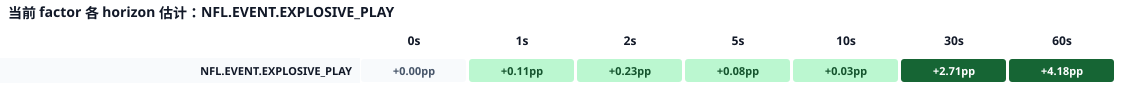

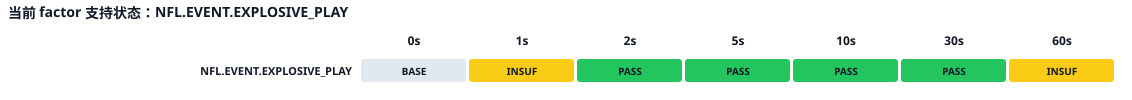

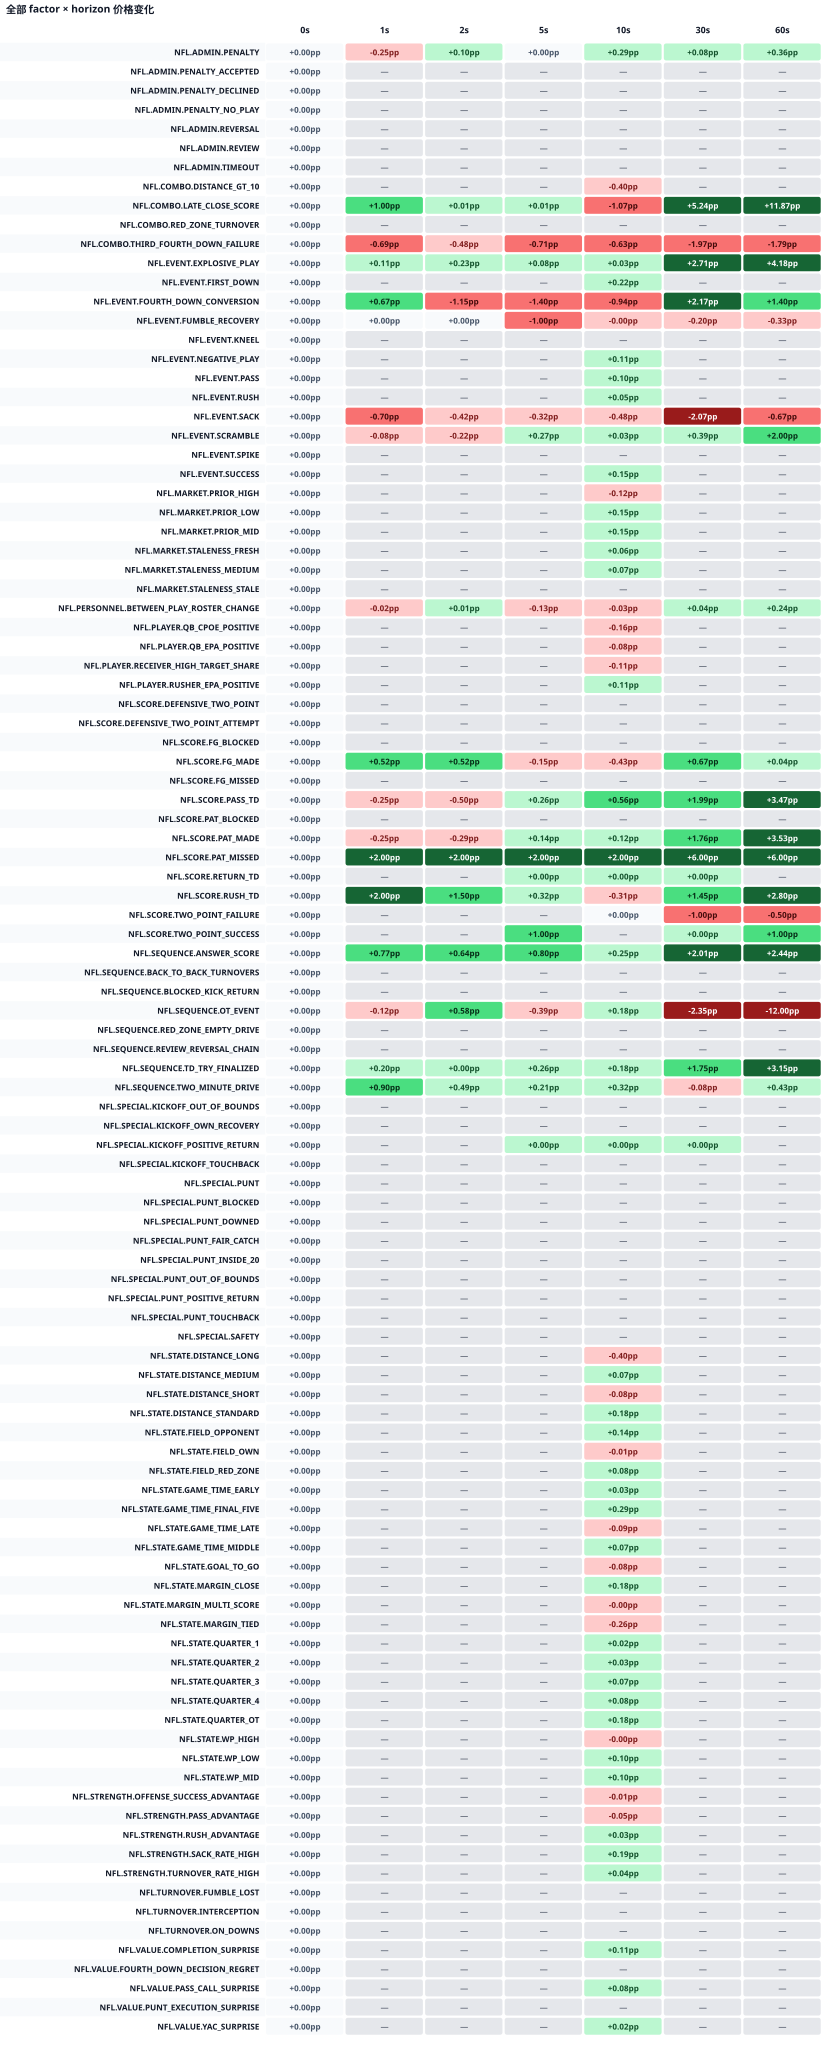

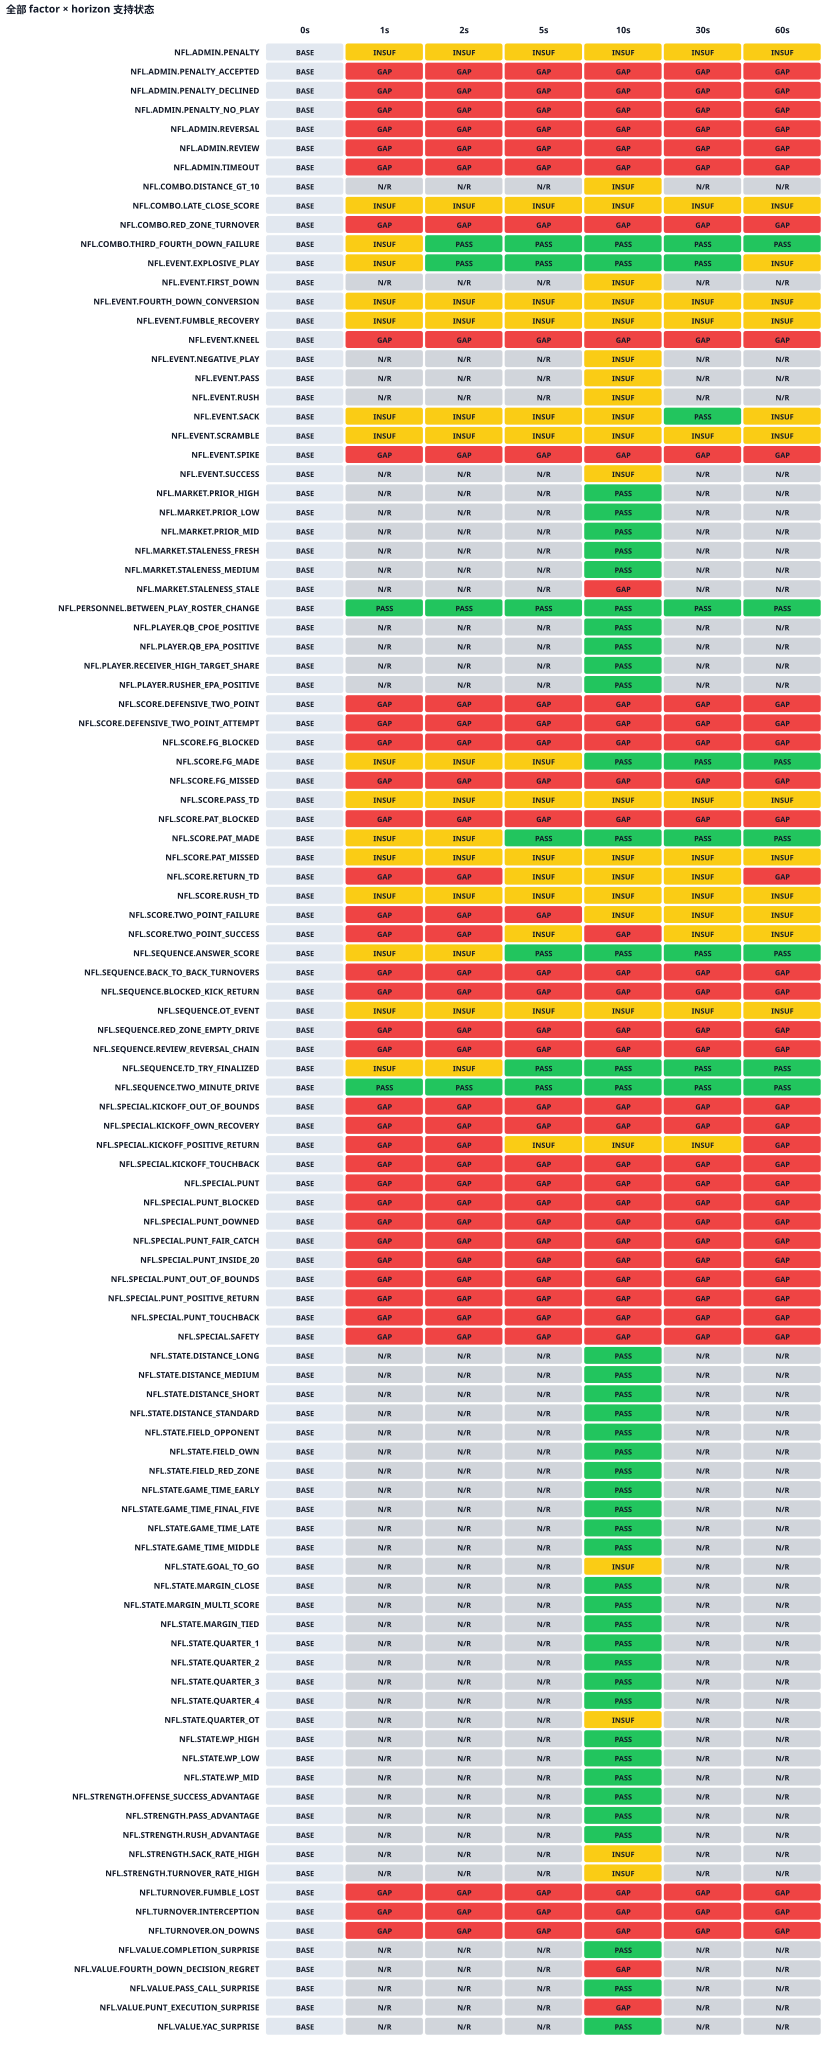

,factor_id,sports_meaning,predicate,pit_fields,exclusions,support_kind,minimum_episodes,minimum_games,minimum_episodes_per_venue,market_families,horizons_seconds
0,NFL.ADMIN.PENALTY,A play carrying a source-structured penalty indicator.,"[{'field': 'penalty', 'operator': 'eq', 'value': True}]",[penalty],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
1,NFL.ADMIN.PENALTY_ACCEPTED,A penalty with canonical structured status accepted; accepted no-play is a separate factor.,"[{'field': 'penalty_status', 'operator': 'eq', 'value': 'accepted'}]",[penalty_status],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
2,NFL.ADMIN.PENALTY_DECLINED,A penalty with canonical structured status declined.,"[{'field': 'penalty_status', 'operator': 'eq', 'value': 'declined'}]",[penalty_status],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
3,NFL.ADMIN.PENALTY_NO_PLAY,A penalty with canonical structured status accepted_no_play; the global event-eligibility gate may correctly leave t...,"[{'field': 'penalty_status', 'operator': 'eq', 'value': 'accepted_no_play'}]",[penalty_status],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
4,NFL.ADMIN.REVERSAL,A replay or challenge whose final structured result is reversed.,"[{'field': 'replay_result', 'operator': 'eq', 'value': 'reversed'}]",[replay_result],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
5,NFL.ADMIN.REVIEW,A source-structured replay or challenge episode.,"[{'field': 'replay_or_challenge', 'operator': 'eq', 'value': True}]",[replay_or_challenge],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
6,NFL.ADMIN.TIMEOUT,A source-structured team timeout.,"[{'field': 'timeout', 'operator': 'eq', 'value': True}]",[timeout],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
7,NFL.COMBO.DISTANCE_GT_10,The pre-snap yards-to-go is strictly greater than ten.,"[{'field': 'pre_distance', 'operator': 'gt', 'value': 10}]",[pre_distance],[],primary,300,16,100,[moneyline],[10]
8,NFL.COMBO.LATE_CLOSE_SCORE,A score in overtime or inside the final five minutes with the pre-event margin at most eight.,"[{'field': 'episode_is_score', 'operator': 'eq', 'value': True}, {'field': 'late_close_state', 'operator': 'eq', 'va...","[episode_is_score, late_close_state]",[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
9,NFL.COMBO.RED_ZONE_TURNOVER,A finalized turnover episode with pre-event yardline at or inside the opponent twenty.,"[{'field': 'episode_is_turnover', 'operator': 'eq', 'value': True}, {'field': 'pre_red_zone', 'operator': 'eq', 'val...","[episode_is_turnover, pre_red_zone]",[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"


In [12]:
factor_registry_ref = v2_source_refs.get("factor_registry_v1") or resolve_artifact_ref(prior_run_index, "factor_registry", project_root=ROOT)
factor_registry = read_json_object(factor_registry_ref.path, expected_schema="nfl_factor_registry_v1")
factor_registry_df = pd.json_normalize(factor_registry["factor_definitions"])
factor_registry_df.attrs.update({"status": "AVAILABLE", "source_path": str(factor_registry_ref.path), "source_sha256": factor_registry_ref.sha256, "source_row_count": len(factor_registry_df)})

discovery_manifest_ref = v2_source_refs.get("x13_prior_discovery_manifest_v1") or resolve_artifact_ref(prior_run_index, "discovery_manifest", project_root=ROOT)
discovery_publication = verify_factor_discovery_bundle(discovery_manifest_ref.path)
discovery_manifest = read_json_object(discovery_manifest_ref.path, expected_schema="FactorDiscoveryBundleV1")
result_descriptor = discovery_manifest["files"]["results"]
discovery_result_ref = ArtifactRef(
    name="factor_discovery_results",
    path=discovery_publication.result_path,
    sha256=result_descriptor["sha256"],
    byte_length=result_descriptor["byte_length"],
    row_count=discovery_publication.result_row_count,
    schema="FactorResultV1",
)
discovery_results_df = read_parquet_slice(discovery_result_ref, limit=5_000)
discovery_results_df.attrs["status"] = "PRIOR_EVIDENCE_V1"
discovery_results_df.attrs["reason"] = "V2 bundle unavailable; V1 publication fallback"
if cross_v2_bundle is not None:
    cross_game_results_v2_df = read_bundle_stage(cross_v2_bundle, "cross_game_factor_results", limit=5_000)
    factor_coverage_source_df = cross_game_results_v2_df
else:
    cross_game_results_v2_df = data_gap_frame(stage="cross_game_factor_results", grain="one factor × market × horizon", reason="V2 bundle unavailable; V1 publication fallback", expected_columns=("factor_id", "market_family", "horizon_seconds"))
    factor_coverage_source_df = discovery_results_df
coverage_groups = [name for name in ["factor_id", "support_status", "discovery_status"] if name in factor_coverage_source_df]
factor_coverage_df = factor_coverage_source_df.groupby(coverage_groups, dropna=False).size().rename("result_cells").reset_index()
factor_coverage_df.attrs.update(factor_coverage_source_df.attrs)
display(
    frame_audit(factor_registry_df, name="factor_registry_df", grain="one registered base factor"),
    factor_registry_df.head(15),
    frame_audit(cross_game_results_v2_df, name="cross_game_results_v2_df", grain="one V2 factor × market × horizon result"),
    cross_game_results_v2_df.head(15),
    frame_audit(factor_coverage_df, name="factor_coverage_df", grain="one factor × support/discovery status"),
    factor_coverage_df.head(25),
)

status_dictionary_df = pd.DataFrame([
    {"status": "DATA_GAP", "中文定义": "该 factor × horizon 没有严格有效的真实成交 observation", "是否有点估计": False, "能否判断规律": "不能"},
    {"status": "INSUFFICIENT_SUPPORT", "中文定义": "有 observation，但 episode/game/venue 覆盖低于预注册门槛", "是否有点估计": True, "能否判断规律": "只能 case/descriptive"},
    {"status": "PASS", "中文定义": "样本支持门通过；还要检查 CI、BH、LOO、单场贡献和双 venue", "是否有点估计": True, "能否判断规律": "继续审核"},
    {"status": "DESCRIPTIVE", "中文定义": "允许描述方向和幅度，但没有通过全部候选门", "是否有点估计": True, "能否判断规律": "描述性"},
    {"status": "AWAITING_EXPERT_REVIEW", "中文定义": "统计和稳定性门通过，等待体育机制审核", "是否有点估计": True, "能否判断规律": "候选，尚非 alpha"},
])
grain_dictionary_df = pd.DataFrame([
    {"dataframe": "factor_registry_df", "一行代表": "一个 factor 定义", "层级": "定义，不是比赛结果"},
    {"dataframe": "cross_game_results_v2_df", "一行代表": "factor × market family × horizon", "层级": "20 场 discovery 汇总"},
    {"dataframe": "game_contribution_df", "一行代表": "factor × horizon × game", "层级": "单场贡献（Section 13）"},
    {"dataframe": "factor_observations_df", "一行代表": "episode × market × outcome × venue × horizon × factor", "层级": "最底层实际观察"},
])
term_dictionary_df = pd.DataFrame([
    {"term": "factor", "中文解释": "事件或赛况的预先登记条件，例如 explosive play 或 third/fourth-down failure"},
    {"term": "episode", "中文解释": "已经合并 review、penalty、TD+PAT/2PT 的最终信息事件"},
    {"term": "horizon", "中文解释": "事件区间结束后寻找真实成交变化的观察时间"},
    {"term": "point_estimate", "中文解释": "20 场按 game 聚合后的平均 signed price change；0.01 = 1 个概率点"},
    {"term": "episode_count", "中文解释": "至少有一条严格观察的独立 finalized episode 数"},
    {"term": "game_count", "中文解释": "贡献了严格观察的不同比赛数，不一定等于 20"},
    {"term": "observation_count", "中文解释": "episode × outcome × venue 的严格实际成交观察数"},
    {"term": "CI", "中文解释": "按 game cluster bootstrap 的不确定性区间"},
    {"term": "LOO", "中文解释": "每次拿掉一场比赛，检查方向是否仍稳定"},
    {"term": "maximum_single_game_contribution", "中文解释": "单场占总绝对效应的最大比例；过大表示被个别比赛驱动"},
    {"term": "BH q-value", "中文解释": "对同时查看很多 factor/horizon 后进行多重检验修正"},
    {"term": "venue_sign_consistent", "中文解释": "Polymarket 与 Kalshi 的平均变化方向是否一致；不代表幅度相同"},
])
family_dictionary_df = pd.DataFrame([
    {"family_type": "factor family", "value": "EVENT", "中文解释": "单个 play/event，例如 pass、rush、sack、explosive play"},
    {"family_type": "factor family", "value": "SCORE / TURNOVER", "中文解释": "得分方式或球权冲击，例如 passing TD、INT、lost fumble"},
    {"family_type": "factor family", "value": "STATE", "中文解释": "事件前比赛状态，例如 red zone、goal-to-go、quarter"},
    {"family_type": "factor family", "value": "SEQUENCE", "中文解释": "跨多个 play 的顺序模式，例如 answer score、OT event"},
    {"family_type": "factor family", "value": "SPECIAL / ADMIN", "中文解释": "特殊球队、penalty、review、timeout 等"},
    {"family_type": "factor family", "value": "STRENGTH / PLAYER", "中文解释": "开赛前可知的球队或球员 rolling strength"},
    {"family_type": "factor family", "value": "COMBO", "中文解释": "已预注册的事件与状态组合"},
    {"family_type": "market family", "value": "moneyline", "中文解释": "比赛胜者合约；当前正式 factor observations 全部属于此类"},
    {"family_type": "market family", "value": "spread", "中文解释": "让分合约；已盘点但本轮未进入正式 factor runner"},
    {"family_type": "market family", "value": "total / team total", "中文解释": "总分或球队总分合约；已盘点但本轮未进入正式 factor runner"},
    {"family_type": "market family", "value": "period / player prop / composite", "中文解释": "节次、球员或组合合约；当前只做 inventory/case review"},
])
column_dictionary_df = pd.DataFrame([
    {"column": "factor_id", "grain": "definition/result", "中文定义": "factor 的稳定唯一 ID；前缀同时表示 factor family"},
    {"column": "factor_version", "grain": "definition/result", "中文定义": "factor 定义版本；定义变化必须产生新版本"},
    {"column": "sports_meaning", "grain": "definition", "中文定义": "这个 factor 在体育上的自然语言含义"},
    {"column": "predicate", "grain": "definition", "中文定义": "用哪些 PIT 字段和条件判断某个 episode 是否命中"},
    {"column": "pit_fields", "grain": "definition", "中文定义": "只能使用事件发生前已知的输入字段"},
    {"column": "focal_entity", "grain": "definition", "中文定义": "价格方向绑定到哪支球队、球员或 proposition subject"},
    {"column": "market_family", "grain": "result", "中文定义": "市场命题类型；当前正式结果是 moneyline，不是 factor 类别"},
    {"column": "horizon_seconds", "grain": "result", "中文定义": "finalized episode 的时间区间结束后，观察实际成交的秒数窗口"},
    {"column": "target", "grain": "definition/result", "中文定义": "研究目标；本轮为 signed_price_change"},
    {"column": "point_estimate", "grain": "20-game result", "中文定义": "对 focal outcome 定向后的平均价格变化；0.01 等于 1 个概率点"},
    {"column": "ci_low / ci_high", "grain": "20-game result", "中文定义": "按比赛聚类 bootstrap 的置信区间"},
    {"column": "episode_count", "grain": "result", "中文定义": "至少有一条严格有效观察的 finalized episode 数"},
    {"column": "game_count", "grain": "result", "中文定义": "实际贡献了观察的不同比赛数，最多 20"},
    {"column": "observation_count", "grain": "result", "中文定义": "episode × outcome × venue 的严格成交观察数，可能大于 episode_count"},
    {"column": "support_kind", "grain": "definition", "中文定义": "primary、named、sequence 或 binary；决定对应的最低样本门槛"},
    {"column": "minimum_episodes / minimum_games", "grain": "definition", "中文定义": "分析前冻结的最低 episode 和比赛覆盖门槛"},
    {"column": "support_status", "grain": "result", "中文定义": "DATA_GAP、INSUFFICIENT_SUPPORT 或 PASS；按 factor × horizon 判断"},
    {"column": "discovery_status", "grain": "result", "中文定义": "在支持门之后的研究状态，例如 DESCRIPTIVE 或 AWAITING_EXPERT_REVIEW"},
    {"column": "raw_p_value / bh_q_value", "grain": "result", "中文定义": "原始检验值与扫描多个 hypotheses 后的 BH 修正值"},
    {"column": "loo_sign_stability_rate", "grain": "result", "中文定义": "逐次拿掉一场比赛后，效应方向保持不变的比例"},
    {"column": "maximum_single_game_contribution", "grain": "result", "中文定义": "贡献最大的单场占总绝对效应比例；超过 25% 视为不稳定"},
    {"column": "kalshi_effect / polymarket_effect", "grain": "result", "中文定义": "两个 venue 分开计算的平均方向与幅度"},
    {"column": "venue_sign_consistent", "grain": "result", "中文定义": "两个 venue 是否同方向；不说明幅度或执行性一致"},
    {"column": "result_cells", "grain": "coverage summary", "中文定义": "属于该状态的 factor × horizon 格子数，不是事件数或比赛数"},
])
horizon_dictionary_df = pd.DataFrame([
    {"seconds": 0, "status": "BASELINE", "meaning": "事件前价格基准；变化定义为 0，不是 post-event observation"},
    *[{"seconds": value, "status": "REGISTERED", "meaning": "只使用该窗口内的实际成交；不 forward-fill"} for value in [1, 2, 5, 10, 30, 60]],
    {"seconds": 20, "status": "NOT_REGISTERED", "meaning": "当前 X-13 未注册；不能事后插值，需要新 amendment 才能正式计算"},
]).sort_values("seconds").reset_index(drop=True)

factor_definition_columns = [name for name in [
    "factor_id", "sports_meaning", "predicate", "pit_fields", "exclusions",
    "support_kind", "minimum_episodes", "minimum_games",
    "minimum_episodes_per_venue", "market_families", "horizons_seconds",
] if name in factor_registry_df]
factor_definition_dictionary_df = factor_registry_df[factor_definition_columns].sort_values("factor_id").reset_index(drop=True)

factor_status_summary_df = (
    factor_coverage_source_df.groupby("support_status", dropna=False)
    .agg(result_cells=("factor_id", "size"), unique_factors=("factor_id", "nunique"), cells_with_observations=("observation_count", lambda values: int(values.fillna(0).gt(0).sum())))
    .reset_index()
    .sort_values("support_status")
)
factor_horizon_results_df = factor_coverage_source_df[[
    "factor_id", "market_family", "horizon_seconds", "episode_count", "game_count",
    "observation_count", "point_estimate", "ci_low", "ci_high", "support_status",
    "discovery_status", "venue_sign_consistent",
]].copy()
factor_horizon_results_df["price_change_pp"] = factor_horizon_results_df["point_estimate"] * 100.0
factor_horizon_results_df["ci_low_pp"] = factor_horizon_results_df["ci_low"] * 100.0
factor_horizon_results_df["ci_high_pp"] = factor_horizon_results_df["ci_high"] * 100.0

registered_horizons = [1, 2, 5, 10, 30, 60]
all_factor_ids = sorted(factor_registry_df["factor_id"].astype(str).unique())
factor_effect_matrix_df = factor_horizon_results_df.pivot_table(index="factor_id", columns="horizon_seconds", values="price_change_pp", aggfunc="first").reindex(index=all_factor_ids, columns=registered_horizons)
factor_status_matrix_df = factor_horizon_results_df.pivot_table(index="factor_id", columns="horizon_seconds", values="support_status", aggfunc="first").reindex(index=all_factor_ids, columns=registered_horizons).fillna("NOT_REGISTERED")
factor_effect_matrix_df.insert(0, 0, 0.0)
factor_status_matrix_df.insert(0, 0, "BASELINE")
factor_effect_matrix_df.columns.name = "seconds_after_event"
factor_status_matrix_df.columns.name = "seconds_after_event"

def _signed_price_cell(value):
    if pd.isna(value):
        return "background-color:#e5e7eb !important;color:#6b7280 !important"
    if float(value) == 0.0:
        return "background-color:#f8fafc !important;color:#475569 !important"
    magnitude = abs(float(value))
    if float(value) > 0:
        background, foreground = (("#166534", "#ffffff") if magnitude >= 2.0 else ("#4ade80", "#052e16") if magnitude >= 0.5 else ("#bbf7d0", "#14532d"))
    else:
        background, foreground = (("#991b1b", "#ffffff") if magnitude >= 2.0 else ("#f87171", "#450a0a") if magnitude >= 0.5 else ("#fecaca", "#7f1d1d"))
    return f"background-color:{background} !important;color:{foreground} !important;font-weight:700"

def _format_price_change(value):
    if pd.isna(value):
        return "—"
    numeric = float(value)
    if numeric > 0:
        return f"🟩 ▲ +{numeric:.2f}pp"
    if numeric < 0:
        return f"🟥 ▼ {numeric:.2f}pp"
    return "⬜ 0.00pp"

def _support_cell(value):
    palette = {"BASELINE": "#e2e8f0", "PASS": "#bbf7d0", "INSUFFICIENT_SUPPORT": "#fef3c7", "DATA_GAP": "#fee2e2", "NOT_REGISTERED": "#f1f5f9"}
    return f"background-color:{palette.get(str(value), '#ffffff')} !important;color:#111827 !important;font-weight:650"

def _format_support_status(value):
    icons = {"BASELINE": "⬜", "PASS": "🟩", "INSUFFICIENT_SUPPORT": "🟨", "DATA_GAP": "🟥", "NOT_REGISTERED": "⬜"}
    return f"{icons.get(str(value), '⬜')} {value}"

def _value_fill(value):
    if pd.isna(value):
        return "#e5e7eb", "#6b7280"
    numeric = float(value)
    if numeric == 0:
        return "#f8fafc", "#475569"
    magnitude = abs(numeric)
    if numeric > 0:
        return (("#166534", "#ffffff") if magnitude >= 2.0 else ("#4ade80", "#052e16") if magnitude >= 0.5 else ("#bbf7d0", "#14532d"))
    return (("#991b1b", "#ffffff") if magnitude >= 2.0 else ("#f87171", "#450a0a") if magnitude >= 0.5 else ("#fecaca", "#7f1d1d"))

def _render_value_heatmap_svg(matrix, caption):
    label_width, cell_width, row_height, header_height = 360, 108, 26, 58
    width = label_width + cell_width * len(matrix.columns) + 16
    height = header_height + row_height * len(matrix.index) + 16
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">', '<rect width="100%" height="100%" fill="#ffffff"/>', f'<text x="8" y="18" font-family="sans-serif" font-size="14" font-weight="700" fill="#111827">{escape(caption)}</text>']
    for column_index, column in enumerate(matrix.columns):
        x = label_width + column_index * cell_width
        parts.append(f'<text x="{x + cell_width / 2}" y="45" text-anchor="middle" font-family="sans-serif" font-size="12" font-weight="700" fill="#111827">{escape(str(column))}s</text>')
    for row_index, (row_label, row) in enumerate(matrix.iterrows()):
        y = header_height + row_index * row_height
        parts.append(f'<rect x="0" y="{y}" width="{label_width}" height="{row_height - 1}" fill="{("#f8fafc" if row_index % 2 == 0 else "#ffffff")}"/>')
        parts.append(f'<text x="{label_width - 8}" y="{y + 17}" text-anchor="end" font-family="sans-serif" font-size="11" font-weight="600" fill="#111827">{escape(str(row_label))}</text>')
        for column_index, value in enumerate(row):
            x = label_width + column_index * cell_width
            fill, text_color = _value_fill(value)
            label = "—" if pd.isna(value) else f'{float(value):+.2f}pp'
            parts.append(f'<rect x="{x + 1}" y="{y + 1}" width="{cell_width - 3}" height="{row_height - 3}" rx="3" fill="{fill}"/>')
            parts.append(f'<text x="{x + cell_width / 2}" y="{y + 17}" text-anchor="middle" font-family="sans-serif" font-size="11" font-weight="700" fill="{text_color}">{escape(label)}</text>')
    parts.append('</svg>')
    return SVG(data=''.join(parts))

def _render_status_heatmap_svg(matrix, caption):
    palette = {"BASELINE": ("#e2e8f0", "BASE"), "PASS": ("#22c55e", "PASS"), "INSUFFICIENT_SUPPORT": ("#facc15", "INSUF"), "DATA_GAP": ("#ef4444", "GAP"), "NOT_REGISTERED": ("#d1d5db", "N/R")}
    label_width, cell_width, row_height, header_height = 360, 108, 26, 58
    width = label_width + cell_width * len(matrix.columns) + 16
    height = header_height + row_height * len(matrix.index) + 16
    parts = [f'<svg xmlns="http://www.w3.org/2000/svg" width="{width}" height="{height}" viewBox="0 0 {width} {height}">', '<rect width="100%" height="100%" fill="#ffffff"/>', f'<text x="8" y="18" font-family="sans-serif" font-size="14" font-weight="700" fill="#111827">{escape(caption)}</text>']
    for column_index, column in enumerate(matrix.columns):
        x = label_width + column_index * cell_width
        parts.append(f'<text x="{x + cell_width / 2}" y="45" text-anchor="middle" font-family="sans-serif" font-size="12" font-weight="700" fill="#111827">{escape(str(column))}s</text>')
    for row_index, (row_label, row) in enumerate(matrix.iterrows()):
        y = header_height + row_index * row_height
        parts.append(f'<text x="{label_width - 8}" y="{y + 17}" text-anchor="end" font-family="sans-serif" font-size="11" font-weight="600" fill="#111827">{escape(str(row_label))}</text>')
        for column_index, value in enumerate(row):
            x = label_width + column_index * cell_width
            fill, label = palette.get(str(value), ("#d1d5db", "N/A"))
            parts.append(f'<rect x="{x + 1}" y="{y + 1}" width="{cell_width - 3}" height="{row_height - 3}" rx="3" fill="{fill}"/>')
            parts.append(f'<text x="{x + cell_width / 2}" y="{y + 17}" text-anchor="middle" font-family="sans-serif" font-size="10" font-weight="800" fill="#111827">{label}</text>')
    parts.append('</svg>')
    return SVG(data=''.join(parts))

factor_effect_heatmap = factor_effect_matrix_df.style.map(_signed_price_cell).format(_format_price_change).set_caption("价格变化热力表：factor × seconds after event（绿色/▲ 上升，红色/▼ 下降，单位概率点）")
factor_status_heatmap = factor_status_matrix_df.style.map(_support_cell).format(_format_support_status).set_caption("样本支持热力表：PASS / INSUFFICIENT_SUPPORT / DATA_GAP / NOT_REGISTERED")
selected_factor_path_df = factor_horizon_results_df[
    factor_horizon_results_df["factor_id"].eq(FACTOR_ID)
    & factor_horizon_results_df["market_family"].eq(MARKET_FAMILY)
].sort_values("horizon_seconds").reset_index(drop=True)
selected_factor_path_df = pd.concat([
    pd.DataFrame([{"factor_id": FACTOR_ID, "market_family": MARKET_FAMILY, "horizon_seconds": 0, "price_change_pp": 0.0, "ci_low_pp": 0.0, "ci_high_pp": 0.0, "episode_count": pd.NA, "game_count": 20, "observation_count": pd.NA, "support_status": "BASELINE", "discovery_status": "BASELINE", "venue_sign_consistent": pd.NA}]),
    selected_factor_path_df,
], ignore_index=True)
selected_factor_effect_heatmap = factor_effect_matrix_df.loc[[FACTOR_ID]].style.map(_signed_price_cell).format(_format_price_change).set_caption(f"当前 factor 各 horizon 估计（每列样本可能不同）：{FACTOR_ID}")
selected_factor_status_heatmap = factor_status_matrix_df.loc[[FACTOR_ID]].style.map(_support_cell).format(_format_support_status).set_caption(f"当前 factor 支持状态：{FACTOR_ID}")
selected_factor_effect_svg = _render_value_heatmap_svg(factor_effect_matrix_df.loc[[FACTOR_ID]], f"当前 factor 各 horizon 估计：{FACTOR_ID}")
selected_factor_status_svg = _render_status_heatmap_svg(factor_status_matrix_df.loc[[FACTOR_ID]], f"当前 factor 支持状态：{FACTOR_ID}")
factor_effect_svg = _render_value_heatmap_svg(factor_effect_matrix_df, "全部 factor × horizon 价格变化")
factor_status_svg = _render_status_heatmap_svg(factor_status_matrix_df, "全部 factor × horizon 支持状态")

display(status_dictionary_df, grain_dictionary_df, family_dictionary_df, horizon_dictionary_df, term_dictionary_df, column_dictionary_df)
display(factor_status_summary_df)
display(selected_factor_path_df[["factor_id", "horizon_seconds", "episode_count", "game_count", "observation_count", "price_change_pp", "ci_low_pp", "ci_high_pp", "support_status", "discovery_status", "venue_sign_consistent"]])
display(selected_factor_effect_svg, selected_factor_status_svg)
display(factor_effect_svg, factor_status_svg)
with pd.option_context("display.max_rows", None, "display.max_colwidth", 120):
    display(factor_definition_dictionary_df)

### 9.1 Factor impact heatmaps — START HERE

第一张小表和小热力图显示当前 `FACTOR_ID` 的各 horizon 估计；第二张大热力图显示全部 factor。绿色表示 focal outcome 概率上升，红色表示下降，单位是概率点（pp）。灰色不是零，而是没有正式估计。支持状态表随后解释该 cell 是 `PASS`、`INSUFFICIENT_SUPPORT`、`DATA_GAP` 还是未注册。

**重要：这不是 matched-cohort 连续曲线。** 每个 horizon 只使用该窗口存在严格实际成交的 episode，因此 1 秒、5 秒、30 秒的样本数可能不同。比较颜色可以用于发现候选，但不能把变化直接解释成同一批事件的连续加速、overshoot 或 reversal。

热力图之后才是 family、horizon、column 和完整 factor definition 字典。

,factor_id,horizon_seconds,episode_count,game_count,observation_count,price_change_pp,ci_low_pp,ci_high_pp,support_status,discovery_status,venue_sign_consistent
0,NFL.EVENT.EXPLOSIVE_PLAY,0,<NA>,20,<NA>,0.000000,0.000000,0.000000,BASELINE,BASELINE,<NA>
1,NFL.EVENT.EXPLOSIVE_PLAY,1,14,10,14,0.113001,-0.433364,0.996730,INSUFFICIENT_SUPPORT,INSUFFICIENT_SUPPORT,False
2,NFL.EVENT.EXPLOSIVE_PLAY,2,27,15,27,0.229611,-0.188223,0.775781,PASS,DESCRIPTIVE,False
3,NFL.EVENT.EXPLOSIVE_PLAY,5,47,19,49,0.078452,-0.213515,0.332779,PASS,DESCRIPTIVE,False
4,NFL.EVENT.EXPLOSIVE_PLAY,10,63,17,65,0.032669,-0.366938,0.418412,PASS,DESCRIPTIVE,True
5,NFL.EVENT.EXPLOSIVE_PLAY,30,58,18,60,2.705885,1.760498,3.908528,PASS,AWAITING_EXPERT_REVIEW,True
6,NFL.EVENT.EXPLOSIVE_PLAY,60,17,12,17,4.180852,2.399822,6.294115,INSUFFICIENT_SUPPORT,INSUFFICIENT_SUPPORT,True


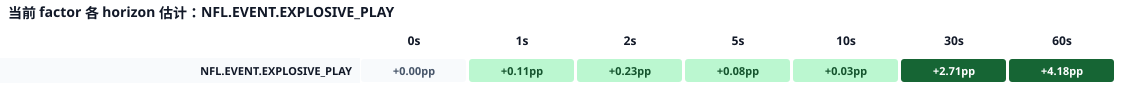

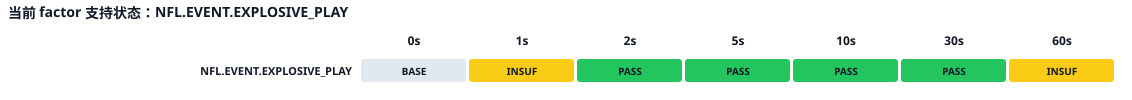

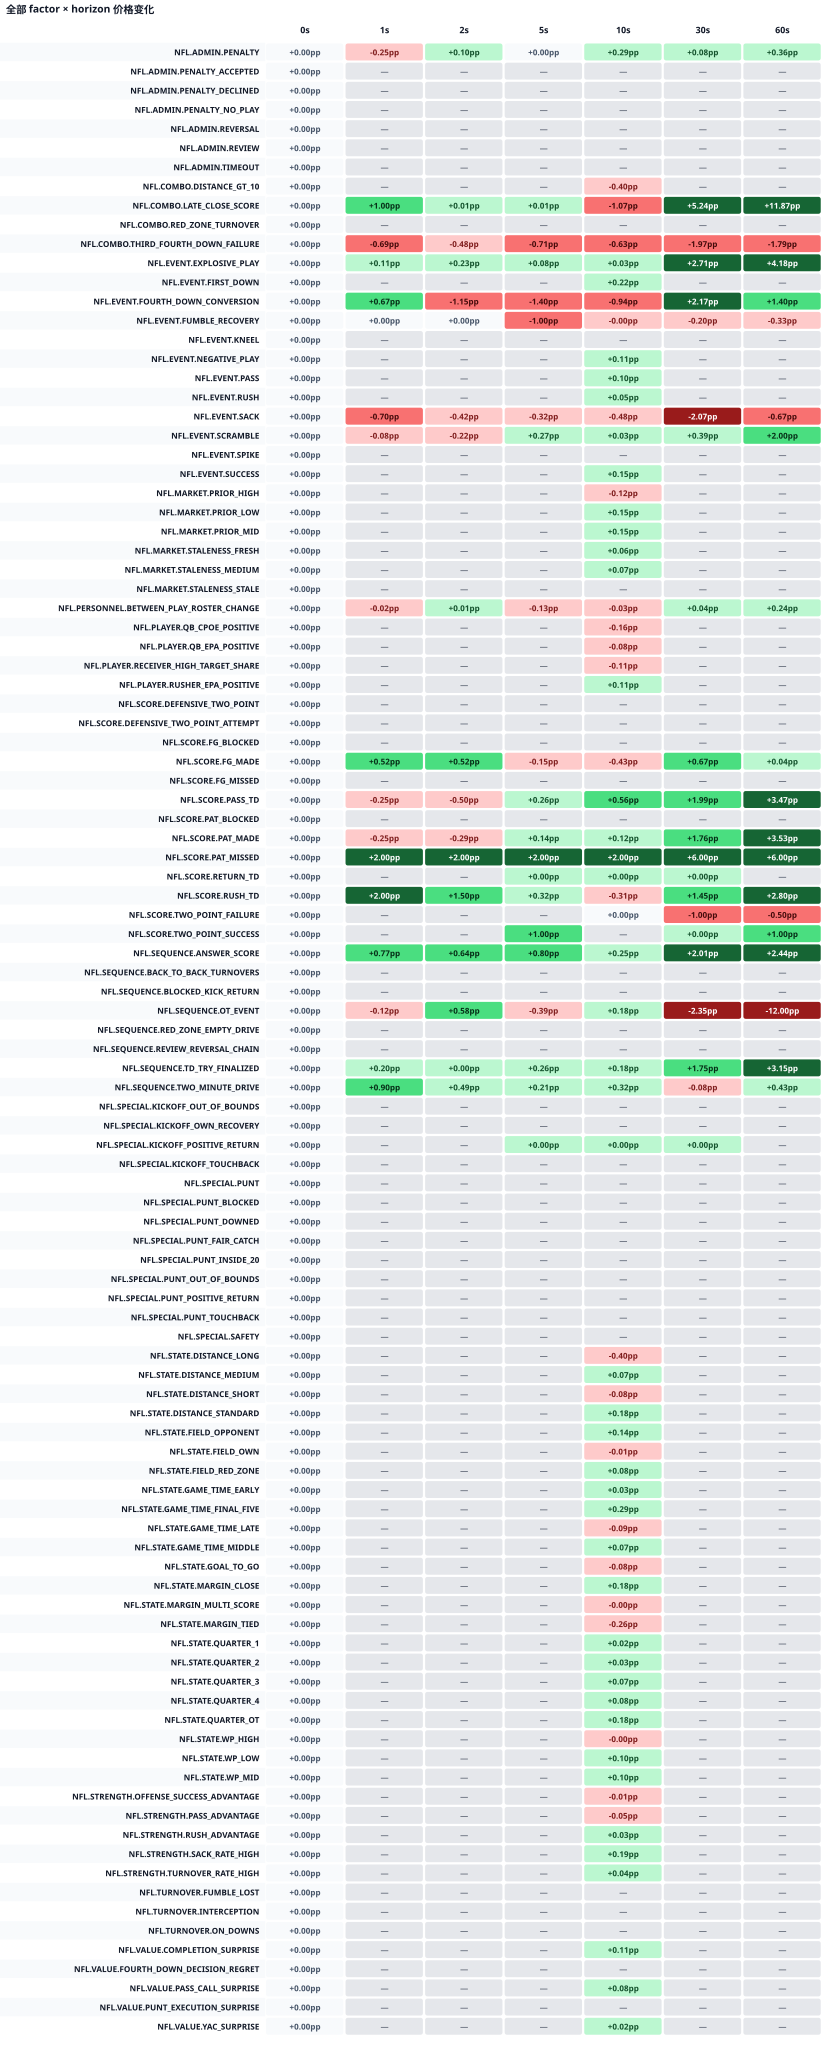

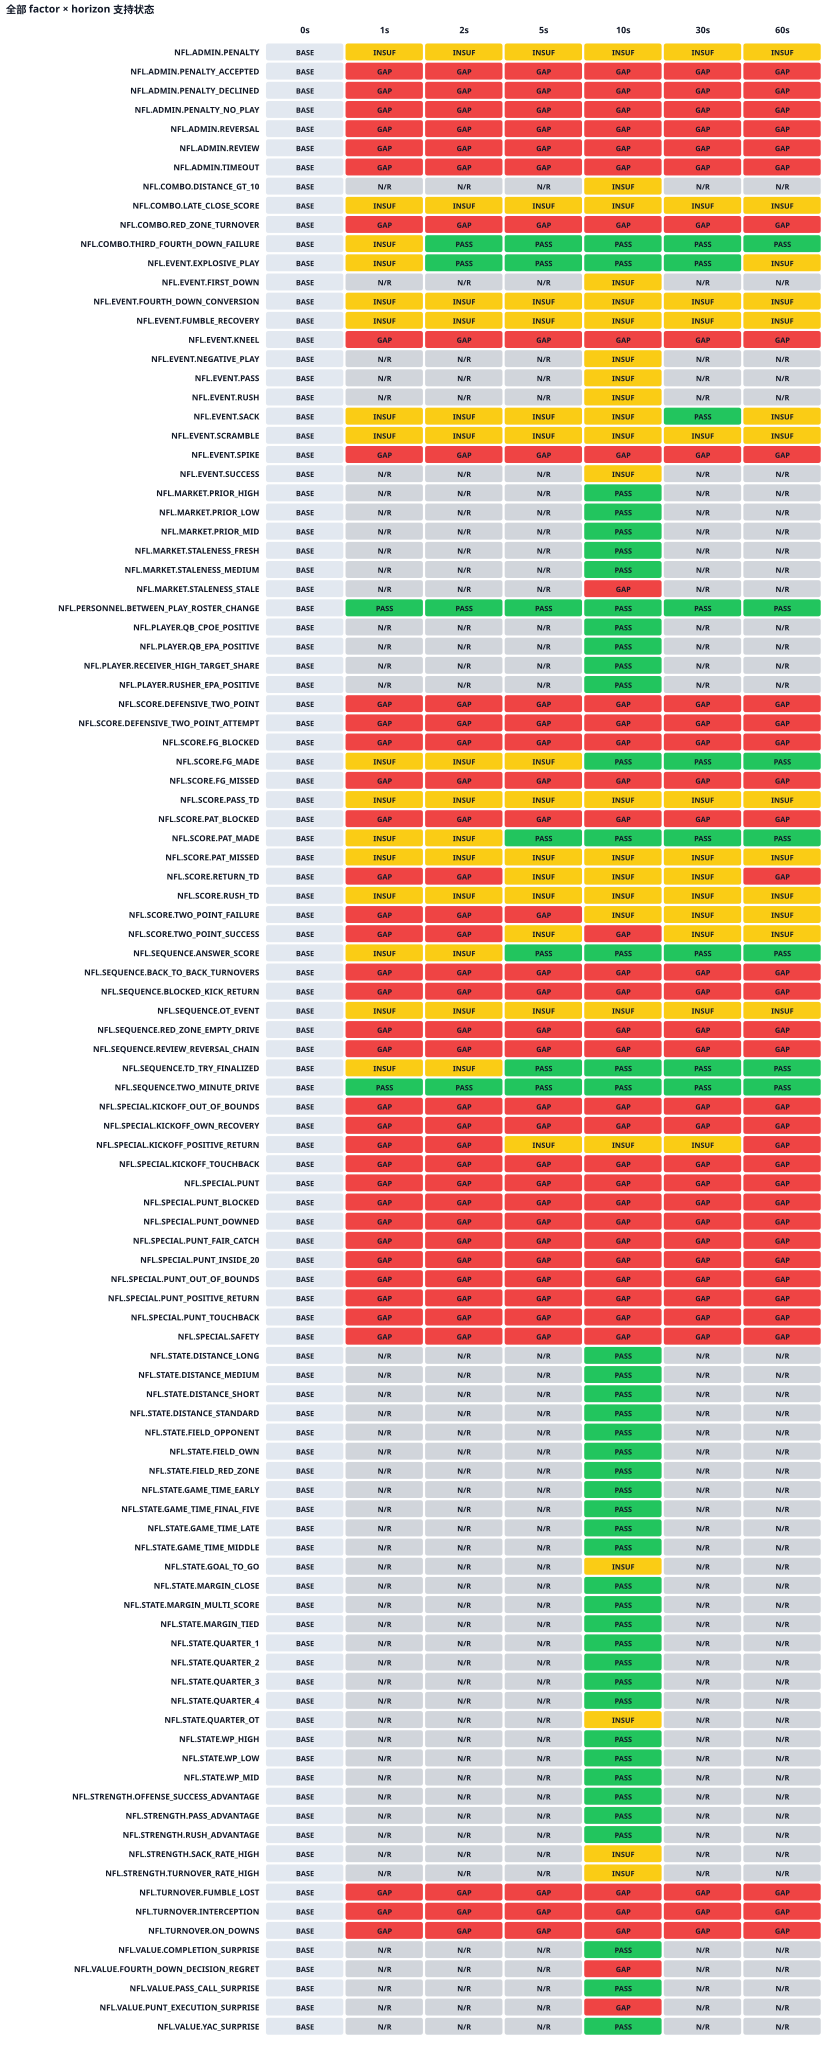

,status,中文定义,是否有点估计,能否判断规律
0,DATA_GAP,该 factor × horizon 没有严格有效的真实成交 observation,False,不能
1,INSUFFICIENT_SUPPORT,有 observation，但 episode/game/venue 覆盖低于预注册门槛,True,只能 case/descriptive
2,PASS,样本支持门通过；还要检查 CI、BH、LOO、单场贡献和双 venue,True,继续审核
3,DESCRIPTIVE,允许描述方向和幅度，但没有通过全部候选门,True,描述性
4,AWAITING_EXPERT_REVIEW,统计和稳定性门通过，等待体育机制审核,True,候选，尚非 alpha


,dataframe,一行代表,层级
0,factor_registry_df,一个 factor 定义,定义，不是比赛结果
1,cross_game_results_v2_df,factor × market family × horizon,20 场 discovery 汇总
2,game_contribution_df,factor × horizon × game,单场贡献（Section 13）
3,factor_observations_df,episode × market × outcome × venue × horizon ×...,最底层实际观察


,family_type,value,中文解释
0,factor family,EVENT,单个 play/event，例如 pass、rush、sack、explosive play
1,factor family,SCORE / TURNOVER,得分方式或球权冲击，例如 passing TD、INT、lost fumble
2,factor family,STATE,事件前比赛状态，例如 red zone、goal-to-go、quarter
3,factor family,SEQUENCE,跨多个 play 的顺序模式，例如 answer score、OT event
4,factor family,SPECIAL / ADMIN,特殊球队、penalty、review、timeout 等
5,factor family,STRENGTH / PLAYER,开赛前可知的球队或球员 rolling strength
6,factor family,COMBO,已预注册的事件与状态组合
7,market family,moneyline,比赛胜者合约；当前正式 factor observations 全部属于此类
8,market family,spread,让分合约；已盘点但本轮未进入正式 factor runner
9,market family,total / team total,总分或球队总分合约；已盘点但本轮未进入正式 factor runner


,seconds,status,meaning
0,0,BASELINE,事件前价格基准；变化定义为 0，不是 post-event observation
1,1,REGISTERED,只使用该窗口内的实际成交；不 forward-fill
2,2,REGISTERED,只使用该窗口内的实际成交；不 forward-fill
3,5,REGISTERED,只使用该窗口内的实际成交；不 forward-fill
4,10,REGISTERED,只使用该窗口内的实际成交；不 forward-fill
5,20,NOT_REGISTERED,当前 X-13 未注册；不能事后插值，需要新 amendment 才能正式计算
6,30,REGISTERED,只使用该窗口内的实际成交；不 forward-fill
7,60,REGISTERED,只使用该窗口内的实际成交；不 forward-fill


,term,中文解释
0,factor,事件或赛况的预先登记条件，例如 explosive play 或 third/fourth-...
1,episode,已经合并 review、penalty、TD+PAT/2PT 的最终信息事件
2,horizon,事件区间结束后寻找真实成交变化的观察时间
3,point_estimate,20 场按 game 聚合后的平均 signed price change；0.01 = 1...
4,episode_count,至少有一条严格观察的独立 finalized episode 数
5,game_count,贡献了严格观察的不同比赛数，不一定等于 20
6,observation_count,episode × outcome × venue 的严格实际成交观察数
7,CI,按 game cluster bootstrap 的不确定性区间
8,LOO,每次拿掉一场比赛，检查方向是否仍稳定
9,maximum_single_game_contribution,单场占总绝对效应的最大比例；过大表示被个别比赛驱动


,column,grain,中文定义
0,factor_id,definition/result,factor 的稳定唯一 ID；前缀同时表示 factor family
1,factor_version,definition/result,factor 定义版本；定义变化必须产生新版本
2,sports_meaning,definition,这个 factor 在体育上的自然语言含义
3,predicate,definition,用哪些 PIT 字段和条件判断某个 episode 是否命中
4,pit_fields,definition,只能使用事件发生前已知的输入字段
5,focal_entity,definition,价格方向绑定到哪支球队、球员或 proposition subject
6,market_family,result,市场命题类型；当前正式结果是 moneyline，不是 factor 类别
7,horizon_seconds,result,finalized episode 的时间区间结束后，观察实际成交的秒数窗口
8,target,definition/result,研究目标；本轮为 signed_price_change
9,point_estimate,20-game result,对 focal outcome 定向后的平均价格变化；0.01 等于 1 个概率点


,support_status,result_cells,unique_factors,cells_with_observations
0,DATA_GAP,213,40,0
1,INSUFFICIENT_SUPPORT,93,30,93
2,PASS,73,45,73


,factor_id,sports_meaning,predicate,pit_fields,exclusions,support_kind,minimum_episodes,minimum_games,minimum_episodes_per_venue,market_families,horizons_seconds
0,NFL.ADMIN.PENALTY,A play carrying a source-structured penalty indicator.,"[{'field': 'penalty', 'operator': 'eq', 'value': True}]",[penalty],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
1,NFL.ADMIN.PENALTY_ACCEPTED,A penalty with canonical structured status accepted; accepted no-play is a separate factor.,"[{'field': 'penalty_status', 'operator': 'eq', 'value': 'accepted'}]",[penalty_status],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
2,NFL.ADMIN.PENALTY_DECLINED,A penalty with canonical structured status declined.,"[{'field': 'penalty_status', 'operator': 'eq', 'value': 'declined'}]",[penalty_status],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
3,NFL.ADMIN.PENALTY_NO_PLAY,A penalty with canonical structured status accepted_no_play; the global event-eligibility gate may correctly leave t...,"[{'field': 'penalty_status', 'operator': 'eq', 'value': 'accepted_no_play'}]",[penalty_status],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
4,NFL.ADMIN.REVERSAL,A replay or challenge whose final structured result is reversed.,"[{'field': 'replay_result', 'operator': 'eq', 'value': 'reversed'}]",[replay_result],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
5,NFL.ADMIN.REVIEW,A source-structured replay or challenge episode.,"[{'field': 'replay_or_challenge', 'operator': 'eq', 'value': True}]",[replay_or_challenge],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
6,NFL.ADMIN.TIMEOUT,A source-structured team timeout.,"[{'field': 'timeout', 'operator': 'eq', 'value': True}]",[timeout],[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
7,NFL.COMBO.DISTANCE_GT_10,The pre-snap yards-to-go is strictly greater than ten.,"[{'field': 'pre_distance', 'operator': 'gt', 'value': 10}]",[pre_distance],[],primary,300,16,100,[moneyline],[10]
8,NFL.COMBO.LATE_CLOSE_SCORE,A score in overtime or inside the final five minutes with the pre-event margin at most eight.,"[{'field': 'episode_is_score', 'operator': 'eq', 'value': True}, {'field': 'late_close_state', 'operator': 'eq', 'va...","[episode_is_score, late_close_state]",[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"
9,NFL.COMBO.RED_ZONE_TURNOVER,A finalized turnover episode with pre-event yardline at or inside the opponent twenty.,"[{'field': 'episode_is_turnover', 'operator': 'eq', 'value': True}, {'field': 'pre_red_zone', 'operator': 'eq', 'val...","[episode_is_turnover, pre_red_zone]",[],named,20,6,0,[moneyline],"[1, 2, 5, 10, 30, 60]"


In [13]:
display(selected_factor_path_df[["factor_id", "horizon_seconds", "episode_count", "game_count", "observation_count", "price_change_pp", "ci_low_pp", "ci_high_pp", "support_status", "discovery_status", "venue_sign_consistent"]])
display(selected_factor_effect_svg, selected_factor_status_svg)
display(factor_effect_svg, factor_status_svg)
display(status_dictionary_df, grain_dictionary_df, family_dictionary_df, horizon_dictionary_df, term_dictionary_df, column_dictionary_df)
display(factor_status_summary_df)
with pd.option_context("display.max_rows", None, "display.max_colwidth", 120):
    display(factor_definition_dictionary_df)

### 9.2 Game-relative-time breakdown coverage

这里区分三个问题：

1. **State-only：** Q1/Q2/Q3/Q4/OT、比赛剩余时间、比分差和 WP band 单独对应的市场变化——已经计算，主要是 10 秒 horizon。
2. **Event × state：** 同一个 TD、turnover、pass、rush 在不同 quarter/time/margin 下是否反应不同——registry 有二维模板，但本轮没有 materialized interaction result。
3. **Event × time × margin：** 三维组合——当前未注册，也不能在看到结果后无约束穷举。

因此下面的 state 表只能说明“该状态下所有符合条件事件的平均变化”，不能替代 `event × game-relative-time` breakdown。

,analysis_level,example,registered,materialized_result_cells,status
0,state-only,Q4 or final-five,True,18,AVAILABLE_AT_10S
1,event × state,turnover × Q4,True,0,TEMPLATE_ONLY_NOT_RUN
2,event × time × margin,INT × final-five × close game,False,0,NOT_REGISTERED


,breakdown_group,factor_id,horizon_seconds,episode_count,game_count,observation_count,price_change_pp,ci_low_pp,ci_high_pp,support_status,discovery_status
0,pre-event WP band,NFL.STATE.WP_HIGH,10,207,20,215,-0.001776,-0.143757,0.143519,PASS,DESCRIPTIVE_CONDITIONAL_MEAN
1,pre-event WP band,NFL.STATE.WP_LOW,10,187,19,195,0.097217,-0.163874,0.423206,PASS,DESCRIPTIVE_CONDITIONAL_MEAN
2,pre-event WP band,NFL.STATE.WP_MID,10,206,17,206,0.101397,-0.346044,0.549838,PASS,DESCRIPTIVE_CONDITIONAL_MEAN
3,quarter / OT,NFL.SEQUENCE.OT_EVENT,10,22,4,22,0.181052,-1.080964,2.513680,INSUFFICIENT_SUPPORT,INSUFFICIENT_SUPPORT
4,quarter / OT,NFL.STATE.QUARTER_1,10,113,20,120,0.020158,-0.234301,0.323923,PASS,DESCRIPTIVE_CONDITIONAL_MEAN
5,quarter / OT,NFL.STATE.QUARTER_2,10,147,20,147,0.029868,-0.160354,0.213794,PASS,DESCRIPTIVE_CONDITIONAL_MEAN
6,quarter / OT,NFL.STATE.QUARTER_3,10,141,20,143,0.072718,-0.103788,0.253274,PASS,DESCRIPTIVE_CONDITIONAL_MEAN
7,quarter / OT,NFL.STATE.QUARTER_4,10,173,20,180,0.080318,-0.405732,0.534825,PASS,DESCRIPTIVE_CONDITIONAL_MEAN
8,quarter / OT,NFL.STATE.QUARTER_OT,10,22,4,22,0.181052,-1.080964,2.513680,INSUFFICIENT_SUPPORT,INSUFFICIENT_SUPPORT
9,remaining game time,NFL.SEQUENCE.TWO_MINUTE_DRIVE,10,71,18,72,0.324190,-0.327027,0.942615,PASS,DESCRIPTIVE


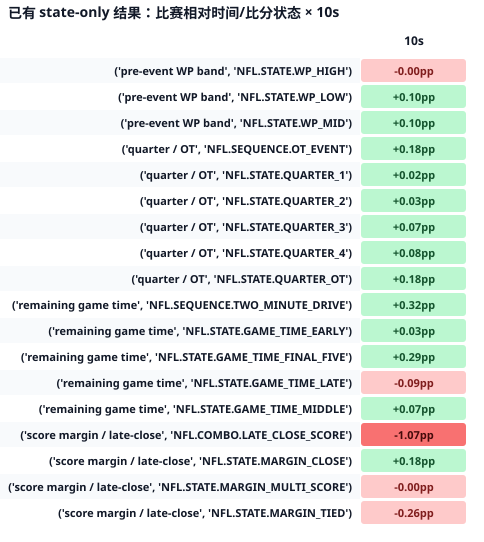

In [14]:
def _time_breakdown_group(factor_id):
    if factor_id.startswith("NFL.STATE.QUARTER_") or factor_id == "NFL.SEQUENCE.OT_EVENT":
        return "quarter / OT"
    if factor_id.startswith("NFL.STATE.GAME_TIME_") or factor_id == "NFL.SEQUENCE.TWO_MINUTE_DRIVE":
        return "remaining game time"
    if factor_id.startswith("NFL.STATE.MARGIN_") or factor_id == "NFL.COMBO.LATE_CLOSE_SCORE":
        return "score margin / late-close"
    if factor_id.startswith("NFL.STATE.WP_"):
        return "pre-event WP band"
    return None

state_time_breakdown_df = factor_horizon_results_df[factor_horizon_results_df["horizon_seconds"].eq(10)].copy()
state_time_breakdown_df["breakdown_group"] = state_time_breakdown_df["factor_id"].map(_time_breakdown_group)
state_time_breakdown_df = state_time_breakdown_df[state_time_breakdown_df["breakdown_group"].notna()].sort_values(["breakdown_group", "factor_id"]).reset_index(drop=True)
state_time_breakdown_heatmap_df = state_time_breakdown_df.pivot_table(index=["breakdown_group", "factor_id"], columns="horizon_seconds", values="price_change_pp", aggfunc="first").reindex(columns=[10])
state_time_breakdown_heatmap = state_time_breakdown_heatmap_df.style.map(_signed_price_cell).format(_format_price_change).set_caption("已有 state-only 结果：比赛相对时间/比分状态 × 10s")
state_time_breakdown_svg = _render_value_heatmap_svg(state_time_breakdown_heatmap_df, "已有 state-only 结果：比赛相对时间/比分状态 × 10s")
registered_interaction_templates = factor_registry.get("interaction_templates", [])
materialized_interaction_cells = int(factor_horizon_results_df["factor_id"].astype(str).str.contains("INTERACTION|_X_", regex=True).sum())
breakdown_scope_df = pd.DataFrame([
    {"analysis_level": "state-only", "example": "Q4 or final-five", "registered": True, "materialized_result_cells": len(state_time_breakdown_df), "status": "AVAILABLE_AT_10S"},
    {"analysis_level": "event × state", "example": "turnover × Q4", "registered": bool(registered_interaction_templates), "materialized_result_cells": materialized_interaction_cells, "status": "TEMPLATE_ONLY_NOT_RUN" if materialized_interaction_cells == 0 else "AVAILABLE"},
    {"analysis_level": "event × time × margin", "example": "INT × final-five × close game", "registered": False, "materialized_result_cells": 0, "status": "NOT_REGISTERED"},
])
display(breakdown_scope_df)
display(state_time_breakdown_df[["breakdown_group", "factor_id", "horizon_seconds", "episode_count", "game_count", "observation_count", "price_change_pp", "ci_low_pp", "ci_high_pp", "support_status", "discovery_status"]])
display(state_time_breakdown_svg)

### 9.3 Exact and relative game-time coordinates

Quarter 不是唯一时间坐标。Canonical feature 已保存具体 period clock、half/game remaining、source wall-clock time 和 drive-relative position。这里展示真实字段、派生公式、当前比赛覆盖及具体样例。

`source_wall_clock_elapsed_seconds` 代表数据源时间从 scheduled kickoff 起经过的现实时间，包含暂停、广告和 halftime；它不能替代比赛时钟。OT 不强行映射到 60 分钟 regulation progress，而是单独保留 period clock。

In [15]:
time_coordinate_dictionary_df = pd.DataFrame([
    {"coordinate": "source_time_utc", "type": "source wall clock", "definition": "供应商记录的事件 UTC 秒级时间；不是本地 receive time"},
    {"coordinate": "quarter / pre_quarter", "type": "period", "definition": "事件所在 Q1–Q4 或 OT period"},
    {"coordinate": "quarter_seconds_remaining", "type": "exact period clock", "definition": "该 period 剩余秒数；可还原成 Qx MM:SS"},
    {"coordinate": "half_seconds_remaining", "type": "half-relative", "definition": "当前 half 剩余秒数；halftime 后重新计数"},
    {"coordinate": "game_seconds_remaining", "type": "regulation-relative", "definition": "regulation 剩余秒数；Q1–Q4 可派生 elapsed/progress"},
    {"coordinate": "regulation_elapsed_seconds", "type": "derived", "definition": "Q1–Q4: 3600 - game_seconds_remaining"},
    {"coordinate": "regulation_progress", "type": "derived normalized", "definition": "Q1–Q4: regulation_elapsed_seconds / 3600，范围 0–1"},
    {"coordinate": "drive_play_index", "type": "drive-relative", "definition": "本次 drive 内第几个 play"},
    {"coordinate": "drive_yards_before / drive_progression_yards_before", "type": "drive-relative", "definition": "事件发生前该 drive 已推进状态"},
    {"coordinate": "source_wall_clock_elapsed_seconds", "type": "derived wall clock", "definition": "source_time_utc - scheduled kickoff；包含比赛停表时间"},
])
time_source_columns = [name for name in ["game_id", "play_id", "episode_id", "source_time_utc", "kickoff_at_utc", "pre_quarter", "quarter", "quarter_seconds_remaining", "half_seconds_remaining", "game_seconds_remaining", "drive_id", "drive_play_index", "drive_yards_before", "drive_progression_yards_before"] if name in feature_view_df]
time_coordinate_examples_df = feature_view_df[time_source_columns].copy()
period_value = pd.to_numeric(time_coordinate_examples_df.get("pre_quarter", time_coordinate_examples_df.get("quarter")), errors="coerce")
quarter_remaining = pd.to_numeric(time_coordinate_examples_df.get("quarter_seconds_remaining"), errors="coerce")
game_remaining = pd.to_numeric(time_coordinate_examples_df.get("game_seconds_remaining"), errors="coerce")
half_remaining = pd.to_numeric(time_coordinate_examples_df.get("half_seconds_remaining"), errors="coerce")
time_coordinate_examples_df["is_overtime"] = period_value.gt(4)
time_coordinate_examples_df["period_clock"] = period_value.map(lambda value: f"Q{int(value)}" if pd.notna(value) and value <= 4 else "OT" if pd.notna(value) else "UNKNOWN") + " " + quarter_remaining.map(lambda value: f"{int(value) // 60:02d}:{int(value) % 60:02d}" if pd.notna(value) else "--:--")
time_coordinate_examples_df["regulation_elapsed_seconds"] = (3600.0 - game_remaining).where(period_value.le(4))
time_coordinate_examples_df["regulation_progress"] = (time_coordinate_examples_df["regulation_elapsed_seconds"] / 3600.0).where(period_value.le(4))
time_coordinate_examples_df["half_elapsed_seconds"] = (1800.0 - half_remaining).where(period_value.le(4))
source_clock = pd.to_datetime(time_coordinate_examples_df.get("source_time_utc"), utc=True, errors="coerce")
kickoff_clock = pd.to_datetime(time_coordinate_examples_df.get("kickoff_at_utc"), utc=True, errors="coerce")
time_coordinate_examples_df["source_wall_clock_elapsed_seconds"] = (source_clock - kickoff_clock).dt.total_seconds()
coverage_columns = [name for name in ["source_time_utc", "pre_quarter", "quarter_seconds_remaining", "half_seconds_remaining", "game_seconds_remaining", "drive_play_index", "drive_yards_before", "drive_progression_yards_before"] if name in feature_view_df]
time_coordinate_coverage_df = pd.DataFrame([{"coordinate": name, "rows_present": int(feature_view_df[name].notna().sum()), "rows_total": len(feature_view_df), "coverage_pct": float(feature_view_df[name].notna().mean() * 100.0)} for name in coverage_columns])
time_breakdown_registry_status_df = pd.DataFrame([
    {"breakdown": "quarter", "definition": "Q1/Q2/Q3/Q4/OT", "status": "REGISTERED_STATE_ONLY_AT_10S"},
    {"breakdown": "regulation remaining", "definition": ">30m / 15–30m / 5–15m / ≤5m", "status": "REGISTERED_STATE_ONLY_AT_10S"},
    {"breakdown": "exact period clock", "definition": "Qx MM:SS", "status": "AVAILABLE_COORDINATE_NOT_A_FACTOR_BUCKET"},
    {"breakdown": "period phase", "definition": "15–10 / 10–5 / 5–2 / 2–0 minutes", "status": "DRAFT_NOT_USED_IN_RESULTS"},
    {"breakdown": "normalized regulation progress", "definition": "elapsed / 3600", "status": "AVAILABLE_COORDINATE_NOT_A_FACTOR_BUCKET"},
    {"breakdown": "drive-relative", "definition": "drive_play_index + progression before event", "status": "AVAILABLE_COORDINATE_NOT_A_FACTOR_BUCKET"},
    {"breakdown": "OT-relative", "definition": "OT period + exact OT clock; no forced 60-minute normalization", "status": "AVAILABLE_COORDINATE_NOT_A_FACTOR_BUCKET"},
])
display(time_coordinate_dictionary_df, time_coordinate_coverage_df, time_breakdown_registry_status_df)
display(time_coordinate_examples_df[[name for name in ["game_id", "play_id", "episode_id", "period_clock", "regulation_elapsed_seconds", "regulation_progress", "half_elapsed_seconds", "drive_id", "drive_play_index", "drive_yards_before", "source_wall_clock_elapsed_seconds"] if name in time_coordinate_examples_df]].head(30))

,coordinate,type,definition
0,source_time_utc,source wall clock,供应商记录的事件 UTC 秒级时间；不是本地 receive time
1,quarter / pre_quarter,period,事件所在 Q1–Q4 或 OT period
2,quarter_seconds_remaining,exact period clock,该 period 剩余秒数；可还原成 Qx MM:SS
3,half_seconds_remaining,half-relative,当前 half 剩余秒数；halftime 后重新计数
4,game_seconds_remaining,regulation-relative,regulation 剩余秒数；Q1–Q4 可派生 elapsed/progress
5,regulation_elapsed_seconds,derived,Q1–Q4: 3600 - game_seconds_remaining
6,regulation_progress,derived normalized,Q1–Q4: regulation_elapsed_seconds / 3600，范围 0–1
7,drive_play_index,drive-relative,本次 drive 内第几个 play
8,drive_yards_before / drive_progression_yards_b...,drive-relative,事件发生前该 drive 已推进状态
9,source_wall_clock_elapsed_seconds,derived wall clock,source_time_utc - scheduled kickoff；包含比赛停表时间


,coordinate,rows_present,rows_total,coverage_pct
0,source_time_utc,165,165,100.0
1,pre_quarter,165,165,100.0
2,quarter_seconds_remaining,165,165,100.0
3,half_seconds_remaining,165,165,100.0
4,game_seconds_remaining,165,165,100.0
5,drive_play_index,165,165,100.0
6,drive_yards_before,165,165,100.0
7,drive_progression_yards_before,165,165,100.0


,breakdown,definition,status
0,quarter,Q1/Q2/Q3/Q4/OT,REGISTERED_STATE_ONLY_AT_10S
1,regulation remaining,>30m / 15–30m / 5–15m / ≤5m,REGISTERED_STATE_ONLY_AT_10S
2,exact period clock,Qx MM:SS,AVAILABLE_COORDINATE_NOT_A_FACTOR_BUCKET
3,period phase,15–10 / 10–5 / 5–2 / 2–0 minutes,DRAFT_NOT_USED_IN_RESULTS
4,normalized regulation progress,elapsed / 3600,AVAILABLE_COORDINATE_NOT_A_FACTOR_BUCKET
5,drive-relative,drive_play_index + progression before event,AVAILABLE_COORDINATE_NOT_A_FACTOR_BUCKET
6,OT-relative,OT period + exact OT clock; no forced 60-minut...,AVAILABLE_COORDINATE_NOT_A_FACTOR_BUCKET


,game_id,play_id,episode_id,period_clock,regulation_elapsed_seconds,regulation_progress,half_elapsed_seconds,drive_id,drive_play_index,drive_yards_before,source_wall_clock_elapsed_seconds
0,2025_14_DAL_DET,1010,episode_1b3704fb1961be924fc73f2cd8bde8398a7684...,Q1 00:58,842.0,0.233889,842.0,6,4,9.0,2408.630
1,2025_14_DAL_DET,1035,episode_e551d04b7c00a2f6d99c8c51e9ff62ed73e884...,Q1 00:27,873.0,0.242500,873.0,6,5,13.0,2439.783
2,2025_14_DAL_DET,1077,episode_35428e9aa44fb5b02ea07be5ade46198c2ba4f...,Q2 15:00,900.0,0.250000,900.0,6,6,16.0,2657.170
3,2025_14_DAL_DET,1107,episode_09273494b5c5d7fb5bb97b3f7357304025b31b...,Q2 14:22,938.0,0.260556,938.0,6,7,17.0,2695.847
4,2025_14_DAL_DET,111,episode_91bc497d590bf389ae5356a872accd290d681d...,Q1 14:13,47.0,0.013056,47.0,1,4,7.0,123.440
5,2025_14_DAL_DET,1137,episode_34c7d3b56bef0c8bae68c7c4ecc4162006d988...,Q2 13:50,970.0,0.269444,970.0,6,8,33.0,2730.767
6,2025_14_DAL_DET,1169,episode_bed8f7ea6b1709e6fed061f8a822674f716bdb...,Q2 13:11,1009.0,0.280278,1009.0,6,9,37.0,2772.830
7,2025_14_DAL_DET,1191,episode_d9df9815b4e0fb0aa6424fa48baa9db4d9ac28...,Q2 12:33,1047.0,0.290833,1047.0,6,10,40.0,2811.047
8,2025_14_DAL_DET,1213,episode_86f42f9519e462c87e02de00a00d898e6f3601...,Q2 11:55,1085.0,0.301389,1085.0,6,11,45.0,2848.453
9,2025_14_DAL_DET,1238,episode_c29b3c8c6ca0de41fc76b3442b5eb8d1d9bf4a...,Q2 11:20,1120.0,0.311111,1120.0,6,12,52.0,2883.277


## 10. Full A–G factor universe

The complete declared universe is shown, including interaction templates and data gaps:

- **A — Plays/events:** core play and outcome taxonomy.
- **B — Score/turnover:** scoring and possession shocks.
- **C — State/sequence:** pre-event situation and multi-play context.
- **D — Special/admin:** kicks, penalties, reviews, and timeouts.
- **E — Player/team strength:** PIT player, personnel, and rolling strength.
- **F — Value/market context:** football-value residuals and pre-event market state.
- **G — Combinations/interactions:** registered two-way composition only.

No unregistered three-way search is added. Grain: one base definition or one declared interaction template.

In [16]:
prefix_to_group = {
    "EVENT": "A — Plays/events",
    "SCORE": "B — Score/turnover",
    "TURNOVER": "B — Score/turnover",
    "STATE": "C — State/sequence",
    "SEQUENCE": "C — State/sequence",
    "SPECIAL": "D — Special/admin",
    "ADMIN": "D — Special/admin",
    "PLAYER": "E — Player/team strength",
    "PERSONNEL": "E — Player/team strength",
    "STRENGTH": "E — Player/team strength",
    "VALUE": "F — Value/market context",
    "MARKET": "F — Value/market context",
    "COMBO": "G — Combinations/interactions",
}
factor_universe_df = factor_registry_df.copy()
factor_universe_df["universe_group"] = factor_universe_df["factor_id"].map(lambda value: prefix_to_group[value.split(".")[1]])
factor_universe_df["definition_kind"] = "base_definition"
interaction_template_df = pd.json_normalize(factor_registry.get("interaction_templates", []))
if not interaction_template_df.empty:
    interaction_template_df = interaction_template_df.rename(columns={"template_id": "factor_id"})
    interaction_template_df["universe_group"] = "G — Combinations/interactions"
    interaction_template_df["definition_kind"] = "interaction_template"
    interaction_columns = sorted(set(factor_universe_df.columns) | set(interaction_template_df.columns))
    factor_universe_df = pd.concat([factor_universe_df.reindex(columns=interaction_columns), interaction_template_df.reindex(columns=interaction_columns)], ignore_index=True)
factor_universe_df.attrs.update(factor_registry_df.attrs)

gap_rows = [{"source": "feature_manifest", "factor_or_field": item, "status": "DATA_GAP"} for item in feature_manifest.get("known_data_gaps", [])]
gap_rows.extend([
    {"source": "factor_registry", "factor_or_field": "NFL.VALUE.FOURTH_DOWN_DECISION_REGRET", "status": "DATA_GAP"},
    {"source": "factor_registry", "factor_or_field": "NFL.VALUE.PUNT_EXECUTION_SURPRISE", "status": "DATA_GAP"},
])
factor_data_gaps_df = pd.DataFrame(gap_rows).drop_duplicates().reset_index(drop=True)
factor_data_gaps_df.attrs.update({"status": "AVAILABLE", "source_path": str(feature_manifest_ref.path), "source_sha256": feature_manifest_ref.sha256, "source_row_count": len(factor_data_gaps_df)})
display(
    frame_audit(factor_universe_df, name="factor_universe_df", grain="one registered definition/template"),
    factor_universe_df[[name for name in ["universe_group", "definition_kind", "factor_id", "sports_meaning", "support_kind"] if name in factor_universe_df]].sort_values(["universe_group", "factor_id"]),
    frame_audit(factor_data_gaps_df, name="factor_data_gaps_df", grain="one explicit factor/data gap"),
    factor_data_gaps_df,
)

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,factor_universe_df,one registered definition/template,105 x 20,105,20,320,15.238095,0,AVAILABLE,None,104,sha256:112fb9cc49d973c160579befdcd1835603b7509...,/Users/wekruitclaw1/Desktop/prediction-market/...


,universe_group,definition_kind,factor_id,sports_meaning,support_kind
11,A — Plays/events,base_definition,NFL.EVENT.EXPLOSIVE_PLAY,A registered explosive play using the frozen s...,named
12,A — Plays/events,base_definition,NFL.EVENT.FIRST_DOWN,A source-structured first down.,primary
13,A — Plays/events,base_definition,NFL.EVENT.FOURTH_DOWN_CONVERSION,A fourth-down play awarded a structured first ...,named
14,A — Plays/events,base_definition,NFL.EVENT.FUMBLE_RECOVERY,A fumble with a non-null source-structured fir...,named
15,A — Plays/events,base_definition,NFL.EVENT.KNEEL,A quarterback kneel play.,named
...,...,...,...,...,...
7,G — Combinations/interactions,base_definition,NFL.COMBO.DISTANCE_GT_10,The pre-snap yards-to-go is strictly greater t...,primary
8,G — Combinations/interactions,base_definition,NFL.COMBO.LATE_CLOSE_SCORE,A score in overtime or inside the final five m...,named
9,G — Combinations/interactions,base_definition,NFL.COMBO.RED_ZONE_TURNOVER,A finalized turnover episode with pre-event ya...,named
10,G — Combinations/interactions,base_definition,NFL.COMBO.THIRD_FOURTH_DOWN_FAILURE,A failed third- or fourth-down attempt.,named


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,factor_data_gaps_df,one explicit factor/data gap,5 x 3,5,3,0,0.0,0,AVAILABLE,None,5,sha256:9e5edf153d60514ce723027d41649b174ca52b8...,/Users/wekruitclaw1/Desktop/prediction-market/...


,source,factor_or_field,status
0,feature_manifest,negative_provider_timeout_sentinel_encoded_as_...,DATA_GAP
1,feature_manifest,nfl4th_offline_outputs_not_built,DATA_GAP
2,feature_manifest,exact_injury_and_substitution_timestamps_unava...,DATA_GAP
3,factor_registry,NFL.VALUE.FOURTH_DOWN_DECISION_REGRET,DATA_GAP
4,factor_registry,NFL.VALUE.PUNT_EXECUTION_SURPRISE,DATA_GAP


## 11. Row-level factor construction

This cell visibly evaluates the selected registry predicate and exclusions against each published feature row. It does not call a hidden runner. Grain: one game × play × episode with clause-level trace columns. Missing predicate fields fail closed as `DATA_GAP` rather than silently becoming false.

In [17]:
if MODE == "single_game_audit" and single_v2_bundle is not None:
    factor_observation_filters = {"factor_id": FACTOR_ID, "market_family": MARKET_FAMILY, "horizon_seconds": HORIZON_S}
    if VENUE != "all":
        factor_observation_filters["venue"] = VENUE
    row_factor_df = read_bundle_stage(single_v2_bundle, "factor_observations", filters=factor_observation_filters, limit=100_000)
    factor_exclusion_audit_df = read_bundle_stage(single_v2_bundle, "factor_exclusion_audit", filters=factor_observation_filters, limit=100_000)
    observed_decisions = set(factor_exclusion_audit_df["decision"].dropna().astype(str))
    if not observed_decisions <= {"INCLUDE", "EXCLUDE"}:
        raise ValueError(f"formal V2 factor audit has unknown decisions: {sorted(observed_decisions)}")
    included_observation_count = int(factor_exclusion_audit_df["decision"].eq("INCLUDE").sum())
    excluded_observation_count = int(factor_exclusion_audit_df["decision"].eq("EXCLUDE").sum())
    if included_observation_count != len(row_factor_df):
        raise ValueError("formal V2 factor stages disagree on included row count")
    factor_flow_df = pd.DataFrame([{
        "factor_id": FACTOR_ID,
        "market_family": MARKET_FAMILY,
        "horizon_seconds": HORIZON_S,
        "candidate_observation_count": len(factor_exclusion_audit_df),
        "excluded_observation_count": excluded_observation_count,
        "formal_observation_count": len(row_factor_df),
        "flow_status": "OFFICIAL_V2_STAGE_QUERY",
    }])
    factor_flow_df.attrs.update(row_factor_df.attrs)
else:
    row_factor_df = data_gap_frame(
        stage="factor_observations",
        grain="episode × logical market × outcome × venue × horizon × factor",
        reason="V2 bundle unavailable; row-level factor construction is DATA_GAP",
        expected_columns=("game_id", "play_id", "episode_id", "factor_id", "logical_market_id", "outcome", "venue", "horizon_seconds"),
    )
    factor_exclusion_audit_df = data_gap_frame(
        stage="factor_exclusion_audit",
        grain="one row-level factor exclusion decision",
        reason="V2 bundle unavailable; row-level factor construction is DATA_GAP",
        expected_columns=("game_id", "audit_id", "decision"),
    )
    factor_flow_df = data_gap_frame(
        stage="factor_flow",
        grain="one selected factor construction flow",
        reason="V2 bundle unavailable; row-level factor construction is DATA_GAP",
        expected_columns=("factor_id", "candidate_observation_count", "excluded_observation_count", "formal_observation_count"),
    )
row_factor_audit_df = frame_audit(
    row_factor_df,
    name="row_factor_df",
    grain="one formal V2 factor observation",
    exclusions=int(factor_flow_df.get("excluded_observation_count", pd.Series(dtype="Int64")).fillna(0).sum()),
)
row_factor_display_df = row_factor_df.head(25)
display(
    frame_audit(factor_flow_df, name="factor_flow_df", grain="one selected factor construction flow"),
    factor_flow_df,
    row_factor_audit_df,
    row_factor_display_df,
    frame_audit(factor_exclusion_audit_df, name="factor_exclusion_audit_df", grain="one row-level factor exclusion decision"),
    factor_exclusion_audit_df.head(25),
)

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,factor_flow_df,one selected factor construction flow,1 x 7,1,7,0,0.0,0,AVAILABLE,None,853,sha256:7f24f2fd59707509f001aec3238611a143cbaca...,/Users/wekruitclaw1/Desktop/prediction-market/...


,factor_id,market_family,horizon_seconds,candidate_observation_count,excluded_observation_count,formal_observation_count,flow_status
0,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,10,118,111,7,OFFICIAL_V2_STAGE_QUERY


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,row_factor_df,one formal V2 factor observation,7 x 260,7,260,156,8.571429,111,AVAILABLE,None,853,sha256:7f24f2fd59707509f001aec3238611a143cbaca...,/Users/wekruitclaw1/Desktop/prediction-market/...


,factor_id,game_id,episode_id,logical_market_id,outcome,venue,horizon_seconds,abs_cpoe,abs_pass_oe,abs_punt_execution_surprise,...,vwap,week,wp_focal,wpa_focal,xpass,xyac_epa,yac_epa,yac_surprise,yardline_100,yards_gained
0,NFL.EVENT.EXPLOSIVE_PLAY,2025_14_DAL_DET,episode_91bc497d590bf389ae5356a872accd290d681d...,polymarket:2025_14_DAL_DET:winner,DET,polymarket,10,NaN,93.736053,None,...,0.641226993757452294770270868600,14.0,0.558093,0.074283,0.937361,NaN,NaN,NaN,57.0,19.0
1,NFL.EVENT.EXPLOSIVE_PLAY,2025_14_DAL_DET,episode_b4f24f61012683a2824ee324886f4810d9b178...,polymarket:2025_14_DAL_DET:winner,DAL,polymarket,10,25.297421,40.359557,None,...,0.209999998801451986883277995900,14.0,0.184535,0.029191,0.596404,0.201885,0.813917,0.612032,75.0,21.0
2,NFL.EVENT.EXPLOSIVE_PLAY,2025_14_DAL_DET,episode_df7511abab0d111c680449c7b010e6a7bd037c...,polymarket:2025_14_DAL_DET:winner,DET,polymarket,10,17.336482,16.807276,None,...,0.660000000000000000000000000000,14.0,0.612770,0.073912,0.831927,0.684604,2.300306,1.615703,34.0,26.0
3,NFL.EVENT.EXPLOSIVE_PLAY,2025_14_DAL_DET,episode_e614a809141cfb713ab3ff592856cf056db406...,kalshi:2025_14_DAL_DET:winner,DAL,kalshi,10,24.960482,3.157699,None,...,0.010000000000000000000000000000,14.0,0.005475,-0.001352,0.968423,0.261553,0.882314,0.620762,59.0,21.0
4,NFL.EVENT.EXPLOSIVE_PLAY,2025_14_DAL_DET,episode_e614a809141cfb713ab3ff592856cf056db406...,polymarket:2025_14_DAL_DET:winner,DAL,polymarket,10,24.960482,3.157699,None,...,0.010000000000000000000000000000,14.0,0.005475,-0.001352,0.968423,0.261553,0.882314,0.620762,59.0,21.0
5,NFL.EVENT.EXPLOSIVE_PLAY,2025_14_DAL_DET,episode_ef4c2653bd95beece9d8d213c36c8a833b0906...,polymarket:2025_14_DAL_DET:winner,DET,polymarket,10,NaN,61.715382,None,...,0.740000000000000000000000000000,14.0,0.727684,0.080190,0.617154,NaN,NaN,NaN,35.0,35.0
6,NFL.EVENT.EXPLOSIVE_PLAY,2025_14_DAL_DET,episode_fee999fdc8fe8dac0c99d55f9bf790febaa2e5...,polymarket:2025_14_DAL_DET:winner,DAL,polymarket,10,67.181435,50.672668,None,...,0.360008080181254625903768273300,14.0,0.371322,0.086322,0.493273,0.474787,0.617719,0.142932,79.0,37.0


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,factor_exclusion_audit_df,one row-level factor exclusion decision,118 x 34,118,34,184,4.586241,0,AVAILABLE,None,27782,sha256:e259faf6205dd677458d8e521f03a9c36a710b6...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,audit_id,claim_boundary,contract_id,contract_measure,contract_period,contract_subject,decision,episode_id,event_source_time_utc,...,predicate_hit,reaction_analysis_eligible,reaction_analysis_exclusion_reason,source_hashes,sports_play_source_time_utc,sports_source_hashes,subject_stat_progress,support_kind,target_binding,venue
0,2025_14_DAL_DET,sha256:026d510e1c51dba0dcd21e8ac19e2fdb22b5f36...,PRELIMINARY_SOURCE_TIME_ONLY,polymarket:0xe6f492eb15583ae324d43e987e3ad1b7b...,winner,game,2025_14_DAL_DET,EXCLUDE,episode_6554817a97b5666e832acffa45769509d3252b...,2025-12-05T03:13:55.123000Z,...,False,True,ELIGIBLE,"[""sha256:0ad3044779ca9e27aa9a23ddadfe604650256...",2025-12-05T03:13:55.123000Z,"[""sha256:112fb9cc49d973c160579befdcd1835603b75...",None,named,focal_team,polymarket
1,2025_14_DAL_DET,sha256:03638c2e5c7bed8c88aabe38c67ac5605663427...,PRELIMINARY_SOURCE_TIME_ONLY,polymarket:0xe6f492eb15583ae324d43e987e3ad1b7b...,winner,game,2025_14_DAL_DET,EXCLUDE,episode_b82e94b8cfbdbb4efbfc6ba5c94f98ac59ab99...,2025-12-05T02:22:21.843000Z,...,False,False,NON_FOCAL_OUTCOME,"[""sha256:0ad3044779ca9e27aa9a23ddadfe604650256...",2025-12-05T02:22:21.843000Z,"[""sha256:112fb9cc49d973c160579befdcd1835603b75...",None,named,NaN,polymarket
2,2025_14_DAL_DET,sha256:0b336f8855f27540d999c58501a80f0627af569...,PRELIMINARY_SOURCE_TIME_ONLY,polymarket:0xe6f492eb15583ae324d43e987e3ad1b7b...,winner,game,2025_14_DAL_DET,EXCLUDE,episode_d0a83573ccb0dbb2966432b1d335ac64ddfd80...,2025-12-05T01:16:59.587000Z,...,False,True,ELIGIBLE,"[""sha256:0ad3044779ca9e27aa9a23ddadfe604650256...",2025-12-05T01:16:59.587000Z,"[""sha256:112fb9cc49d973c160579befdcd1835603b75...",None,named,focal_team,polymarket
3,2025_14_DAL_DET,sha256:0bb42921586c6b789deddef63c27c01507217ba...,PRELIMINARY_SOURCE_TIME_ONLY,polymarket:0xe6f492eb15583ae324d43e987e3ad1b7b...,winner,game,2025_14_DAL_DET,EXCLUDE,episode_d6b3953abadbc02ca4092753c46519b5dce766...,2025-12-05T02:26:56.430000Z,...,False,False,ORDER_AMBIGUOUS,"[""sha256:0ad3044779ca9e27aa9a23ddadfe604650256...",2025-12-05T02:26:56.430000Z,"[""sha256:112fb9cc49d973c160579befdcd1835603b75...",None,named,NaN,polymarket
4,2025_14_DAL_DET,sha256:0c53f82c09d52bafcb062b10d1389da00ab1e8c...,PRELIMINARY_SOURCE_TIME_ONLY,polymarket:0xe6f492eb15583ae324d43e987e3ad1b7b...,winner,game,2025_14_DAL_DET,EXCLUDE,episode_5e2898a876a7abd1ffe63eae05f3a9131e619f...,2025-12-05T03:13:22.290000Z,...,False,True,ELIGIBLE,"[""sha256:0ad3044779ca9e27aa9a23ddadfe604650256...",2025-12-05T03:13:22.290000Z,"[""sha256:112fb9cc49d973c160579befdcd1835603b75...",None,named,focal_team,polymarket
5,2025_14_DAL_DET,sha256:0d6dae9a2d654a8b22fc3048dd7d17066e955ae...,PRELIMINARY_SOURCE_TIME_ONLY,polymarket:0xe6f492eb15583ae324d43e987e3ad1b7b...,winner,game,2025_14_DAL_DET,EXCLUDE,episode_290538d5b11e9294cdb42235435b6d8f45781e...,2025-12-05T04:28:00.593000Z,...,False,False,NON_FOCAL_OUTCOME,"[""sha256:0ad3044779ca9e27aa9a23ddadfe604650256...",2025-12-05T04:28:00.593000Z,"[""sha256:112fb9cc49d973c160579befdcd1835603b75...",None,named,NaN,polymarket
6,2025_14_DAL_DET,sha256:0f093de22592fc8e49d9ce79231ddc58d977fb5...,PRELIMINARY_SOURCE_TIME_ONLY,polymarket:0xe6f492eb15583ae324d43e987e3ad1b7b...,winner,game,2025_14_DAL_DET,EXCLUDE,episode_0005329931fea3da82ac02862607f1ee6b64c6...,2025-12-05T02:40:01.727000Z,...,False,False,SIGNAL_CANDIDATE_INELIGIBLE,"[""sha256:0ad3044779ca9e27aa9a23ddadfe604650256...",2025-12-05T02:40:01.727000Z,"[""sha256:112fb9cc49d973c160579befdcd1835603b75...",None,named,focal_team,polymarket
7,2025_14_DAL_DET,sha256:10ce8afc139fb081b89f82510384a9e236564fc...,PRELIMINARY_SOURCE_TIME_ONLY,kalshi:KXNFLGAME-25DEC04DALDET,winner,game,2025_14_DAL_DET,INCLUDE,episode_e614a809141cfb713ab3ff592856cf056db406...,2025-12-05T04:33:16.730000Z,...,True,True,ELIGIBLE,"[""sha256:0ad3044779ca9e27aa9a23ddadfe604650256...",2025-12-05T04:33:16.730000Z,"[""sha256:112fb9cc49d973c160579befdcd1835603b75...",None,named,focal_team,kalshi
8,2025_14_DAL_DET,sha256:1222ab6b09d01e562035

## 12. Single-game results and cases

Single-game mode connects active row-level factors to bounded, published observed-cache cases at the selected delay/horizon. It shows concrete plays and actual trade reactions, not a model score. Grain: one published per-game effect or one factor-active episode × observed market case. Twenty-game mode leaves these frames unavailable.

In [18]:
prior_single_game_evidence_df = discovery_results_df[
    discovery_results_df["factor_id"].eq(FACTOR_ID)
    & discovery_results_df["market_family"].eq(MARKET_FAMILY)
    & discovery_results_df["horizon_seconds"].eq(HORIZON_S)
].copy()
prior_single_game_evidence_df.attrs.update({"status": "PRIOR_EVIDENCE_V1", "reason": "display-only prior publication; not used to construct V2 cases"})
if MODE == "single_game_audit" and single_v2_bundle is not None:
    selected_result_cells = read_bundle_stage(
        single_v2_bundle,
        "single_game_factor_results",
        filters={"factor_id": FACTOR_ID, "market_family": MARKET_FAMILY, "horizon_seconds": HORIZON_S},
        limit=5_000,
    )
else:
    selected_result_cells = data_gap_frame(
        stage="single_game_factor_results",
        grain="one selected factor × game × market × horizon result",
        reason="single-game V2 factor stages are unavailable; V1 remains PRIOR_EVIDENCE_V1 only",
        expected_columns=("game_id", "factor_id", "market_family", "horizon_seconds", "point_estimate"),
    )
if MODE == "single_game_audit" and single_v2_bundle is not None:
    single_game_results_df = selected_result_cells.reset_index(drop=True)
    single_game_results_df.attrs.update(selected_result_cells.attrs)
    case_join_keys = [name for name in ["game_id", "episode_id", "logical_market_id", "outcome", "venue", "horizon_seconds"] if name in reaction_paths_df and name in row_factor_df]
    single_game_cases_df = reaction_paths_df.merge(row_factor_df[case_join_keys].drop_duplicates(), on=case_join_keys, how="inner", validate="many_to_one") if case_join_keys else data_gap_frame(stage="single_game_cases", grain="one factor-active episode × observed market case", reason="V2 factor/reaction stages share no declared join grain")
    if not single_game_cases_df.empty:
        single_game_cases_df.attrs.update(reaction_paths_df.attrs)
else:
    single_game_results_df = data_gap_frame(
        stage="single_game_results",
        grain="one selected factor per-game effect",
        reason="single-game V2 factor stages are unavailable; V1 remains PRIOR_EVIDENCE_V1 only",
        expected_columns=("game_id", "episode_count", "point_estimate"),
    )
    single_game_cases_df = data_gap_frame(
        stage="single_game_cases",
        grain="one factor-active episode × observed market case",
        reason="single-game V2 factor stages are unavailable; V1 remains PRIOR_EVIDENCE_V1 only",
        expected_columns=("game_id", "episode_id", "venue", "outcome", "signed_price_change"),
    )
display(
    frame_audit(prior_single_game_evidence_df, name="prior_single_game_evidence_df", grain="one immutable V1 published result cell"),
    prior_single_game_evidence_df,
    frame_audit(single_game_results_df, name="single_game_results_df", grain="one selected factor per-game effect"),
    single_game_results_df,
    frame_audit(single_game_cases_df, name="single_game_cases_df", grain="one factor-active episode × observed market case"),
    single_game_cases_df.head(30),
)

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,prior_single_game_evidence_df,one immutable V1 published result cell,1 x 36,1,36,0,0.0,0,PRIOR_EVIDENCE_V1,display-only prior publication; not used to co...,1747,sha256:98aab3a8828648edbdee8d4b7a316b47fee01fa...,/Users/wekruitclaw1/Desktop/prediction-market/...


,factor_id,factor_version,market_family,horizon_seconds,target,support_kind,episode_count,game_count,observation_count,per_game_result_count,...,residual_point_estimate,residual_ci_low,residual_ci_high,residual_raw_p_value,bh_q_value,estimand_type,support_status,inferential_eligible,discovery_status,claim_boundary
64,NFL.EVENT.EXPLOSIVE_PLAY,v1,moneyline,10,signed_price_change,named,64,17,66,17,...,-0.001317,-0.005371,0.002662,0.511549,1.0,CONDITIONAL_MEAN_SIGNED_CHANGE,PASS,False,DESCRIPTIVE,"PRELIMINARY_SOURCE_TIME_ONLY; no causality, la..."


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,single_game_results_df,one selected factor per-game effect,1 x 13,1,13,0,0.0,0,AVAILABLE,None,87,sha256:f6434a4f58ad09669a0cfc53059097659e33187...,/Users/wekruitclaw1/Desktop/prediction-market/...


,factor_id,game_id,market_family,horizon_seconds,claim_boundary,episode_count,factor_version,maximum_excursion_mean,observation_count,point_estimate,staleness_seconds_mean,trade_count,volume
0,NFL.EVENT.EXPLOSIVE_PLAY,2025_14_DAL_DET,moneyline,10,PRELIMINARY_SOURCE_TIME_ONLY; single-game desc...,6,v1,-3.457143e-09,7,-0.001429,3.549,12,9749.814208


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,single_game_cases_df,one factor-active episode × observed market case,7 x 63,7,63,14,3.174603,0,AVAILABLE,None,4901,sha256:3405eb94b52e6f6a00670db6c5720117b149f6f...,/Users/wekruitclaw1/Desktop/prediction-market/...


,game_id,episode_id,logical_market_id,outcome,venue,horizon_seconds,actual_observation,analysis_eligible,analysis_exclusion_reason,contaminated,...,signal_focal_team,signed_price_change,source_time_end_utc,source_time_start_utc,staleness_seconds,trade_count,two_venue_direction_consistency,validity_status,volume,vwap
0,2025_14_DAL_DET,episode_91bc497d590bf389ae5356a872accd290d681d...,polymarket:2025_14_DAL_DET:winner,DET,polymarket,10,True,True,ELIGIBLE,False,...,DET,0E-10,2025-12-05T01:17:42.210000Z,2025-12-05T01:17:41.210000Z,1.210,2,SINGLE_VENUE,OBSERVED,2507.692305,0.641226993757452294770270868600
1,2025_14_DAL_DET,episode_b4f24f61012683a2824ee324886f4810d9b178...,polymarket:2025_14_DAL_DET:winner,DAL,polymarket,10,True,True,ELIGIBLE,False,...,DAL,0E-10,2025-12-05T02:28:37.930000Z,2025-12-05T02:28:36.930000Z,2.930,2,SINGLE_VENUE,OBSERVED,524.761903,0.209999998801451986883277995900
2,2025_14_DAL_DET,episode_df7511abab0d111c680449c7b010e6a7bd037c...,polymarket:2025_14_DAL_DET:winner,DET,polymarket,10,True,True,ELIGIBLE,False,...,DET,-0.0199999980,2025-12-05T01:48:43.013000Z,2025-12-05T01:48:42.013000Z,0.013,1,SINGLE_VENUE,OBSERVED,10.000000,0.660000000000000000000000000000
3,2025_14_DAL_DET,episode_e614a809141cfb713ab3ff592856cf056db406...,kalshi:2025_14_DAL_DET:winner,DAL,kalshi,10,True,True,ELIGIBLE,False,...,DAL,0E-10,2025-12-05T04:33:17.730000Z,2025-12-05T04:33:16.730000Z,0.730,3,CONSISTENT,OBSERVED,418.000000,0.010000000000000000000000000000
4,2025_14_DAL_DET,episode_e614a809141cfb713ab3ff592856cf056db406...,polymarket:2025_14_DAL_DET:winner,DAL,polymarket,10,True,True,ELIGIBLE,False,...,DAL,0E-10,2025-12-05T04:33:17.730000Z,2025-12-05T04:33:16.730000Z,8.730,1,CONSISTENT,OBSERVED,100.000000,0.010000000000000000000000000000
5,2025_14_DAL_DET,episode_ef4c2653bd95beece9d8d213c36c8a833b0906...,polymarket:2025_14_DAL_DET:winner,DET,polymarket,10,True,True,ELIGIBLE,False,...,DET,0E-10,2025-12-05T02:23:08.000000Z,2025-12-05T02:23:07.000000Z,7.000,1,SINGLE_VENUE,OBSERVED,1.380000,0.740000000000000000000000000000
6,2025_14_DAL_DET,episode_fee999fdc8fe8dac0c99d55f9bf790febaa2e5...,polymarket:2025_14_DAL_DET:winner,DAL,polymarket,10,True,True,ELIGIBLE,False,...,DAL,0.0100000000,2025-12-05T02:16:25.230000Z,2025-12-05T02:16:24.230000Z,4.230,2,SINGLE_VENUE,OBSERVED,6187.980000,0.360008080181254625903768273300


## 13. 20-game aggregation

This section reads only the verified published result table. It does not recompute 20-game associations or scan the full association universe. Published bootstrap, leave-one-game-out, BH, venue consistency, and maximum-single-game contribution remain separate columns.

**怎么看：** 上面的 Section 9 是全体 factor 的横向扫描；这里是当前 `FACTOR_ID` 的纵向深挖。`twenty_game_results_df` 显示这个 factor 在所有已注册 horizon 的 20 场汇总，`per_game_effects_df` 和热力表显示每场比赛分别贡献了什么。红色代表 focal outcome 概率下降，绿色代表上升；空白表示该场在该 horizon 没有严格有效的真实成交观察。

Grain: one registered factor × market × horizon result and one contributing game effect.

In [19]:
if cross_v2_bundle is not None:
    twenty_game_results_df = read_bundle_stage(cross_v2_bundle, "cross_game_factor_results", filters={"factor_id": FACTOR_ID, "market_family": MARKET_FAMILY}, limit=5_000)
    game_contribution_df = read_bundle_stage(cross_v2_bundle, "game_contribution", filters={"factor_id": FACTOR_ID}, limit=5_000)
    leave_one_game_out_df = read_bundle_stage(cross_v2_bundle, "leave_one_game_out", filters={"factor_id": FACTOR_ID}, limit=5_000)
    venue_consistency_df = read_bundle_stage(cross_v2_bundle, "venue_consistency", filters={"factor_id": FACTOR_ID}, limit=5_000)
    per_game_effects_df = game_contribution_df.copy()
    per_game_effects_df.attrs.update(game_contribution_df.attrs)
else:
    twenty_game_results_df = discovery_results_df[
        discovery_results_df["factor_id"].eq(FACTOR_ID)
        & discovery_results_df["market_family"].eq(MARKET_FAMILY)
    ].copy()
    twenty_game_results_df.attrs.update(discovery_results_df.attrs)
    aggregate_game_rows = []
    for result_row in twenty_game_results_df.itertuples(index=False):
        for game_effect in json.loads(result_row.per_game_effects_json):
            aggregate_game_rows.append({"factor_id": result_row.factor_id, "market_family": result_row.market_family, "horizon_seconds": result_row.horizon_seconds, **game_effect})
    per_game_effects_df = pd.DataFrame(aggregate_game_rows)
    per_game_effects_df.attrs.update(discovery_results_df.attrs)
    game_contribution_df = per_game_effects_df.copy()
    leave_one_game_out_df = data_gap_frame(stage="leave_one_game_out", grain="one factor × omitted game", reason="V2 bundle unavailable; V1 publication fallback", expected_columns=("factor_id", "game_id", "estimate"))
    venue_consistency_df = data_gap_frame(stage="venue_consistency", grain="one factor × venue", reason="V2 bundle unavailable; V1 publication fallback", expected_columns=("factor_id", "venue", "sign"))
per_game_path_matrix_df = per_game_effects_df.pivot_table(index="game_id", columns="horizon_seconds", values="point_estimate", aggfunc="first").reindex(columns=[1, 2, 5, 10, 30, 60]) * 100.0 if not per_game_effects_df.empty else pd.DataFrame(columns=[1, 2, 5, 10, 30, 60])
per_game_episode_matrix_df = per_game_effects_df.pivot_table(index="game_id", columns="horizon_seconds", values="episode_count", aggfunc="first").reindex(columns=[1, 2, 5, 10, 30, 60]) if not per_game_effects_df.empty else pd.DataFrame(columns=[1, 2, 5, 10, 30, 60])
per_game_path_matrix_df.insert(0, 0, 0.0)
per_game_episode_matrix_df.insert(0, 0, pd.NA)
per_game_path_matrix_df.columns.name = "seconds_after_event"
per_game_episode_matrix_df.columns.name = "seconds_after_event"
per_game_effect_heatmap = per_game_path_matrix_df.style.map(_signed_price_cell).format(_format_price_change).set_caption(f"20 场逐场各 horizon 估计：{FACTOR_ID}")
display(
    frame_audit(twenty_game_results_df, name="twenty_game_results_df", grain="one factor × market × horizon published result"),
    twenty_game_results_df[[name for name in ["factor_id", "market_family", "horizon_seconds", "episode_count", "game_count", "point_estimate", "ci_low", "ci_high", "bh_q_value", "loo_sign_stability_rate", "maximum_single_game_contribution", "venue_sign_consistent", "discovery_status"] if name in twenty_game_results_df]],
    frame_audit(per_game_effects_df, name="per_game_effects_df", grain="one contributing game effect"),
    per_game_effects_df.sort_values("game_id") if not per_game_effects_df.empty else per_game_effects_df,
    frame_audit(leave_one_game_out_df, name="leave_one_game_out_df", grain="one factor × omitted game"),
    leave_one_game_out_df,
    frame_audit(venue_consistency_df, name="venue_consistency_df", grain="one factor × venue"),
    venue_consistency_df,
    per_game_effect_heatmap,
    per_game_episode_matrix_df,
)

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,twenty_game_results_df,one factor × market × horizon published result,6 x 36,6,36,24,11.111111,0,AVAILABLE,None,379,sha256:cde484e77da7259633e22ca40fb046ed4a27eeb...,/Users/wekruitclaw1/Desktop/prediction-market/...


,factor_id,market_family,horizon_seconds,episode_count,game_count,point_estimate,ci_low,ci_high,bh_q_value,loo_sign_stability_rate,maximum_single_game_contribution,venue_sign_consistent,discovery_status
0,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,1,14,10,0.001130,-0.004334,0.009967,1.000000,0.800000,0.371137,False,INSUFFICIENT_SUPPORT
1,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,2,27,15,0.002296,-0.001882,0.007758,1.000000,1.000000,0.193451,False,DESCRIPTIVE
2,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,5,47,19,0.000785,-0.002135,0.003328,1.000000,1.000000,0.142895,False,DESCRIPTIVE
3,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,10,63,17,0.000327,-0.003669,0.004184,1.000000,0.705882,0.224812,True,DESCRIPTIVE
4,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,30,58,18,0.027059,0.017605,0.039085,0.002229,1.000000,0.181212,True,AWAITING_EXPERT_REVIEW
5,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,60,17,12,0.041809,0.023998,0.062941,0.002229,1.000000,0.281395,True,INSUFFICIENT_SUPPORT


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,per_game_effects_df,one contributing game effect,91 x 11,91,11,0,0.0,0,AVAILABLE,None,1790,sha256:fd08066e9e1261b4231b9775401801c20527ba2...,/Users/wekruitclaw1/Desktop/prediction-market/...


,factor_id,market_family,horizon_seconds,game_id,absolute_effect_denominator,absolute_effect_sum,contribution,contribution_status,effect_sum,episode_count,point_estimate
0,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,1,2025_01_BAL_BUF,0.093820,0.020000,0.213174,DEFINED,0.020000,1,0.020000
10,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,2,2025_01_BAL_BUF,0.179995,0.020000,0.111114,DEFINED,0.020000,1,0.020000
25,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,5,2025_01_BAL_BUF,0.209944,0.020000,0.095263,DEFINED,0.020000,2,0.010000
44,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,10,2025_01_BAL_BUF,0.385663,0.010000,0.025930,DEFINED,-0.010000,4,-0.002500
61,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,30,2025_01_BAL_BUF,1.587413,0.120745,0.076064,DEFINED,0.120745,6,0.020124
...,...,...,...,...,...,...,...,...,...,...,...
78,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,30,2025_19_LA_CAR,1.587413,0.030000,0.018899,DEFINED,0.030000,2,0.015000
24,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,2,2025_20_BUF_DEN,0.179995,0.028180,0.156560,DEFINED,0.028180,1,0.028180
42,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,5,2025_20_BUF_DEN,0.209944,0.010000,0.047632,DEFINED,-0.010000,3,-0.003333
60,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,10,2025_20_BUF_DEN,0.385663,0.010000,0.025929,DEFINED,-0.010000,4,-0.002500


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,leave_one_game_out_df,one factor × omitted game,120 x 6,120,6,0,0.0,0,AVAILABLE,None,7580,sha256:3ed3e68beaf2cc44b4d8c072a1bfee07595f816...,/Users/wekruitclaw1/Desktop/prediction-market/...


,factor_id,market_family,horizon_seconds,game_id,episode_count,point_estimate
0,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,1,2025_01_BAL_BUF,13,-0.000322
1,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,1,2025_03_ARI_SF,14,0.001130
2,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,1,2025_03_CIN_MIN,14,0.001130
3,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,1,2025_03_LA_PHI,12,0.002985
4,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,1,2025_03_NYJ_TB,13,0.001217
...,...,...,...,...,...,...
115,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,60,2025_16_LA_SEA,17,0.041809
116,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,60,2025_18_KC_LV,16,0.041297
117,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,60,2025_19_LA_CAR,17,0.041809
118,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,60,2025_20_BUF_DEN,17,0.041809


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,venue_consistency_df,one factor × venue,12 x 6,12,6,0,0.0,0,AVAILABLE,None,295,sha256:f90f20d1f47f7c682ab318503b5a1f1d0b83985...,/Users/wekruitclaw1/Desktop/prediction-market/...


,factor_id,market_family,horizon_seconds,venue,observation_count,point_estimate
0,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,1,kalshi,7,0.000000
1,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,1,polymarket,7,0.002260
2,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,2,kalshi,10,0.000000
3,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,2,polymarket,17,0.003647
4,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,5,kalshi,16,-0.001875
5,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,5,polymarket,33,0.002329
6,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,10,kalshi,12,0.001667
7,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,10,polymarket,53,0.000200
8,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,30,kalshi,9,0.003333
9,NFL.EVENT.EXPLOSIVE_PLAY,moneyline,30,polymarket,51,0.030381


seconds_after_event,0,1,2,5,10,30,60
game_id,,,,,,,
2025_01_BAL_BUF,⬜ 0.00pp,🟩 ▲ +2.00pp,🟩 ▲ +2.00pp,🟩 ▲ +1.00pp,🟥 ▼ -0.25pp,🟩 ▲ +2.01pp,🟩 ▲ +3.02pp
2025_03_ARI_SF,⬜ 0.00pp,—,—,—,—,🟩 ▲ +9.59pp,—
2025_03_CIN_MIN,⬜ 0.00pp,—,—,⬜ 0.00pp,⬜ 0.00pp,⬜ 0.00pp,⬜ 0.00pp
2025_03_LA_PHI,⬜ 0.00pp,🟥 ▼ -1.00pp,🟥 ▼ -1.00pp,🟩 ▲ +0.43pp,🟩 ▲ +0.54pp,🟩 ▲ +6.54pp,🟩 ▲ +12.00pp
2025_03_NYJ_TB,⬜ 0.00pp,⬜ 0.00pp,⬜ 0.00pp,⬜ 0.00pp,⬜ 0.00pp,🟩 ▲ +1.71pp,🟩 ▲ +1.00pp
2025_04_GB_DAL,⬜ 0.00pp,🟩 ▲ +0.00pp,🟩 ▲ +0.00pp,🟩 ▲ +0.00pp,🟥 ▼ -0.04pp,🟩 ▲ +2.33pp,🟩 ▲ +7.00pp
2025_04_PHI_TB,⬜ 0.00pp,⬜ 0.00pp,🟥 ▼ -0.25pp,🟥 ▼ -0.75pp,🟥 ▼ -0.50pp,⬜ 0.00pp,—
2025_08_CLE_NE,⬜ 0.00pp,—,—,⬜ 0.00pp,🟥 ▼ -0.67pp,🟩 ▲ +1.73pp,🟩 ▲ +4.00pp
2025_08_NYJ_CIN,⬜ 0.00pp,⬜ 0.00pp,⬜ 0.00pp,🟥 ▼ -1.00pp,🟥 ▼ -1.53pp,🟩 ▲ +2.17pp,🟩 ▲ +1.50pp


seconds_after_event,0,1,2,5,10,30,60
game_id,,,,,,,
2025_01_BAL_BUF,<NA>,1.0,1.0,2.0,4.0,6.0,3.0
2025_03_ARI_SF,<NA>,NaN,NaN,NaN,NaN,3.0,NaN
2025_03_CIN_MIN,<NA>,NaN,NaN,1.0,1.0,2.0,1.0
2025_03_LA_PHI,<NA>,2.0,2.0,5.0,4.0,4.0,1.0
2025_03_NYJ_TB,<NA>,1.0,1.0,1.0,1.0,4.0,1.0
2025_04_GB_DAL,<NA>,1.0,2.0,2.0,4.0,3.0,1.0
2025_04_PHI_TB,<NA>,2.0,4.0,4.0,4.0,1.0,NaN
2025_08_CLE_NE,<NA>,NaN,NaN,2.0,3.0,7.0,2.0
2025_08_NYJ_CIN,<NA>,1.0,1.0,2.0,3.0,6.0,2.0


## 14. Method research mapping

Method status comes from the hash-bound method cards—not README claims. The mapping explicitly covers nflfastR, fastrmodels, xpass, CP/CPOE, XYAC, nfl4th, Expected Field Position on punts, Big Data Bowl (BDB), and other Kaggle methods. `ADOPTED` means frozen outputs or a governed local method are used; `REFERENCE_ONLY` means only the idea informs review; `DATA_GAP` means required tracking, labels, licenses, or offline assets are absent.

In [20]:
method_catalog_ref = v2_source_refs.get("method_catalog_v1") or resolve_artifact_ref(prior_run_index, "method_catalog", project_root=ROOT)
method_catalog = read_json_object(method_catalog_ref.path)
method_cards_df = pd.json_normalize(method_catalog["cards"])
method_cards_df.attrs.update({"status": "AVAILABLE", "source_path": str(method_catalog_ref.path), "source_sha256": method_catalog_ref.sha256, "source_row_count": len(method_cards_df)})
method_mapping_specs = [
    ("nflfastR", "METHOD-NFLFASTR-MODEL-OUTPUTS", "ADOPTED"),
    ("fastrmodels", "METHOD-FASTRMODELS-ASSETS", "ADOPTED"),
    ("xpass", "METHOD-XPASS-PASS-OE", "ADOPTED"),
    ("CP/CPOE", "METHOD-NFLFASTR-MODEL-OUTPUTS", "ADOPTED"),
    ("XYAC", "METHOD-NFLFASTR-MODEL-OUTPUTS", "ADOPTED"),
    ("nfl4th", "METHOD-NFL4TH-DECISION-WP", "DATA_GAP"),
    ("Expected Field Position", "METHOD-KAGGLE-XFP-PUNTS", "DATA_GAP"),
    ("Big Data Bowl 2025", "METHOD-BDB-2025-PRESNAP", "REFERENCE_ONLY"),
    ("Big Data Bowl 2026", "METHOD-BDB-2026-ANALYTICS", "REFERENCE_ONLY"),
    ("Kaggle pressure over predicted", "METHOD-KAGGLE-POP", "DATA_GAP"),
    ("Kaggle safety entropy", "METHOD-KAGGLE-SAFETY-ENTROPY", "DATA_GAP"),
    ("Kaggle HQIO", "METHOD-KAGGLE-HQIO", "DATA_GAP"),
]
method_research_mapping_df = pd.DataFrame(method_mapping_specs, columns=["method", "method_id", "lab_status"]).merge(
    method_cards_df[["method_id", "title", "status", "reuse.implementation_state", "evidence_boundary.data_gaps", "content_sha256"]],
    on="method_id",
    how="left",
    validate="many_to_one",
)
method_research_mapping_df.attrs.update(method_cards_df.attrs)
display(
    frame_audit(method_cards_df, name="method_cards_df", grain="one verified method card"),
    method_cards_df[["method_id", "title", "status", "reuse.implementation_state", "content_sha256"]],
    frame_audit(method_research_mapping_df, name="method_research_mapping_df", grain="one required research method mapping"),
    method_research_mapping_df,
)

,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,method_cards_df,one verified method card,12 x 33,12,33,0,0.0,0,AVAILABLE,None,12,sha256:da0f29bc61b7448057f7428f10471cd5c973cd6...,/Users/wekruitclaw1/Desktop/prediction-market/...


,method_id,title,status,reuse.implementation_state,content_sha256
0,METHOD-BDB-2025-PRESNAP,NFL Big Data Bowl 2025 pre-snap tendency methods,METHOD_REFERENCE_ONLY,NOT_INTEGRATED,sha256:923590f3a501db6ae7dba1a4ef52df7791444ef...
1,METHOD-BDB-2026-ANALYTICS,NFL Big Data Bowl 2026 Analytics player-moveme...,METHOD_REFERENCE_ONLY,NOT_INTEGRATED,sha256:f25a3af1a9656358b30111e290bb4871210da53...
2,METHOD-FASTRMODELS-ASSETS,fastrmodels frozen nflfastR model assets,READY_FOR_LOCAL_REPRODUCTION,INTEGRATED_FROZEN_OUTPUTS,sha256:c7a5116dfe3ecffcbbff3fc4df800dbd9f99547...
3,METHOD-KAGGLE-HQIO,High Quality Interception Opportunity,DATA_GAP,NOT_INTEGRATED,sha256:c99b52310a60c43b941a534febe5e74ff0ba6d5...
4,METHOD-KAGGLE-POP,Pressures Over Predicted,DATA_GAP,NOT_INTEGRATED,sha256:793804e02b5f206fa952fafedc5014cc15a0439...
5,METHOD-KAGGLE-SAFETY-ENTROPY,Safety Entropy,DATA_GAP,NOT_INTEGRATED,sha256:1eca65d8b251f442ca5796e8c8a9f37aa1bac16...
6,METHOD-KAGGLE-XFP-PUNTS,Expected Field Position on Punts,DATA_GAP,NOT_INTEGRATED,sha256:ba6893aede85307050f023a2ca01b162997b59b...
7,METHOD-NFL4TH-DECISION-WP,nfl4th fourth-down decision win probability,READY_FOR_LOCAL_REPRODUCTION,PINNED_OFFLINE_BUILD_PENDING,sha256:8383e16d0fea675d8f0fc3ef38209c4318d92a4...
8,METHOD-NFLFASTR-MODEL-OUTPUTS,"nflfastR EP, EPA, WP, WPA, CP, XYAC model outputs",READY_FOR_LOCAL_REPRODUCTION,INTEGRATED_FROZEN_OUTPUTS,sha256:eb531dbb1825e389373d873f2459cfea573ed70...
9,METHOD-NFLREADPY-LOADER-INTERFACE,nflreadpy Polars and cache loader interface,METHOD_REFERENCE_ONLY,REFERENCE_PATTERN_ONLY,sha256:e6aad1af1b721eda26f3f005f6bedd3033677c4...


,dataframe,grain,shape,row_count,column_count,missing_cells,missingness_pct,excluded_rows,status,reason,source_row_count,source_sha256,source_path
0,method_research_mapping_df,one required research method mapping,12 x 8,12,8,0,0.0,0,AVAILABLE,None,12,sha256:da0f29bc61b7448057f7428f10471cd5c973cd6...,/Users/wekruitclaw1/Desktop/prediction-market/...


,method,method_id,lab_status,title,status,reuse.implementation_state,evidence_boundary.data_gaps,content_sha256
0,nflfastR,METHOD-NFLFASTR-MODEL-OUTPUTS,ADOPTED,"nflfastR EP, EPA, WP, WPA, CP, XYAC model outputs",READY_FOR_LOCAL_REPRODUCTION,INTEGRATED_FROZEN_OUTPUTS,[Source model training coverage and exact even...,sha256:eb531dbb1825e389373d873f2459cfea573ed70...
1,fastrmodels,METHOD-FASTRMODELS-ASSETS,ADOPTED,fastrmodels frozen nflfastR model assets,READY_FOR_LOCAL_REPRODUCTION,INTEGRATED_FROZEN_OUTPUTS,[The released training sample and event-time a...,sha256:c7a5116dfe3ecffcbbff3fc4df800dbd9f99547...
2,xpass,METHOD-XPASS-PASS-OE,ADOPTED,nflfastR expected pass and pass over expected,READY_FOR_LOCAL_REPRODUCTION,INTEGRATED_FROZEN_OUTPUTS,[The expected-pass model is not independently ...,sha256:e2803c16986be24101b028a85e89f540cbcb443...
3,CP/CPOE,METHOD-NFLFASTR-MODEL-OUTPUTS,ADOPTED,"nflfastR EP, EPA, WP, WPA, CP, XYAC model outputs",READY_FOR_LOCAL_REPRODUCTION,INTEGRATED_FROZEN_OUTPUTS,[Source model training coverage and exact even...,sha256:eb531dbb1825e389373d873f2459cfea573ed70...
4,XYAC,METHOD-NFLFASTR-MODEL-OUTPUTS,ADOPTED,"nflfastR EP, EPA, WP, WPA, CP, XYAC model outputs",READY_FOR_LOCAL_REPRODUCTION,INTEGRATED_FROZEN_OUTPUTS,[Source model training coverage and exact even...,sha256:eb531dbb1825e389373d873f2459cfea573ed70...
5,nfl4th,METHOD-NFL4TH-DECISION-WP,DATA_GAP,nfl4th fourth-down decision win probability,READY_FOR_LOCAL_REPRODUCTION,PINNED_OFFLINE_BUILD_PENDING,[Pinned R runtime and hashed nfl4th output Par...,sha256:8383e16d0fea675d8f0fc3ef38209c4318d92a4...
6,Expected Field Position,METHOD-KAGGLE-XFP-PUNTS,DATA_GAP,Expected Field Position on Punts,DATA_GAP,NOT_INTEGRATED,"[X-13 lacks frame-level punt, ball, returner, ...",sha256:ba6893aede85307050f023a2ca01b162997b59b...
7,Big Data Bowl 2025,METHOD-BDB-2025-PRESNAP,REFERENCE_ONLY,NFL Big Data Bowl 2025 pre-snap tendency methods,METHOD_REFERENCE_ONLY,NOT_INTEGRATED,[SAF does not hold licensed 2025 competition t...,sha256:923590f3a501db6ae7dba1a4ef52df7791444ef...
8,Big Data Bowl 2026,METHOD-BDB-2026-ANALYTICS,REFERENCE_ONLY,NFL Big Data Bowl 2026 Analytics player-moveme...,METHOD_REFERENCE_ONLY,NOT_INTEGRATED,[SAF has no licensed 2026 Analytics tracking d...,sha256:f25a3af1a9656358b30111e290bb4871210da53...
9,Kaggle pressure over predicted,METHOD-KAGGLE-POP,DATA_GAP,Pressures Over Predicted,DATA_GAP,NOT_INTEGRATED,"[X-13 has no frame-level tracking, pocket geom...",sha256:793804e02b5f206fa952fafedc5014cc15a0439...


## 15. Expert review and shortlist gate

Statistical discovery exposes the expert review queue, but no candidate has
completed the full freeze gate. The shortlist is not frozen and final holdout
reaction data remains `SEALED_UNREAD`. This section reads zero holdout rows and
shows only review evidence plus sealed governance metadata.


In [ ]:
review_queue = read_json_object(discovery_publication.review_queue_path, expected_schema="HumanFactorReviewQueueV1")
if cross_v2_bundle is not None:
    expert_review_df = read_bundle_stage(cross_v2_bundle, "expert_review_queue", limit=5_000)
else:
    expert_review_df = pd.json_normalize(review_queue.get("reviews", []))
    expert_review_df.attrs.update({"status": "PRIOR_EVIDENCE_V1", "reason": "V2 bundle unavailable; V1 publication fallback", "source_path": str(discovery_publication.review_queue_path), "source_sha256": discovery_manifest["files"]["review_queue"]["sha256"], "source_row_count": len(expert_review_df)})

shortlist_gate_df = pd.DataFrame([{
    "shortlist_locked": False,
    "accepted_candidates": 0,
    "holdout_reaction_accessed": False,
    "holdout_status": "SEALED_UNREAD",
    "gate": "SHORTLIST_NOT_FROZEN_HOLDOUT_SEALED",
}])
shortlist_gate_df.attrs.update({"status": "SEALED_UNREAD", "source_path": str(discovery_publication.review_queue_path), "source_sha256": discovery_manifest["files"]["review_queue"]["sha256"], "source_row_count": 1})
display(
    frame_audit(expert_review_df, name="expert_review_df", grain="one expert review queue item"),
    expert_review_df,
    frame_audit(shortlist_gate_df, name="shortlist_gate_df", grain="one shortlist/holdout gate assertion"),
    shortlist_gate_df,
)


## 16. Export and progress

Exports are explicit and non-mutating by default: this cell lists bounded DataFrames that are ready for a governed report but does not overwrite publications. Progress records every section's status, row count, missingness, exclusions, and provenance. A rendered page is presentation—not new evidence.

In [ ]:
export_frames = {
    "parameter": parameter_df,
    "claim_boundary": claim_boundary_df,
    "association_attrition": association_attrition_df,
    "association_exclusion_reasons": association_exclusion_reasons_df,
    "selected_game_reaction_paths": reaction_paths_df,
    "factor_coverage": factor_coverage_df,
    "factor_universe": factor_universe_df,
    "single_game_results": single_game_results_df,
    "twenty_game_results": twenty_game_results_df,
    "method_research_mapping": method_research_mapping_df,
    "shortlist_gate": shortlist_gate_df,
}
export_manifest_df = pd.DataFrame([
    {"logical_name": name, "rows": len(frame), "columns": len(frame.columns), "source_sha256": frame.attrs.get("source_sha256"), "export_status": "READY_NOT_WRITTEN"}
    for name, frame in export_frames.items()
])
progress_frames = [
    (0, "claim_boundary", claim_boundary_df),
    (1, "manifests", run_manifest_df),
    (2, "raw_sports", raw_sports_df),
    (3, "sports_clean", sports_clean_df),
    (4, "pit_rolling", pit_rolling_df),
    (5, "market", clean_market_df),
    (6, "intervals", g_intervals_df),
    (7, "timeline", source_timeline_df),
    (8, "associations", reaction_paths_df),
    (9, "registry", factor_registry_df),
    (10, "universe", factor_universe_df),
    (11, "row_factor", row_factor_df),
    (12, "single_game", single_game_results_df),
    (13, "aggregation", twenty_game_results_df),
    (14, "methods", method_research_mapping_df),
    (15, "review_gate", shortlist_gate_df),
    (16, "export", export_manifest_df),
]
progress_df = pd.concat([
    frame_audit(frame, name=name, grain=f"section {section} output").assign(section=section)
    for section, name, frame in progress_frames
], ignore_index=True).sort_values("section")
display(
    frame_audit(export_manifest_df, name="export_manifest_df", grain="one bounded export candidate"),
    export_manifest_df,
    frame_audit(progress_df, name="progress_df", grain="one notebook section status"),
    progress_df,
)

## 17. 234-game expansion：immutable stage progress

本节只读取并核对已经发布的 governance、capture、sports-clean、development sports features 和 access amendment 的 manifest/对象身份。它不读取成交价格、不计算 reaction，也不展示尚未发布的 development reaction 结果。Development 153 场只对登记分析开放；final holdout 81 场继续保持 CLOSED。

In [3]:
expansion_governance_path = ROOT / "artifacts/market-observation/nfl/x13/factor-lab/v2/expansion-registry/objects/sha256/22/226b796358426185609cd3c6f18f5ab67828d465f194f5403a56a397ed77493d.json"
factor_registry_v2_path = ROOT / "registries/factors/nfl_factor_registry_v2.json"
sports_clean_batch_path = ROOT / "artifacts/market-observation/nfl/x13/sports-clean-expansion/reaction-closed-v1/batches/manifests/sha256/3f/3fee02261ae6aeeccbfaa03114ebdbdfd44e96eb7dad1501de5f39c2bce0271b.batch-index.json"
development_features_batch_path = ROOT / "artifacts/market-observation/nfl/x13/factor-lab/v2/expansion-development-sports-features/batches/manifests/sha256/3a/3a09538aa3013d4ddab9aa5e24299c91914b98a41701854037c353326ccf4866.batch-index.json"
development_unlock_manifest_path = ROOT / "artifacts/market-observation/nfl/x13/factor-lab/v2/reaction-access-amendment/development-open-v1/manifests/185e2275fd50c68e80d9f8dc56e875f767f723e9994eda82a1851a9cbc0afa1b.manifest.json"
capture_root = ROOT / "artifacts/market-observation/nfl/x13/expansion-capture/moneyline-reaction-closed-v1"
capture_pointer_path = capture_root / "batch/latest.json"

def section17_file_sha256(path):
    return "sha256:" + hashlib.sha256(path.read_bytes()).hexdigest()

expansion_governance = json.loads(expansion_governance_path.read_text(encoding="utf-8"))
factor_registry_v2 = json.loads(factor_registry_v2_path.read_text(encoding="utf-8"))
sports_clean_batch = json.loads(sports_clean_batch_path.read_text(encoding="utf-8"))
development_features_batch = json.loads(development_features_batch_path.read_text(encoding="utf-8"))
development_unlock_manifest = json.loads(development_unlock_manifest_path.read_text(encoding="utf-8"))
development_unlock_object_path = development_unlock_manifest_path.parent.parent / development_unlock_manifest["object_path"]
development_unlock = json.loads(development_unlock_object_path.read_text(encoding="utf-8"))
capture_pointer = json.loads(capture_pointer_path.read_text(encoding="utf-8"))
capture_batch_path = capture_root / capture_pointer["manifest_path"]
capture_batch = json.loads(capture_batch_path.read_text(encoding="utf-8"))

section17_expected_hashes = {
    expansion_governance_path: "sha256:226b796358426185609cd3c6f18f5ab67828d465f194f5403a56a397ed77493d",
    factor_registry_v2_path: "sha256:295e4e48237f8523fe3153f28b5b28adc9f6e1d3a219568047da5c250ed243c1",
    sports_clean_batch_path: "sha256:3fee02261ae6aeeccbfaa03114ebdbdfd44e96eb7dad1501de5f39c2bce0271b",
    development_features_batch_path: "sha256:3a09538aa3013d4ddab9aa5e24299c91914b98a41701854037c353326ccf4866",
    development_unlock_manifest_path: "sha256:185e2275fd50c68e80d9f8dc56e875f767f723e9994eda82a1851a9cbc0afa1b",
    development_unlock_object_path: "sha256:bf85722240985f5a9eca206bfae0f1b3ff2a6947687d4c87bdf7d082049cd4f3",
    capture_pointer_path: "sha256:a3a49d9a40da09ab50878ce0e9ded14535d17a1eb0b7321b6c447db65b5f6851",
    capture_batch_path: "sha256:ce8e509657b6b9eb0e9cb116758242a1462b45090fc8a668c8af6de2c2a8c061",
}
section17_observed_hashes = {path: section17_file_sha256(path) for path in section17_expected_hashes}
if section17_observed_hashes != section17_expected_hashes:
    raise ValueError("Section 17 immutable artifact hash drift")
if capture_batch["game_count"] != 234 or capture_batch["reaction_access"] != "CLOSED":
    raise ValueError("Published capture batch is not the frozen 234-game reaction-closed batch")
if sports_clean_batch["published_game_count"] != 234 or sports_clean_batch["batch_sha256"] != "sha256:4ce0759112084e45a7670c4436e240568215bc825c3133c40827061094d2c934":
    raise ValueError("Published sports-clean batch identity drift")
if development_features_batch["published_game_count"] != 153 or development_features_batch["aggregate_feature_row_count"] != 22566 or development_features_batch["batch_sha256"] != "sha256:91679220e8f379dde18c5a4859bef11e6a130ae09d9f253339f67e43aa50d4f9":
    raise ValueError("Published development feature batch identity drift")
development_access = development_unlock["split_access"]["development"]
final_holdout_access = development_unlock["split_access"]["final_holdout"]
if development_access != {"game_count": 153, "game_ids": development_access["game_ids"], "reaction_access": "OPEN_FOR_REGISTERED_ANALYSIS"}:
    raise ValueError("Development reaction access is not the frozen registered-analysis OPEN state")
if final_holdout_access["game_count"] != 81 or final_holdout_access["reaction_access"] != "CLOSED":
    raise ValueError("Final holdout is not CLOSED")

development_reaction_root = ROOT / "artifacts/market-observation/nfl/x13/factor-lab/v2/expansion-development-market/primary-delay0-v1"
development_reaction_candidates = sorted(development_reaction_root.glob("**/*batch*.json")) if development_reaction_root.is_dir() else []
development_reaction_path = development_reaction_candidates[-1] if development_reaction_candidates else None
development_reaction_file_sha256 = section17_file_sha256(development_reaction_path) if development_reaction_path else None

expansion_progress_df = pd.DataFrame([
    {
        "stage": "moneyline_raw_capture",
        "completed": capture_batch["game_count"],
        "target": 234,
        "unit": "games",
        "status": "PUBLISHED",
        "artifact_path": str(capture_batch_path.relative_to(ROOT)),
        "file_sha256": section17_observed_hashes[capture_batch_path],
        "logical_sha256": capture_batch["batch_plan_sha256"],
        "detail": "234/234 byte-exact moneyline capture；本行不读取价格字段",
    },
    {
        "stage": "sports_clean_replay",
        "completed": sports_clean_batch["published_game_count"],
        "target": sports_clean_batch["requested_game_count"],
        "unit": "games",
        "status": "PUBLISHED",
        "artifact_path": str(sports_clean_batch_path.relative_to(ROOT)),
        "file_sha256": section17_observed_hashes[sports_clean_batch_path],
        "logical_sha256": sports_clean_batch["batch_sha256"],
        "detail": f"234/234；raw={sports_clean_batch['aggregate_counts']['raw_pbp_rows']:,}；episodes={sports_clean_batch['aggregate_counts']['finalized_episode_rows']:,}",
    },
    {
        "stage": "development_sports_features",
        "completed": development_features_batch["published_game_count"],
        "target": development_features_batch["requested_game_count"],
        "unit": "games",
        "status": "PUBLISHED",
        "artifact_path": str(development_features_batch_path.relative_to(ROOT)),
        "file_sha256": section17_observed_hashes[development_features_batch_path],
        "logical_sha256": development_features_batch["batch_sha256"],
        "detail": f"153/153 development；feature rows={development_features_batch['aggregate_feature_row_count']:,}；sports-only",
    },
    {
        "stage": "development_reaction_access",
        "completed": development_access["game_count"],
        "target": 153,
        "unit": "games",
        "status": development_access["reaction_access"],
        "artifact_path": str(development_unlock_object_path.relative_to(ROOT)),
        "file_sha256": section17_observed_hashes[development_unlock_object_path],
        "logical_sha256": development_unlock_manifest["object_sha256"],
        "detail": "只允许 registry v2 登记分析；OPEN 不代表已经产生结果",
    },
    {
        "stage": "final_holdout_reaction_access",
        "completed": 0,
        "target": final_holdout_access["game_count"],
        "unit": "games_read",
        "status": final_holdout_access["reaction_access"],
        "artifact_path": str(development_unlock_object_path.relative_to(ROOT)),
        "file_sha256": section17_observed_hashes[development_unlock_object_path],
        "logical_sha256": development_unlock_manifest["object_sha256"],
        "detail": "81 场 final holdout reaction 未读取、未运行、未展示",
    },
    {
        "stage": "development_reaction_results",
        "completed": None,
        "target": 153,
        "unit": "games",
        "status": "PUBLISHED_DESCRIPTOR_ONLY" if development_reaction_path else "NOT_PUBLISHED_YET",
        "artifact_path": str(development_reaction_path.relative_to(ROOT)) if development_reaction_path else None,
        "file_sha256": development_reaction_file_sha256,
        "logical_sha256": None,
        "detail": "动态占位：即使 future artifact 出现，本节也只显示 descriptor，不读取 reaction rows",
    },
])
factor_v2_axes_df = pd.DataFrame([
    {"axis": "horizons_seconds", "definition": expansion_governance["factor_axes"]["horizons_seconds"]},
    {"axis": "game_time_buckets", "definition": expansion_governance["factor_axes"]["timeline"]["formal_buckets"]},
    {"axis": "exact_time_fields", "definition": expansion_governance["factor_axes"]["timeline"]["preserve_exact_fields"]},
    {"axis": "pre_event_probability", "definition": "continuous [0,1]; LOW/MID/HIGH are display-only"},
])
expansion_status_glossary_df = pd.DataFrame([
    {"term": "PUBLISHED", "中文解释": "immutable artifact 已落盘且本节核对了精确 SHA-256；不等于研究结论成立"},
    {"term": "OPEN_FOR_REGISTERED_ANALYSIS", "中文解释": "只允许按冻结 registry 在 development 153 场运行；不等于 alpha、因果或可交易"},
    {"term": "CLOSED", "中文解释": "禁止读取或运行该 split 的 reaction；final 81 仍在此状态"},
    {"term": "horizon", "中文解释": "事件后 1/2/5/10/20/30/60 秒观察窗；不是实测 feed latency"},
    {"term": "source time", "中文解释": "数据源给出的事件/成交时间；没有 local receive time 时不能声称真实先后或延迟"},
    {"term": "probability", "中文解释": "正式值是连续 [0,1]；LOW/MID/HIGH 只用于展示，不是独立正式因子"},
    {"term": "—", "中文解释": "缺失、不可用或不适用；不是 0，也不会用 forward-fill 补造"},
])
display(expansion_progress_df, factor_v2_axes_df, expansion_status_glossary_df)

,stage,completed,target,unit,status,artifact_path,file_sha256,logical_sha256,detail
0,moneyline_raw_capture,234.0,234,games,PUBLISHED,artifacts/market-observation/nfl/x13/expansion...,sha256:ce8e509657b6b9eb0e9cb116758242a1462b450...,sha256:5fa54dd135deb4c207acfed68fa0b963904f17f...,234/234 byte-exact moneyline capture；本行不读取价格字段
1,sports_clean_replay,234.0,234,games,PUBLISHED,artifacts/market-observation/nfl/x13/sports-cl...,sha256:3fee02261ae6aeeccbfaa03114ebdbdfd44e96e...,sha256:4ce0759112084e45a7670c4436e240568215bc8...,"234/234；raw=39,880；episodes=38,647"
2,development_sports_features,153.0,153,games,PUBLISHED,artifacts/market-observation/nfl/x13/factor-la...,sha256:3a09538aa3013d4ddab9aa5e24299c91914b98a...,sha256:91679220e8f379dde18c5a4859bef11e6a130ae...,"153/153 development；feature rows=22,566；sports..."
3,development_reaction_access,153.0,153,games,OPEN_FOR_REGISTERED_ANALYSIS,artifacts/market-observation/nfl/x13/factor-la...,sha256:bf85722240985f5a9eca206bfae0f1b3ff2a694...,sha256:bf85722240985f5a9eca206bfae0f1b3ff2a694...,只允许 registry v2 登记分析；OPEN 不代表已经产生结果
4,final_holdout_reaction_access,0.0,81,games_read,CLOSED,artifacts/market-observation/nfl/x13/factor-la...,sha256:bf85722240985f5a9eca206bfae0f1b3ff2a694...,sha256:bf85722240985f5a9eca206bfae0f1b3ff2a694...,81 场 final holdout reaction 未读取、未运行、未展示
5,development_reaction_results,NaN,153,games,PUBLISHED_DESCRIPTOR_ONLY,artifacts/market-observation/nfl/x13/factor-la...,sha256:23b4e8e9931dd809cdbcd261f37196a01098f17...,NaN,动态占位：即使 future artifact 出现，本节也只显示 descriptor，不...


,axis,definition
0,horizons_seconds,"[1, 2, 5, 10, 20, 30, 60]"
1,game_time_buckets,"[{'label': 'Q1', 'predicate': {'all': [{'field..."
2,exact_time_fields,"[source_time, quarter, game_clock, quarter_sec..."
3,pre_event_probability,"continuous [0,1]; LOW/MID/HIGH are display-only"


,term,中文解释
0,PUBLISHED,immutable artifact 已落盘且本节核对了精确 SHA-256；不等于研究结论成立
1,OPEN_FOR_REGISTERED_ANALYSIS,只允许按冻结 registry 在 development 153 场运行；不等于 alph...
2,CLOSED,禁止读取或运行该 split 的 reaction；final 81 仍在此状态
3,horizon,事件后 1/2/5/10/20/30/60 秒观察窗；不是实测 feed latency
4,source time,数据源给出的事件/成交时间；没有 local receive time 时不能声称真实先后或延迟
5,probability,"正式值是连续 [0,1]；LOW/MID/HIGH 只用于展示，不是独立正式因子"
6,—,缺失、不可用或不适用；不是 0，也不会用 forward-fill 补造


## 18. PRIMARY exact-153 development aggregate

本节是 development 153 场的 PRIMARY、`delay_seconds=0`、moneyline source-time aggregate。它只读取下列四个精确 immutable artifacts，并在读取 Parquet 前核对 physical SHA-256。这里不读取 sensitivity，也不读取 final holdout 81 场。

`review_eligible` 只是按冻结条件生成的机械审核队列，统一标为 `NEEDS_HUMAN_REVIEW`；它绝不等于 `SIGNAL_CANDIDATE`、因果、实时 latency、执行性或可交易 alpha。

In [4]:
primary_root = ROOT / "artifacts/market-observation/nfl/x13/factor-lab/v2/expansion-development-market/primary-delay0-v1"
primary_batch_index_path = primary_root / "batches/manifests/sha256/23/23b4e8e9931dd809cdbcd261f37196a01098f172956d8cff063bf5a5788b449d.batch-index.json"
primary_merged_path = primary_root / "cross-game/objects/sha256/e5/e549405f5601c59da44dfcc34b499379eee5b3cf53b8cec7b0ec0a265c3474ea.parquet"
primary_discovery_path = primary_root / "cross-game/discovery/objects/sha256/cc/cc135913aa90c92d13af8a03905f04333b1f37634790baac312e792ac6e70cd6.parquet"
primary_discovery_manifest_path = primary_root / "cross-game/discovery/manifests/sha256/07/07efd4809fbbda3da9293f3048d5af28c25ceb45b37ad6bcc4412e929a3b9809.manifest.json"

primary_expected_physical_hashes = {
    primary_batch_index_path: "sha256:23b4e8e9931dd809cdbcd261f37196a01098f172956d8cff063bf5a5788b449d",
    primary_merged_path: "sha256:e549405f5601c59da44dfcc34b499379eee5b3cf53b8cec7b0ec0a265c3474ea",
    primary_discovery_path: "sha256:cc135913aa90c92d13af8a03905f04333b1f37634790baac312e792ac6e70cd6",
    primary_discovery_manifest_path: "sha256:07efd4809fbbda3da9293f3048d5af28c25ceb45b37ad6bcc4412e929a3b9809",
}
primary_observed_physical_hashes = {
    path: "sha256:" + hashlib.sha256(path.read_bytes()).hexdigest()
    for path in primary_expected_physical_hashes
}
if primary_observed_physical_hashes != primary_expected_physical_hashes:
    raise ValueError("PRIMARY exact-153 physical SHA-256 drift")

# Physical bytes are verified before any JSON/Parquet content is read.
primary_batch_index = json.loads(primary_batch_index_path.read_text(encoding="utf-8"))
primary_discovery_manifest = json.loads(primary_discovery_manifest_path.read_text(encoding="utf-8"))
primary_merged_df = pd.read_parquet(primary_merged_path)
primary_discovery_df = pd.read_parquet(primary_discovery_path)
primary_horizons = [1, 2, 5, 10, 20, 30, 60]

if primary_batch_index["game_count"] != 153 or len(primary_batch_index["games"]) != 153 or primary_batch_index["final_holdout_access"] != "CLOSED":
    raise ValueError("PRIMARY batch is not exact development-153 with final holdout CLOSED")
if primary_discovery_manifest["publication_gate"] != "PASS" or primary_discovery_manifest["final_holdout_access"] != "CLOSED":
    raise ValueError("PRIMARY discovery publication gate or final-holdout boundary drift")
if primary_discovery_manifest["discovery"]["object_sha256"] != primary_expected_physical_hashes[primary_discovery_path] or primary_discovery_manifest["source_bindings"]["merged_single_game_results_sha256"] != primary_expected_physical_hashes[primary_merged_path]:
    raise ValueError("PRIMARY discovery manifest does not bind the exact Parquet inputs")
if len(primary_discovery_df) != 707 or primary_discovery_manifest["registered_grid"]["factor_horizon_count"] != 707:
    raise ValueError("PRIMARY registered factor×horizon grid is not exactly 707 rows")
if sorted(primary_discovery_df["horizon_seconds"].unique().tolist()) != primary_horizons or set(primary_discovery_df["delay_seconds"].unique()) != {0}:
    raise ValueError("PRIMARY horizons or delay_seconds drifted")
if primary_merged_df["game_id"].nunique() != 153 or set(primary_merged_df["delay_seconds"].unique()) != {0}:
    raise ValueError("Merged per-game aggregate is not exact development-153 delay=0")

primary_ci_excludes_zero = (
    (primary_discovery_df["ci_low"].gt(0) & primary_discovery_df["ci_high"].gt(0))
    | (primary_discovery_df["ci_low"].lt(0) & primary_discovery_df["ci_high"].lt(0))
)
primary_review_eligible = (
    primary_discovery_df["support_gate_pass"].eq(True)
    & primary_discovery_df["venue_sign_consistent"].fillna(False).eq(True)
    & primary_discovery_df["bh_q_value"].le(0.10)
    & primary_ci_excludes_zero
    & primary_discovery_df["loo_sign_stability_rate"].ge(0.80)
    & primary_discovery_df["maximum_single_game_contribution"].le(0.25)
)
primary_discovery_df = primary_discovery_df.assign(
    ci_excludes_zero=primary_ci_excludes_zero,
    review_eligible=primary_review_eligible,
    review_status=primary_review_eligible.map({True: "NEEDS_HUMAN_REVIEW", False: "NOT_ELIGIBLE_MECHANICAL_SCREEN"}),
    point_estimate_pp=primary_discovery_df["point_estimate"] * 100.0,
    ci_low_pp=primary_discovery_df["ci_low"] * 100.0,
    ci_high_pp=primary_discovery_df["ci_high"] * 100.0,
)

primary_gate_summary_df = pd.DataFrame([
    {"metric": "development games", "count": primary_batch_index["game_count"], "denominator": 153, "meaning": "exact frozen development split"},
    {"metric": "factor × horizon rows", "count": len(primary_discovery_df), "denominator": 707, "meaning": "101 factors × 7 registered horizons"},
    {"metric": "support gate pass", "count": int(primary_discovery_df["support_gate_pass"].sum()), "denominator": 707, "meaning": "factor registry minimum support only"},
    {"metric": "venue sign consistent", "count": int(primary_discovery_df["venue_sign_consistent"].fillna(False).sum()), "denominator": 707, "meaning": "Kalshi/Polymarket point-estimate signs agree"},
    {"metric": "BH q ≤ 0.10", "count": int(primary_discovery_df["bh_q_value"].le(0.10).sum()), "denominator": 707, "meaning": "multiple-testing screen"},
    {"metric": "95% CI excludes 0", "count": int(primary_discovery_df["ci_excludes_zero"].sum()), "denominator": 707, "meaning": "game-cluster bootstrap interval"},
    {"metric": "LOO sign ≥ 0.80", "count": int(primary_discovery_df["loo_sign_stability_rate"].ge(0.80).sum()), "denominator": 707, "meaning": "leave-one-game-out sign stability"},
    {"metric": "max game contribution ≤ 0.25", "count": int(primary_discovery_df["maximum_single_game_contribution"].le(0.25).sum()), "denominator": 707, "meaning": "not mechanically dominated by one game"},
    {"metric": "review eligible", "count": int(primary_discovery_df["review_eligible"].sum()), "denominator": 707, "meaning": "all six mechanical gates; NEEDS_HUMAN_REVIEW only"},
    {"metric": "final holdout games read", "count": 0, "denominator": 81, "meaning": "CLOSED"},
])

primary_artifact_refs_df = pd.DataFrame([
    {"artifact": "exact-153 batch index", "path": str(primary_batch_index_path.relative_to(ROOT)), "sha256": primary_observed_physical_hashes[primary_batch_index_path], "logical_sha256": primary_batch_index["batch_sha256"]},
    {"artifact": "merged per-game factor aggregates", "path": str(primary_merged_path.relative_to(ROOT)), "sha256": primary_observed_physical_hashes[primary_merged_path], "logical_sha256": primary_discovery_manifest["source_bindings"]["merged_single_game_results_sha256"]},
    {"artifact": "PRIMARY discovery 707 rows", "path": str(primary_discovery_path.relative_to(ROOT)), "sha256": primary_observed_physical_hashes[primary_discovery_path], "logical_sha256": primary_discovery_manifest["discovery"]["object_sha256"]},
    {"artifact": "PRIMARY discovery manifest", "path": str(primary_discovery_manifest_path.relative_to(ROOT)), "sha256": primary_observed_physical_hashes[primary_discovery_manifest_path], "logical_sha256": None},
])

primary_heatmap_df = (
    primary_discovery_df.pivot(index="factor_id", columns="horizon_seconds", values="point_estimate_pp")
    .reindex(columns=primary_horizons)
    .sort_index()
)
primary_heatmap_limit = float(primary_heatmap_df.abs().max().max())
def primary_diverging_css(value):
    if pd.isna(value) or primary_heatmap_limit <= 0:
        return "background-color: #f7f7f7; color: #777;"
    intensity = min(abs(float(value)) / primary_heatmap_limit, 1.0)
    endpoint = (69, 117, 180) if float(value) > 0 else (215, 48, 39)
    rgb = tuple(round(255 - intensity * (255 - channel)) for channel in endpoint)
    text = "#ffffff" if intensity >= 0.55 else "#111111"
    return f"background-color: rgb({rgb[0]}, {rgb[1]}, {rgb[2]}); color: {text};"
primary_heatmap_styler = (
    primary_heatmap_df.style
    .format("{:+.2f}", na_rep="—")
    .map(primary_diverging_css)
    .set_caption("PRIMARY exact-153：point_estimate（percentage points）；蓝升/红降仅表示方向和幅度，不表示可交易性")
)

PRIMARY_REVIEW_SORT_BY = "bh_q_value"
PRIMARY_REVIEW_SORT_ASCENDING = True
primary_review_sortable_columns = {
    "factor_id", "horizon_seconds", "episode_count", "game_count",
    "point_estimate_pp", "ci_low_pp", "ci_high_pp", "bh_q_value",
    "loo_sign_stability_rate", "maximum_single_game_contribution",
}
if PRIMARY_REVIEW_SORT_BY not in primary_review_sortable_columns:
    raise ValueError("PRIMARY_REVIEW_SORT_BY is not an allowed expert-review sort column")
primary_expert_review_df = (
    primary_discovery_df.loc[primary_discovery_df["review_eligible"], [
        "review_status", "factor_id", "horizon_seconds", "episode_count", "game_count",
        "kalshi_episode_count", "polymarket_episode_count", "point_estimate_pp",
        "ci_low_pp", "ci_high_pp", "bh_q_value", "venue_sign_consistent",
        "loo_sign_stability_rate", "maximum_single_game_contribution", "claim_boundary",
    ]]
    .sort_values([PRIMARY_REVIEW_SORT_BY, "factor_id", "horizon_seconds"], ascending=[PRIMARY_REVIEW_SORT_ASCENDING, True, True], kind="mergesort")
    .reset_index(drop=True)
)
primary_expert_review_styler = (
    primary_expert_review_df.style
    .format({"point_estimate_pp": "{:+.2f}", "ci_low_pp": "{:+.2f}", "ci_high_pp": "{:+.2f}", "bh_q_value": "{:.4f}", "loo_sign_stability_rate": "{:.2f}", "maximum_single_game_contribution": "{:.3f}"})
    .map(primary_diverging_css, subset=["point_estimate_pp"])
    .set_caption(f"Expert review queue：{len(primary_expert_review_df)} rows；当前按 {PRIMARY_REVIEW_SORT_BY} 排序，可修改白名单参数重新排序")
)

primary_glossary_df = pd.DataFrame([
    {"term": "PRIMARY", "中文解释": "冻结的 delay=0 主分析；不包含 sensitivity，也不包含 final holdout"},
    {"term": "point_estimate_pp", "中文解释": "平均 signed probability change × 100，单位为百分点；例如 -1.25 表示 -1.25pp"},
    {"term": "support gate", "中文解释": "满足 registry 对 episodes/games/venue 的最低支持，不代表效果成立"},
    {"term": "venue sign consistent", "中文解释": "Kalshi 与 Polymarket 的估计方向相同；不是跨 venue 可套利证明"},
    {"term": "BH q ≤ 0.10", "中文解释": "707 个注册检验经过 Benjamini–Hochberg 修正后的机械门槛"},
    {"term": "CI excludes 0", "中文解释": "game-cluster bootstrap 95% 区间不跨 0；仍然只是历史关联"},
    {"term": "LOO ≥ 0.80", "中文解释": "逐场留一后至少 80% 保持同方向"},
    {"term": "max game contribution ≤ 0.25", "中文解释": "单场对该 cell 的机械贡献不超过 25%"},
    {"term": "NEEDS_HUMAN_REVIEW", "中文解释": "通过六项机械筛选，等待体育机制、定义、反例和数据质量人工审核；绝不是 SIGNAL_CANDIDATE"},
    {"term": "final 81 CLOSED", "中文解释": "本节读取 0 场 final holdout reaction；不得用它调 factor、horizon 或阈值"},
])

display(primary_artifact_refs_df, primary_gate_summary_df, primary_glossary_df)
display(primary_heatmap_styler)
display(primary_expert_review_styler)

,artifact,path,sha256,logical_sha256
0,exact-153 batch index,artifacts/market-observation/nfl/x13/factor-la...,sha256:23b4e8e9931dd809cdbcd261f37196a01098f17...,sha256:6ef4ccc25017f24a9ec1e2611cf85ab9b6b1614...
1,merged per-game factor aggregates,artifacts/market-observation/nfl/x13/factor-la...,sha256:e549405f5601c59da44dfcc34b499379eee5b3c...,sha256:e549405f5601c59da44dfcc34b499379eee5b3c...
2,PRIMARY discovery 707 rows,artifacts/market-observation/nfl/x13/factor-la...,sha256:cc135913aa90c92d13af8a03905f04333b1f376...,sha256:cc135913aa90c92d13af8a03905f04333b1f376...
3,PRIMARY discovery manifest,artifacts/market-observation/nfl/x13/factor-la...,sha256:07efd4809fbbda3da9293f3048d5af28c25ceb4...,NaN


,metric,count,denominator,meaning
0,development games,153,153,exact frozen development split
1,factor × horizon rows,707,707,101 factors × 7 registered horizons
2,support gate pass,509,707,factor registry minimum support only
3,venue sign consistent,270,707,Kalshi/Polymarket point-estimate signs agree
4,BH q ≤ 0.10,249,707,multiple-testing screen
5,95% CI excludes 0,262,707,game-cluster bootstrap interval
6,LOO sign ≥ 0.80,559,707,leave-one-game-out sign stability
7,max game contribution ≤ 0.25,488,707,not mechanically dominated by one game
8,review eligible,126,707,all six mechanical gates; NEEDS_HUMAN_REVIEW only
9,final holdout games read,0,81,CLOSED


,term,中文解释
0,PRIMARY,冻结的 delay=0 主分析；不包含 sensitivity，也不包含 final hol...
1,point_estimate_pp,平均 signed probability change × 100，单位为百分点；例如 -...
2,support gate,满足 registry 对 episodes/games/venue 的最低支持，不代表效果成立
3,venue sign consistent,Kalshi 与 Polymarket 的估计方向相同；不是跨 venue 可套利证明
4,BH q ≤ 0.10,707 个注册检验经过 Benjamini–Hochberg 修正后的机械门槛
5,CI excludes 0,game-cluster bootstrap 95% 区间不跨 0；仍然只是历史关联
6,LOO ≥ 0.80,逐场留一后至少 80% 保持同方向
7,max game contribution ≤ 0.25,单场对该 cell 的机械贡献不超过 25%
8,NEEDS_HUMAN_REVIEW,通过六项机械筛选，等待体育机制、定义、反例和数据质量人工审核；绝不是 SIGNAL_CAND...
9,final 81 CLOSED,本节读取 0 场 final holdout reaction；不得用它调 factor、h...


horizon_seconds,1,2,5,10,20,30,60
factor_id,,,,,,,
NFL.ADMIN.PENALTY,-0.31,-0.25,-0.31,-0.52,-0.27,-0.11,-0.36
NFL.ADMIN.PENALTY_ACCEPTED,—,—,—,—,—,—,—
NFL.ADMIN.PENALTY_DECLINED,—,+0.00,+0.00,-0.33,-0.08,+1.14,+1.19
NFL.ADMIN.PENALTY_NO_PLAY,—,—,—,—,—,—,—
NFL.ADMIN.REVERSAL,—,—,—,—,—,—,—
NFL.ADMIN.REVIEW,—,—,—,—,—,—,—
NFL.ADMIN.TIMEOUT,—,—,—,—,—,—,—
NFL.COMBO.DISTANCE_GT_10,-0.48,-0.52,-0.46,-0.63,-0.65,-1.09,-1.28
NFL.COMBO.LATE_CLOSE_SCORE,+2.54,+1.50,+1.69,+0.86,-0.04,+0.07,-0.31


,review_status,factor_id,horizon_seconds,episode_count,game_count,kalshi_episode_count,polymarket_episode_count,point_estimate_pp,ci_low_pp,ci_high_pp,bh_q_value,venue_sign_consistent,loo_sign_stability_rate,maximum_single_game_contribution,claim_boundary
0,NEEDS_HUMAN_REVIEW,NFL.COMBO.DISTANCE_GT_10,5,462,143,235,243,-0.46,-0.64,-0.30,0.0011,True,1.00,0.051,"PRELIMINARY historical source-time association only; no causality, alpha, live latency, execution, or tradeability claim."
1,NEEDS_HUMAN_REVIEW,NFL.COMBO.DISTANCE_GT_10,10,643,151,223,443,-0.63,-0.80,-0.45,0.0011,True,1.00,0.035,"PRELIMINARY historical source-time association only; no causality, alpha, live latency, execution, or tradeability claim."
2,NEEDS_HUMAN_REVIEW,NFL.COMBO.DISTANCE_GT_10,20,942,153,188,793,-0.65,-0.85,-0.46,0.0011,True,1.00,0.041,"PRELIMINARY historical source-time association only; no causality, alpha, live latency, execution, or tradeability claim."
3,NEEDS_HUMAN_REVIEW,NFL.COMBO.DISTANCE_GT_10,30,1095,153,172,974,-1.09,-1.30,-0.90,0.0011,True,1.00,0.041,"PRELIMINARY historical source-time association only; no causality, alpha, live latency, execution, or tradeability claim."
4,NEEDS_HUMAN_REVIEW,NFL.COMBO.RED_ZONE_TURNOVER,30,135,62,28,112,-1.88,-2.86,-1.05,0.0011,True,1.00,0.115,"PRELIMINARY historical source-time association only; no causality, alpha, live latency, execution, or tradeability claim."
5,NEEDS_HUMAN_REVIEW,NFL.COMBO.RED_ZONE_TURNOVER,60,72,50,8,66,-5.38,-7.56,-3.45,0.0011,True,1.00,0.135,"PRELIMINARY historical source-time association only; no causality, alpha, live latency, execution, or tradeability claim."
6,NEEDS_HUMAN_REVIEW,NFL.COMBO.THIRD_FOURTH_DOWN_FAILURE,5,440,146,204,251,-0.31,-0.46,-0.17,0.0011,True,1.00,0.061,"PRELIMINARY historical source-time association only; no causality, alpha, live latency, execution, or tradeability claim."
7,NEEDS_HUMAN_REVIEW,NFL.COMBO.THIRD_FOURTH_DOWN_FAILURE,10,609,151,203,432,-0.41,-0.54,-0.28,0.0011,True,1.00,0.038,"PRELIMINARY historical source-time association only; no causality, alpha, live latency, execution, or tradeability claim."
8,NEEDS_HUMAN_REVIEW,NFL.COMBO.THIRD_FOURTH_DOWN_FAILURE,20,873,152,190,716,-1.19,-1.40,-0.98,0.0011,True,1.00,0.033,"PRELIMINARY historical source-time association only; no causality, alpha, live latency, execution, or tradeability claim."
9,NEEDS_HUMAN_REVIEW,NFL.COMBO.THIRD_FOURTH_DOWN_FAILURE,30,1031,152,182,899,-1.90,-2.23,-1.60,0.0011,True,1.00,0.048,"PRELIMINARY historical source-time association only; no causality, alpha, live latency, execution, or tradeability claim."


## 19. Exact-153 中文总报告与当前研究 State

这里不重新计算 153 场，也不读取 81 场 final holdout。它只核对并展示由
Section 18 同一份 exact-153 discovery object 生成的离线报告、状态和 hash。

颜色口径统一为：**蓝色上升、红色下降**。报告中的 PASS 仅代表样本支持门，
所有 113 个机械候选仍是 `NEEDS_HUMAN_REVIEW`，不是 signal 或 alpha。


In [5]:
exact153_report_dir = ROOT / "reports/nfl-factor-lab/exact-153"
exact153_report_html = exact153_report_dir / "NFL_X13_153_GAME_REPORT.html"
exact153_report_markdown = exact153_report_dir / "NFL_X13_153_GAME_REPORT_ZH.md"
exact153_report_state_path = exact153_report_dir / "NFL_X13_153_GAME_STATE.json"
exact153_report_manifest_path = exact153_report_dir / "manifest.json"

exact153_report_state = json.loads(
    exact153_report_state_path.read_text(encoding="utf-8")
)
exact153_report_manifest = json.loads(
    exact153_report_manifest_path.read_text(encoding="utf-8")
)
if exact153_report_state["game_count"] != 153:
    raise ValueError("Exact-153 report state no longer binds 153 games")
if exact153_report_state["holdout_access"] != "CLOSED":
    raise ValueError("Final holdout must remain CLOSED")
for descriptor in exact153_report_manifest["outputs"].values():
    output_path = exact153_report_dir / descriptor["path"]
    observed = "sha256:" + hashlib.sha256(output_path.read_bytes()).hexdigest()
    if observed != descriptor["sha256"]:
        raise ValueError(f"Report output hash drift: {output_path}")

exact153_report_state_df = pd.DataFrame(
    [
        {"metric": key, "value": value}
        for key, value in exact153_report_state.items()
        if key
        in {
            "game_count",
            "factor_count",
            "factor_horizon_rows",
            "actual_market_observations",
            "reaction_paths",
            "factor_observations",
            "support_gate_pass_count",
            "mechanical_candidate_count",
            "mechanical_candidate_factor_count",
            "promotion_status",
            "holdout_access",
        }
    ]
)
exact153_report_files_df = pd.DataFrame(
    [
        {
            "format": name,
            "absolute_path": str(exact153_report_dir / descriptor["path"]),
            "sha256": descriptor["sha256"],
            "byte_length": descriptor["byte_length"],
        }
        for name, descriptor in exact153_report_manifest["outputs"].items()
    ]
)
display(exact153_report_state_df, exact153_report_files_df)
display(
    HTML(
        "<p><strong>打开完整彩色报告：</strong> "
        f"<a href='file://{exact153_report_html}' target='_blank'>"
        "NFL_X13_153_GAME_REPORT.html</a></p>"
    )
)


,metric,value
0,actual_market_observations,4773299
1,factor_count,101
2,factor_horizon_rows,707
3,factor_observations,496996
4,game_count,153
5,holdout_access,CLOSED
6,mechanical_candidate_count,113
7,mechanical_candidate_factor_count,52
8,promotion_status,NEEDS_HUMAN_REVIEW
9,reaction_paths,610932


,format,absolute_path,sha256,byte_length
0,html,/Users/wekruitclaw1/Desktop/prediction-market/...,sha256:f6e11a35350f61ec6c89a0b50d47c4ae9a81e81...,65439
1,markdown,/Users/wekruitclaw1/Desktop/prediction-market/...,sha256:c484da451eadc9c278ad29d7515062456a331b2...,4913
2,state,/Users/wekruitclaw1/Desktop/prediction-market/...,sha256:ba46b5f06569cf70ffa4bf212fd2f1ba8faa828...,1126


## 20. Tick Inventory

Verified tick inventory；没有独立 artifact 时显示 NOT_AVAILABLE。


In [ ]:
import hashlib
from IPython.display import HTML, display
from prediction_market.reports.nfl_x13_research_workbench import (
    load_research_workbench_evidence,
    research_workbench_zone_frame,
)

research_workbench_root = ROOT / "reports/nfl-factor-lab/exact-153/research-workbench-v5"
research_workbench_paths = sorted(research_workbench_root.glob("sha256/*/*.html"))
if len(research_workbench_paths) != 1:
    raise ValueError(
        "Expected exactly one content-addressed research workbench artifact; "
        f"found {len(research_workbench_paths)}"
    )
research_workbench_html = research_workbench_paths[0]
observed_workbench_sha = "sha256:" + hashlib.sha256(
    research_workbench_html.read_bytes()
).hexdigest()
if research_workbench_html.stem != observed_workbench_sha.removeprefix("sha256:"):
    raise ValueError("Research workbench content-address mismatch")

study_manifest = ROOT / "artifacts/market-observation/nfl/x13/historical-study-v2/kalshi-native-time-v3/exact-153/manifests/sha256/50/506a8f5651fca1c5cca0a4fa2be84ad3d0d19e189d6c9555e5eeef507d1c4770.manifest.json"
reference_manifest = ROOT / "artifacts/market-observation/nfl/x13/historical-reference-v2/kalshi-native-time-v3/exact-153/manifests/sha256/c5/c5e60bc106a62003dcf77dde28a159483b27c921fd9610a86f40f90e86f5c952.manifest.json"
matched_manifest = ROOT / "artifacts/market-observation/nfl/x13/matched-reaction-v2/kalshi-native-time-v3/exact-153/manifests/sha256/67/6742fdd550ec9b0890df75879aec3c831d6ae2a633fc02a279a12a8cd3db7ed5.manifest.json"
pmxt_l2_method_audit = ROOT / "artifacts/data-audit/pmxt-l2-method-audit-v1/sha256/92/92a80cd64f7cecd79990d2cd0e484743475afc86b867e711fbeb3c700aa29253.json"
calibration_manifest = ROOT / "artifacts/market-observation/nfl/x13/market-calibration-v1/kalshi-native-time-v3/exact-153/manifests/sha256/10/10b8b443f663a0b4eeb3b69d9b5227f12c2a1f47749dc0b1bc3712e74e3bca3a.manifest.json"
tick_inventory_manifest = ROOT / "artifacts/data-audit/tick-data-inventory-v1/manifests/sha256/c8/c82eb668ba6af9cfc863d4e38b1ed776edae12fb1169dea223fd8a3b1ea5fffc.manifest.json"
workbench_artifact_sources = {
    "historical_distribution": {
        "artifact_sha256": "sha256:506a8f5651fca1c5cca0a4fa2be84ad3d0d19e189d6c9555e5eeef507d1c4770",
        "artifact_path": str(study_manifest),
    },
    "same_episode_paired": {
        "artifact_sha256": "sha256:506a8f5651fca1c5cca0a4fa2be84ad3d0d19e189d6c9555e5eeef507d1c4770",
        "artifact_path": str(study_manifest),
    },
    "reference_completion": {
        "artifact_sha256": "sha256:c5e60bc106a62003dcf77dde28a159483b27c921fd9610a86f40f90e86f5c952",
        "artifact_path": str(reference_manifest),
    },
    "venue_consistency": {
        "artifact_sha256": "sha256:6742fdd550ec9b0890df75879aec3c831d6ae2a633fc02a279a12a8cd3db7ed5",
        "artifact_path": str(matched_manifest),
    },
    "pmxt_l2_method_audit": {
        "artifact_sha256": "sha256:92a80cd64f7cecd79990d2cd0e484743475afc86b867e711fbeb3c700aa29253",
        "artifact_path": str(pmxt_l2_method_audit),
    },
    "calibration_bias": {
        "artifact_sha256": "sha256:10b8b443f663a0b4eeb3b69d9b5227f12c2a1f47749dc0b1bc3712e74e3bca3a",
        "artifact_path": str(calibration_manifest),
    },
    "tick_inventory": {
        "artifact_sha256": "sha256:c82eb668ba6af9cfc863d4e38b1ed776edae12fb1169dea223fd8a3b1ea5fffc",
        "artifact_path": str(tick_inventory_manifest),
    },
}
workbench_evidence = load_research_workbench_evidence(workbench_artifact_sources)

def workbench_zone_link(title, fragment):
    return HTML(
        "<p><strong>打开离线工作台：</strong> "
        f"<a href='file://{research_workbench_html}{fragment}' target='_blank'>"
        f"{title}</a></p>"
    )

tick_inventory_df = research_workbench_zone_frame(
    workbench_evidence, "tick_inventory"
)
display(tick_inventory_df)
display(workbench_zone_link("Tick Inventory", "#ticks"))


### 20.2. Historical Distribution

Verified development-only empirical distribution and histogram rows。


In [ ]:
historical_distribution_df = research_workbench_zone_frame(
    workbench_evidence, "historical_distribution"
)
display(historical_distribution_df)
display(workbench_zone_link("Historical Distribution", "#historical"))


### 20.3. Reference Completion

Retrospective reference completion；global exclusions 按 support status 单列。


In [ ]:
reference_completion_df = research_workbench_zone_frame(
    workbench_evidence, "reference_completion"
)
display(reference_completion_df)
display(workbench_zone_link("Reference Completion", "#reference"))


### 20.4. Calibration/Bias

Verified factor-bound calibration or bias rows；缺失时不推断。


In [ ]:
calibration_bias_df = research_workbench_zone_frame(
    workbench_evidence, "calibration_bias"
)
display(calibration_bias_df)
display(workbench_zone_link("Calibration/Bias", "#calibration"))


### 20.5. Poly×Kalshi paired

只展示 SAME_EPISODE_PAIRED 和 venue_consistency。


In [ ]:
poly_kalshi_paired_df = research_workbench_zone_frame(
    workbench_evidence, "poly_kalshi_paired"
)
display(poly_kalshi_paired_df)
display(workbench_zone_link("Poly×Kalshi paired", "#paired"))


### 20.6. PMXT L2 method audit

只允许 METHOD_VALIDATION_ONLY_NON_NFL_ALPHA 边界；无 L2 时阻断。


In [ ]:
pmxt_l2_method_audit_df = research_workbench_zone_frame(
    workbench_evidence, "pmxt_l2_method_audit"
)
display(pmxt_l2_method_audit_df)
display(workbench_zone_link("PMXT L2 method audit", "#l2"))


### 20.7. Shortlist/Holdout

Shortlist 未冻结；final holdout 只显示 SEALED_UNREAD 元数据。


In [ ]:
shortlist_holdout_df = research_workbench_zone_frame(
    workbench_evidence, "shortlist_holdout"
)
display(shortlist_holdout_df)
display(workbench_zone_link("Shortlist/Holdout", "#shortlist"))


### 20.8. Shadow metrics

Verified factor-bound shadow rows；不构成执行或交易结论。


In [ ]:
shadow_metrics_df = research_workbench_zone_frame(
    workbench_evidence, "shadow_metrics"
)
display(shadow_metrics_df)
display(workbench_zone_link("Shadow metrics", "#shadow"))


### 20.9. Audit

Global governance、manifest/object descriptor 与对象字节 SHA-256。


In [ ]:
audit_df = research_workbench_zone_frame(
    workbench_evidence, "audit"
)
display(audit_df)
display(workbench_zone_link("Audit", "#audit"))


## 17. X-15：多观察点 Taker 信号研究（153 场 development）

这一节读取已经发布并逐对象校验的 X-15 artifact，不重新扫描 upstream。研究单位是：`episode × venue × landmark(1/2/3/5/10s) × endpoint(5…60s)`。

- `landmark`：事件后我们假设第一次能够观察并做决定的时刻；
- `endpoint`：从 landmark 之后评估剩余价格变化的终点；
- `target_delta`：两次**实际历史成交 mark**的差，不是可成交 bid/ask；
- `signal`：walk-forward OOF 预测通过 materiality 与方向稳定门后，某个模型在该 episode 的最早观察点；
- `gross_markout`：信号方向乘以后续实际成交变化；没有 fees、spread、slippage 或 fill 假设。

- `decision_eligible`：只使用 landmark 当时已知的信息；
- `target_eligible`：未来 endpoint 确有可评估成交且没有污染；
- `CENSORED_EVALUATION`：信号当时可以产生，但未来 endpoint 不可评估；保留在覆盖审计中，绝不进入效果或分布。

**当前结论：**8 个 factor×venue×model 只通过单 venue statistical gate；没有一个同时通过 Polymarket 与 Kalshi 的完整 development gate。因此本轮冻结为 `NO_QUALIFIED_DEVELOPMENT_SHORTLIST`，81 场 final holdout 继续 `SEALED_UNREAD`。

[打开交互式 X-15 工作台](http://127.0.0.1:8890/files/reports/nfl-factor-lab/exact-153/x15-taker-workbench-v2/sha256/f6/f6a7ed7d2fe1005302efc507d30da30d2e007a2b184360dac13bdfde8be179ff.html)


In [2]:
X15_MANIFEST_PATH = ROOT / (
    "artifacts/market-observation/nfl/x15/taker-signal-v1/"
    "exact-153-development/manifests/sha256/bb/"
    "bbbdbfece9c1092cfa2e0c967d3a56766d3f0a920651950d4f0c30851e08b2ab.manifest.json"
)
x15_manifest = json.loads(X15_MANIFEST_PATH.read_text(encoding="utf-8"))
x15_manifest_sha256 = "sha256:" + hashlib.sha256(X15_MANIFEST_PATH.read_bytes()).hexdigest()
assert x15_manifest_sha256 == "sha256:bbbdbfece9c1092cfa2e0c967d3a56766d3f0a920651950d4f0c30851e08b2ab"
assert x15_manifest["schema"] == "nfl_x15_development_publication_v2"
assert x15_manifest["development_game_count"] == 153
assert x15_manifest["holdout_state"] == "SEALED_UNREAD"
assert x15_manifest["holdout_reaction_accessed"] is False

x15_root = X15_MANIFEST_PATH.parents[3]
def load_x15_object(logical_name):
    descriptor = next(item for item in x15_manifest["objects"] if item["logical_name"] == logical_name)
    path = x15_root / descriptor["object_path"]
    observed_sha = "sha256:" + hashlib.sha256(path.read_bytes()).hexdigest()
    assert observed_sha == descriptor["object_sha256"]
    frame = pd.read_parquet(path)
    assert len(frame) == descriptor["row_count"]
    return frame

x15_model_summary_df = load_x15_object("model_summary")
x15_fold_metrics_df = load_x15_object("fold_metrics")
x15_signals_df = load_x15_object("signals")
x15_signal_statistics_df = load_x15_object("signal_statistics")
x15_decision_landmarks_df = load_x15_object("decision_landmarks")
x15_target_landmarks_df = load_x15_object("target_eligible_landmarks")
x15_evaluated_signals_df = x15_signals_df.loc[
    x15_signals_df["evaluation_status"].eq("EVALUATED")
].copy()
display(pd.DataFrame([{
    "manifest_sha256": x15_manifest_sha256,
    "development_games": x15_manifest["development_game_count"],
    "decision_landmarks": x15_manifest["decision_landmark_rows"],
    "target_eligible_landmarks": x15_manifest["target_eligible_landmark_rows"],
    "oof_predictions": x15_manifest["oof_prediction_rows"],
    "signals_total": x15_manifest["signal_rows"],
    "signals_evaluated": x15_manifest["evaluated_signal_rows"],
    "signals_censored": x15_manifest["censored_signal_rows"],
    "individual_gates": int(x15_signal_statistics_df["individual_statistical_gate"].sum()),
    "full_development_gates": int(x15_signal_statistics_df["passes_development_gate"].sum()),
    "holdout": x15_manifest["holdout_state"],
}]))
display(x15_model_summary_df.sort_values(["venue", "model_id"]))


,manifest_sha256,development_games,decision_landmarks,target_eligible_landmarks,oof_predictions,signals_total,signals_evaluated,signals_censored,individual_gates,full_development_gates,holdout
0,sha256:bbbdbfece9c1092cfa2e0c967d3a56766d3f0a9...,153,529362,304846,1750516,8374,5206,3168,8,0,SEALED_UNREAD


,venue,model_id,folds,validation_games,accuracy,macro_f1,log_loss,mae,rmse,mean_noise_threshold,signal_count,evaluated_signal_count,censored_signal_count,hit_rate,mean_gross_markout,median_gross_markout,terminal_shadow_nav,maximum_shadow_drawdown,evidence_classification,claim_boundary
0,kalshi,huber_regression_v1,5,123,0.947594,0.536770,NaN,0.015791,0.024867,0.056000,207,151,56,0.437086,0.015960,-0.00,1002.410000,-0.000090,PRELIMINARY_NON_EXECUTABLE,DEVELOPMENT_ONLY_HISTORICAL_ACTUAL_TRADES; no ...
1,kalshi,multinomial_logistic_v1,5,123,0.954768,0.606191,0.142326,0.015856,0.025168,0.056000,343,239,104,0.891213,0.078368,0.08,1018.730000,-0.000157,PRELIMINARY_NON_EXECUTABLE,DEVELOPMENT_ONLY_HISTORICAL_ACTUAL_TRADES; no ...
2,kalshi,reference_gap_baseline_v1,5,123,0.439904,0.264657,NaN,0.100642,0.137519,0.056000,5693,4135,1558,0.244256,0.001236,0.00,1005.110000,-0.000339,PRELIMINARY_NON_EXECUTABLE,DEVELOPMENT_ONLY_HISTORICAL_ACTUAL_TRADES; no ...
3,kalshi,xgboost_regression_v1,5,123,0.951254,0.521780,NaN,0.015124,0.023607,0.056000,171,132,39,0.818182,0.075606,0.07,1009.980000,-0.000109,PRELIMINARY_NON_EXECUTABLE,DEVELOPMENT_ONLY_HISTORICAL_ACTUAL_TRADES; no ...
4,polymarket,huber_regression_v1,5,123,0.922946,0.467014,NaN,0.019298,0.030890,0.055977,64,15,49,0.266667,0.002297,-0.00,1000.034448,-0.000016,PRELIMINARY_NON_EXECUTABLE,DEVELOPMENT_ONLY_HISTORICAL_ACTUAL_TRADES; no ...
5,polymarket,multinomial_logistic_v1,5,123,0.932785,0.569938,0.225515,0.018125,0.029384,0.055977,136,21,115,0.952381,0.096648,0.08,1002.029608,0.000000,PRELIMINARY_NON_EXECUTABLE,DEVELOPMENT_ONLY_HISTORICAL_ACTUAL_TRADES; no ...
6,polymarket,reference_gap_baseline_v1,5,123,0.461014,0.295802,NaN,0.101951,0.140665,0.055977,1683,494,1189,0.210526,0.001323,-0.00,1000.653413,-0.000144,PRELIMINARY_NON_EXECUTABLE,DEVELOPMENT_ONLY_HISTORICAL_ACTUAL_TRADES; no ...
7,polymarket,xgboost_regression_v1,5,123,0.931621,0.523570,NaN,0.018159,0.029123,0.055977,77,19,58,0.842105,0.094978,0.09,1001.804581,-0.000040,PRELIMINARY_NON_EXECUTABLE,DEVELOPMENT_ONLY_HISTORICAL_ACTUAL_TRADES; no ...


In [3]:
x15_event_summary_df = (
    x15_evaluated_signals_df.groupby(["venue", "model_id", "factor_id"], as_index=False)
    .agg(
        signals=("episode_id", "size"),
        games=("game_id", "nunique"),
        hit_rate=("gross_markout", lambda values: (values > 0).mean()),
        mean_markout=("gross_markout", "mean"),
        median_markout=("gross_markout", "median"),
    )
    .sort_values(["games", "signals"], ascending=False)
)
x15_landmark_endpoint_df = (
    x15_evaluated_signals_df.groupby(
        ["venue", "model_id", "landmark_seconds", "endpoint_seconds"],
        as_index=False,
    )
    .agg(
        signals=("episode_id", "size"),
        games=("game_id", "nunique"),
        hit_rate=("gross_markout", lambda values: (values > 0).mean()),
        mean_markout=("gross_markout", "mean"),
    )
)
display(x15_event_summary_df.head(100))
display(x15_landmark_endpoint_df)
display(x15_signal_statistics_df.loc[
    x15_signal_statistics_df["individual_statistical_gate"]
].sort_values(["factor_id", "venue", "model_id"]))
display(HTML(
    '<a href="http://127.0.0.1:8890/lab/tree/notebooks/nfl-factor-lab/NFL_Factor_Lab_Master.ipynb">'
    '当前 Master Notebook localhost 链接</a>'
))


,venue,model_id,factor_id,signals,games,hit_rate,mean_markout,median_markout
31,kalshi,reference_gap_baseline_v1,NFL.X15.PRIMARY.PASS,1924,121,0.248960,1.205821e-03,0.000000
37,kalshi,reference_gap_baseline_v1,NFL.X15.PRIMARY.RUN,1531,121,0.218811,4.637492e-04,-0.000000
33,kalshi,reference_gap_baseline_v1,NFL.X15.PRIMARY.PUNT,252,92,0.253968,1.150794e-03,0.000000
70,polymarket,reference_gap_baseline_v1,NFL.X15.PRIMARY.PASS,227,91,0.215859,6.589250e-04,-0.000000
75,polymarket,reference_gap_baseline_v1,NFL.X15.PRIMARY.RUN,174,75,0.206897,9.203645e-04,0.000000
32,kalshi,reference_gap_baseline_v1,NFL.X15.PRIMARY.PASSING_TOUCHDOWN,96,59,0.291667,1.250000e-03,0.000000
27,kalshi,reference_gap_baseline_v1,NFL.X15.PRIMARY.FIELD_GOAL_MADE,91,59,0.252747,2.197802e-04,0.000000
38,kalshi,reference_gap_baseline_v1,NFL.X15.PRIMARY.RUSHING_TOUCHDOWN,70,50,0.228571,-2.857143e-04,0.000000
19,kalshi,multinomial_logistic_v1,NFL.X15.PRIMARY.PASS,78,47,0.871795,9.000000e-02,0.090000
17,kalshi,multinomial_logistic_v1,NFL.X15.PRIMARY.INTERCEPTION,58,47,0.913793,7.344828e-02,0.075000


,venue,model_id,landmark_seconds,endpoint_seconds,signals,games,hit_rate,mean_markout
0,kalshi,huber_regression_v1,1,5,102,63,0.401961,0.013235
1,kalshi,huber_regression_v1,1,45,1,1,1.000000,0.190000
2,kalshi,huber_regression_v1,2,5,14,14,0.357143,0.010714
3,kalshi,huber_regression_v1,3,5,13,12,0.384615,0.005385
4,kalshi,huber_regression_v1,5,10,11,9,0.909091,0.041818
...,...,...,...,...,...,...,...,...
100,polymarket,xgboost_regression_v1,10,25,1,1,1.000000,0.140000
101,polymarket,xgboost_regression_v1,10,30,1,1,1.000000,0.090000
102,polymarket,xgboost_regression_v1,10,35,1,1,1.000000,0.070000
103,polymarket,xgboost_regression_v1,10,40,1,1,1.000000,0.070000


,factor_id,factor_family,venue,model_id,support_games,support_signals,mean_effect,median_effect,mean_ci_lower,mean_ci_upper,...,min_support_games,min_support_signals,recommended_for_gating,support_status,bh_q_value,factor_family_hypothesis_count,mean_ci_excludes_zero,individual_statistical_gate,cross_venue_same_sign,passes_development_gate
24,NFL.X15.PRIMARY.INTERCEPTION,NFL.X15.PRIMARY,kalshi,huber_regression_v1,30,37,0.018108,0.010,0.010000,0.028530,...,30,20,True,SUPPORTED_FOR_GATING,0.001563,86,True,True,False,False
25,NFL.X15.PRIMARY.INTERCEPTION,NFL.X15.PRIMARY,kalshi,multinomial_logistic_v1,47,58,0.073448,0.075,0.060980,0.085965,...,30,20,True,SUPPORTED_FOR_GATING,0.001228,86,True,True,False,False
26,NFL.X15.PRIMARY.INTERCEPTION,NFL.X15.PRIMARY,kalshi,reference_gap_baseline_v1,37,45,0.012667,0.000,0.004750,0.022273,...,30,20,True,SUPPORTED_FOR_GATING,0.022490,86,True,True,False,False
27,NFL.X15.PRIMARY.INTERCEPTION,NFL.X15.PRIMARY,kalshi,xgboost_regression_v1,30,32,0.108437,0.100,0.088667,0.130294,...,30,20,True,SUPPORTED_FOR_GATING,0.001228,86,True,True,False,False
33,NFL.X15.PRIMARY.LOST_FUMBLE,NFL.X15.PRIMARY,kalshi,multinomial_logistic_v1,33,41,0.079756,0.080,0.061316,0.099319,...,30,20,True,SUPPORTED_FOR_GATING,0.001228,86,True,True,False,False
41,NFL.X15.PRIMARY.PASS,NFL.X15.PRIMARY,kalshi,multinomial_logistic_v1,47,78,0.090000,0.090,0.071571,0.106623,...,30,20,True,SUPPORTED_FOR_GATING,0.001228,86,True,True,False,False
42,NFL.X15.PRIMARY.PASS,NFL.X15.PRIMARY,kalshi,reference_gap_baseline_v1,121,1924,0.001206,0.000,0.000618,0.001845,...,30,20,True,SUPPORTED_FOR_GATING,0.001228,86,True,True,False,False
43,NFL.X15.PRIMARY.PASS,NFL.X15.PRIMARY,kalshi,xgboost_regression_v1,30,39,0.050513,0.030,0.028718,0.075278,...,30,20,True,SUPPORTED_FOR_GATING,0.001563,86,True,True,False,False


## 21. X-15 canonical regulation decision — 153 场

本节只读取已经发布并通过独立审计的 content-addressed artifacts；不重跑 upstream、不读取 81 场 holdout。

- Stage A：冻结的 nflfastR/fastrmodels no-spread reference，作为 retrospective diagnostic。
- Stage B：5 个 chronological folds × 9 个 model/block cells = 45/45。
- 结果：`NO_MODEL_ADVANCE`。Logistic 改善了成交 availability / joint loss，但方向改善不稳定；XGBoost D3 改善方向时损害 availability / joint loss。
- Kalshi：153/153 completed non-tie 命题可作描述性对照；严格规则等价 0/153。因为当前没有 winner，模型 transport 与 holdout 都保持关闭。

[打开离线完整报告（localhost:8893）](http://127.0.0.1:8893/reports/nfl-factor-lab/exact-153/regulation-decision-v1/objects/sha256/8b/8b5070ad6490a34d3a6245276e4abc356414ef97e9bf897bc0423a1957e45ab1.html)


In [ ]:
from pathlib import Path
import json
import pandas as pd
from IPython.display import HTML, display

x15_project_root = next(
    (candidate for candidate in (Path.cwd(), *Path.cwd().parents)
     if (candidate / "artifacts/market-observation/nfl/x15").is_dir()),
    Path.cwd(),
)
x15_selection_path = x15_project_root / (
    "artifacts/market-observation/nfl/x15/stage-b-regulation-oof-v1/"
    "selections/manifests/sha256/20/"
    "20451fd224891a7b7bf0073d223b3f690935f07a140a434ec4dd8ce027eb6031.selection-lock.json"
)
x15_selection = json.loads(x15_selection_path.read_text("ascii"))
assert x15_selection["decision_status"] == "NO_MODEL_ADVANCE"
assert x15_selection["winner"] is None
assert x15_selection["holdout_reaction_accessed"] is False

x15_candidate_gate_df = pd.DataFrame(x15_selection["candidate_audit"])[[
    "model_id", "feature_block_id", "game_count",
    "integrated_joint_mean_improvement", "integrated_joint_ci_low",
    "availability_log_loss_ci_low", "direction_log_loss_ci_low",
    "anchor_gate_passed", "candidate_gate_passed",
]]
display(x15_candidate_gate_df.style.background_gradient(
    subset=[
        "integrated_joint_mean_improvement", "integrated_joint_ci_low",
        "availability_log_loss_ci_low", "direction_log_loss_ci_low",
    ], cmap="RdYlGn", vmin=-0.05, vmax=0.05
))
display(HTML(
    '<p><b>Decision:</b> NO_MODEL_ADVANCE · '
    '<b>Holdout reads:</b> 0 · <b>Kalshi candidate transport:</b> NOT_APPLICABLE</p>'
))
